# Ubunifu Madness — March Machine Learning Mania 2026

Every March, 68 college basketball teams enter a single-elimination tournament and millions of people try to predict what happens. They almost always get it wrong. A perfect bracket has roughly a 1 in 9.2 quintillion chance — and that's if you know something about basketball. In 2018, a `#16` seed (UMBC) beat a `#1` seed (Virginia) for the first time in history, and every bracket in America died in the first round.

I'm not trying to predict a perfect bracket. I'm trying to be *systematically* less wrong than a coin flip — and I'm using machine learning to do it.

This is my entry for Kaggle's [March Machine Learning Mania 2026](https://www.kaggle.com/competitions/march-machine-learning-mania-2026) competition, but it's also the foundation for something bigger: a full AI-powered bracket prediction app called **Ubunifu Madness**. This notebook is step one — build the model, understand the data, and get a submission on the board.

## What Does "Predicting March Madness" Actually Mean?

The competition asks a deceptively simple question: given any two NCAA basketball teams, what's the probability that one beats the other?

Not just the 63 tournament games that actually happen — *every possible matchup*. That's roughly 60,000+ pairwise predictions for men's teams and another 60,000+ for women's. Most of these games will never be played. A mid-major from the Southland Conference will never face the #1 overall seed in real life, but we still need a probability for it.

This framing matters. We're not predicting a bracket — we're building a model of *team strength* that can generalize to any matchup. The tournament results just happen to be the test set.

Key details:
- **Metric**: Brier Score (lower is better)
- **Format**: Predict P(lower TeamID wins) for every possible team pair
- **Data**: 40+ years of game results, box scores, rankings, seeds, and conference affiliations
- **Deadline**: March 19, 2026 — pick your best 2 submissions

## Why Calibration Matters More Than Accuracy

The leaderboard doesn't care if you pick the right winner. It cares about *how confident you were when you got it wrong.*

The Brier score is just mean squared error on probabilities:

$$\text{Brier} = \frac{1}{N} \sum_{i=1}^{N} (p_i - o_i)^2$$

where $p_i$ is your predicted probability and $o_i$ is the actual outcome (0 or 1). Look at what happens when you're wrong:

- Predict 0.90, actual is 0 → penalty = **0.81**
- Predict 0.60, actual is 0 → penalty = **0.36**

That overconfident 0.90 costs you more than twice as much. A well-calibrated 0.65 beats a cocky 0.92 that's occasionally wrong. This changes how you build everything — the goal isn't to pick winners, it's to output probabilities you actually believe.

## The Game Plan

My approach has five layers, each one building on the last:

**Elo ratings** are the backbone. It's a dynamic rating system originally built for chess — every game updates a team's rating based on who they beat, by how much, and where. Simple, interpretable, and surprisingly hard to beat.

**Conference strength** adds context. Going 25-5 in the Big 12, where half the league is ranked, is not the same as going 25-5 in the Southland. I compute seven metrics that capture what conference quality actually means.

**Box score features** bring in the basketball. Dean Oliver's Four Factors — shooting efficiency, turnover rate, rebounding, and free throw rate — on both sides of the ball, plus tempo.

**Seed information** carries the Selection Committee's judgment. Historical seed matchup data reveals patterns: the famous 5-vs-12 upset? It happens about 36% of the time.

**Ensemble modeling** ties it together. I blend XGBoost, LightGBM, and Logistic Regression, then calibrate the output with isotonic regression — because the Brier score demands calibrated probabilities, not just correct rankings.

Let's start with the data.

## Let's Get to Work

First, the toolkit. Nothing exotic — pandas and numpy for data wrangling, scikit-learn for modeling, XGBoost and LightGBM for gradient boosting, and matplotlib for when we need to see what's happening.

## Setup

Install the required packages if you haven't already:

In [186]:
#!pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm scipy jupytext

In [187]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

DATA_DIR = Path("../data/raw")

print("Libraries loaded. Let's explore the data.")


Path("../data/processed").mkdir(parents=True, exist_ok=True)
Path("../submissions").mkdir(parents=True, exist_ok=True)


Libraries loaded. Let's explore the data.


## Part 1: Understanding the Data

Before building anything, we want to know exactly what I'm working with. The competition provides around 20 CSV files spanning men's and women's basketball — game results, box scores, rankings, seeds, conferences. Some go back to 1985, others only to 2010. Knowing what's available and where the gaps are determines what features I can actually build.

In [188]:


# === TEAMS ===
m_teams = pd.read_csv(DATA_DIR / "MTeams.csv")
w_teams = pd.read_csv(DATA_DIR / "WTeams.csv")

# === SEASONS ===
m_seasons = pd.read_csv(DATA_DIR / "MSeasons.csv")
w_seasons = pd.read_csv(DATA_DIR / "WSeasons.csv")

# === REGULAR SEASON RESULTS ===
m_reg_compact = pd.read_csv(DATA_DIR / "MRegularSeasonCompactResults.csv")
w_reg_compact = pd.read_csv(DATA_DIR / "WRegularSeasonCompactResults.csv")
m_reg_detail = pd.read_csv(DATA_DIR / "MRegularSeasonDetailedResults.csv")
w_reg_detail = pd.read_csv(DATA_DIR / "WRegularSeasonDetailedResults.csv")

# === TOURNAMENT RESULTS ===
m_tourney_compact = pd.read_csv(DATA_DIR / "MNCAATourneyCompactResults.csv")
w_tourney_compact = pd.read_csv(DATA_DIR / "WNCAATourneyCompactResults.csv")
m_tourney_detail = pd.read_csv(DATA_DIR / "MNCAATourneyDetailedResults.csv")
w_tourney_detail = pd.read_csv(DATA_DIR / "WNCAATourneyDetailedResults.csv")

# === SEEDS ===
m_seeds = pd.read_csv(DATA_DIR / "MNCAATourneySeeds.csv")
w_seeds = pd.read_csv(DATA_DIR / "WNCAATourneySeeds.csv")

# === CONFERENCES ===
conferences = pd.read_csv(DATA_DIR / "Conferences.csv")
m_team_conf = pd.read_csv(DATA_DIR / "MTeamConferences.csv")
w_team_conf = pd.read_csv(DATA_DIR / "WTeamConferences.csv")

# === RANKINGS (Men's only) ===
m_massey = pd.read_csv(DATA_DIR / "MMasseyOrdinals.csv")

# === SUBMISSION TEMPLATES ===
stage1_sample = pd.read_csv(DATA_DIR / "SampleSubmissionStage1.csv")
stage2_sample = pd.read_csv(DATA_DIR / "SampleSubmissionStage2.csv")

print(f"Men's teams: {len(m_teams)} | Women's teams: {len(w_teams)}")
print(f"Men's regular season games: {len(m_reg_compact):,} | Women's: {len(w_reg_compact):,}")
print(f"Men's tournament games: {len(m_tourney_compact):,} | Women's: {len(w_tourney_compact):,}")
print(f"Massey Ordinals: {len(m_massey):,} rows across {m_massey.SystemName.nunique()} ranking systems")
print(f"Submission: {len(stage1_sample):,} (Stage 1) + {len(stage2_sample):,} (Stage 2) matchups")

Men's teams: 381 | Women's teams: 379
Men's regular season games: 196,823 | Women's: 140,825
Men's tournament games: 2,585 | Women's: 1,717
Massey Ordinals: 5,761,702 rows across 196 ranking systems
Submission: 519,144 (Stage 1) + 132,133 (Stage 2) matchups


In [189]:
# What do the team tables look like?
print("Men's team columns:", list(m_teams.columns))
print("Women's team columns:", list(w_teams.columns))
print(f"\nMen's ID range: {m_teams.TeamID.min()}-{m_teams.TeamID.max()}")
print(f"Women's ID range: {w_teams.TeamID.min()}-{w_teams.TeamID.max()}")
print(f"Any overlap? {bool(set(m_teams.TeamID) & set(w_teams.TeamID))}")

Men's team columns: ['TeamID', 'TeamName', 'FirstD1Season', 'LastD1Season']
Women's team columns: ['TeamID', 'TeamName']

Men's ID range: 1101-1481
Women's ID range: 3101-3481
Any overlap? False


### Key Insight: One Pipeline, Both Tournaments

Men's IDs live in the 1000s, women's in the 3000s — no overlap. That means we can combine everything into a single pipeline instead of building separate models. Same Elo system, same features, same training loop.
 
Also worth noting: the women's team data is missing `FirstD1Season` and `LastD1Season`. For men's teams I can filter to currently active D1 programs, but for women's I'll need to infer activity from game results instead. Small detail, but it matters later.

In [190]:
# Let's see what the teams look like
print("Sample men's teams:")
print(m_teams.head(10).to_string(index=False))
print(f"\nActive D1 men's teams (LastD1Season=2026): {(m_teams.LastD1Season == 2026).sum()}")
print(f"\nSample women's teams:")
print(w_teams.head(10).to_string(index=False))

Sample men's teams:
 TeamID      TeamName  FirstD1Season  LastD1Season
   1101   Abilene Chr           2014          2026
   1102     Air Force           1985          2026
   1103         Akron           1985          2026
   1104       Alabama           1985          2026
   1105   Alabama A&M           2000          2026
   1106    Alabama St           1985          2026
   1107   SUNY Albany           2000          2026
   1108     Alcorn St           1985          2026
   1109  Alliant Intl           1985          1991
   1110 American Univ           1985          2026

Active D1 men's teams (LastD1Season=2026): 365

Sample women's teams:
 TeamID      TeamName
   3101   Abilene Chr
   3102     Air Force
   3103         Akron
   3104       Alabama
   3105   Alabama A&M
   3106    Alabama St
   3107   SUNY Albany
   3108     Alcorn St
   3109  Alliant Intl
   3110 American Univ



### The Women's Data is Sparser
 
Notice the women's table only has `TeamID` and `TeamName` — no `FirstD1Season` or `LastD1Season`. So I can't filter to currently active D1 programs the way I can for men's teams. I'll need to infer activity from game results instead — whichever teams played games in 2026 are active.
 
This is a pattern that shows up throughout the dataset. Women's data starts later (1998 vs 1985), has fewer seasons of detailed box scores (2010 vs 2003), and has no Massey Ordinals at all. Not a dealbreaker, but worth keeping in mind — the model will have less signal to work with on the women's side. 

In [191]:


# How much data do we have across each category?
print("=== Game counts ===")
print(f"Men's regular season:   {len(m_reg_compact):>8,} games ({m_reg_compact.Season.min()}-{m_reg_compact.Season.max()})")
print(f"Women's regular season: {len(w_reg_compact):>8,} games ({w_reg_compact.Season.min()}-{w_reg_compact.Season.max()})")
print(f"Men's tournament:       {len(m_tourney_compact):>8,} games ({m_tourney_compact.Season.min()}-{m_tourney_compact.Season.max()})")
print(f"Women's tournament:     {len(w_tourney_compact):>8,} games ({w_tourney_compact.Season.min()}-{w_tourney_compact.Season.max()})")
print(f"\nTotal games: {len(m_reg_compact) + len(w_reg_compact) + len(m_tourney_compact) + len(w_tourney_compact):,}")

=== Game counts ===
Men's regular season:    196,823 games (1985-2026)
Women's regular season:  140,825 games (1998-2026)
Men's tournament:          2,585 games (1985-2025)
Women's tournament:        1,717 games (1998-2025)

Total games: 341,950


In [192]:
# What does a single game record look like?
print("Compact results columns:", list(m_reg_compact.columns))
print("\nSample games:")
print(m_reg_compact.head().to_string(index=False))

Compact results columns: ['Season', 'DayNum', 'WTeamID', 'WScore', 'LTeamID', 'LScore', 'WLoc', 'NumOT']

Sample games:
 Season  DayNum  WTeamID  WScore  LTeamID  LScore WLoc  NumOT
   1985      20     1228      81     1328      64    N      0
   1985      25     1106      77     1354      70    H      0
   1985      25     1112      63     1223      56    H      0
   1985      25     1165      70     1432      54    H      0
   1985      25     1192      86     1447      74    H      0


### Key Observations About the Game Data
1. **WTeamID/LTeamID** — The winner is always "W" and loser is always "L". This is *not* home vs away — there's a separate `WLoc` column for that.

2. **WLoc** values: `H` = winner was home, `A` = winner was away, `N` = neutral site. This means the data has a subtle bias — every row is from the winner's perspective. We'll need to be careful about that when building features.

3. **NumOT** — Number of overtime periods. Overtime games are interesting: they imply the teams were closely matched, regardless of the final score. 
4. **No team names** — Just IDs. Everything joins through `TeamID`, which keeps the data clean but means we need the teams table for human-readable output.

### Does Home Court Matter?
Before building the Elo system, I want to know how much location affects outcomes. If home court is significant, the model needs to account for it explicitly.

In [193]:
home_games = m_reg_compact[m_reg_compact.WLoc.isin(['H', 'A'])]
home_wins = (home_games.WLoc == 'H').sum()
away_wins = (home_games.WLoc == 'A').sum()
neutral_games = (m_reg_compact.WLoc == 'N').sum()

print(f"Men's regular season location breakdown:")
print(f"  Home team won:  {home_wins:>7,} ({home_wins/(home_wins+away_wins)*100:.1f}%)")
print(f"  Away team won:  {away_wins:>7,} ({away_wins/(home_wins+away_wins)*100:.1f}%)")
print(f"  Neutral site:   {neutral_games:>7,} games")


Men's regular season location breakdown:
  Home team won:  116,270 (65.8%)
  Away team won:   60,435 (34.2%)
  Neutral site:    20,118 games



Home court is massive — roughly a 66% win rate for men's teams. That's not a small edge, it's a structural advantage the model must account for. When we build Elo, we'll add a home court bonus so that beating a team on the road counts for more than beating them at home.
 
But this is only men's data so far. Let's check if the pattern holds for women's games too.

In [194]:
# Women's home court — same pattern?
w_home_games = w_reg_compact[w_reg_compact.WLoc.isin(['H', 'A'])]
w_home_wins = (w_home_games.WLoc == 'H').sum()
w_away_wins = (w_home_games.WLoc == 'A').sum()
w_neutral = (w_reg_compact.WLoc == 'N').sum()

print(f"Women's regular season location breakdown:")
print(f"  Home team won:  {w_home_wins:>7,} ({w_home_wins/(w_home_wins+w_away_wins)*100:.1f}%)")
print(f"  Away team won:  {w_away_wins:>7,} ({w_away_wins/(w_home_wins+w_away_wins)*100:.1f}%)")
print(f"  Neutral site:   {w_neutral:>7,} games")

Women's regular season location breakdown:
  Home team won:   79,746 (61.2%)
  Away team won:   50,607 (38.8%)
  Neutral site:    10,472 games


Home court matters in both tournaments — 66% for men, 61% for women. Slightly less dominant on the women's side, but still a clear structural advantage. The Elo system will need a home court bonus parameter, and it might be worth tuning it separately for men's and women's games. We'll see.

### Score Distributions — How Competitive Are These Games?

If most games are blowouts, the model's job is easy — just identify the stronger team. But if a significant chunk of games are close, then precise probability calibration matters a lot more than picking the right winner.

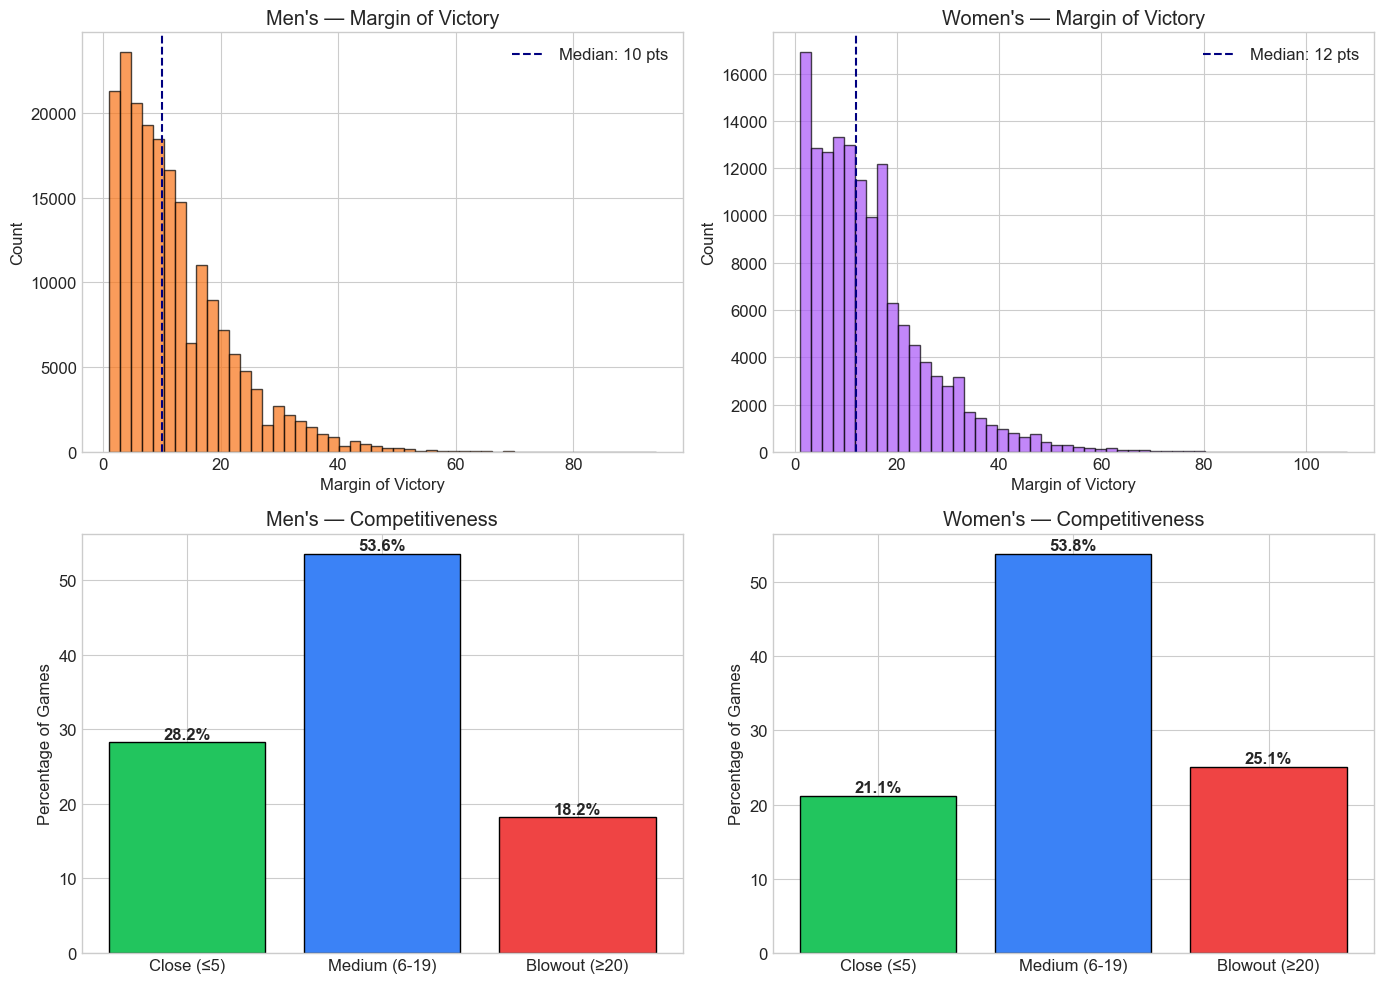

In [195]:
m_reg_compact['MOV'] = m_reg_compact['WScore'] - m_reg_compact['LScore']
w_reg_compact['MOV'] = w_reg_compact['WScore'] - w_reg_compact['LScore']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Men's MOV distribution
axes[0, 0].hist(m_reg_compact['MOV'], bins=50, edgecolor='black', alpha=0.7, color='#f97316')
axes[0, 0].set_xlabel('Margin of Victory')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title("Men's — Margin of Victory")
axes[0, 0].axvline(m_reg_compact['MOV'].median(), color='navy', linestyle='--',
                    label=f"Median: {m_reg_compact['MOV'].median():.0f} pts")
axes[0, 0].legend()

# Women's MOV distribution
axes[0, 1].hist(w_reg_compact['MOV'], bins=50, edgecolor='black', alpha=0.7, color='#a855f7')
axes[0, 1].set_xlabel('Margin of Victory')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title("Women's — Margin of Victory")
axes[0, 1].axvline(w_reg_compact['MOV'].median(), color='navy', linestyle='--',
                    label=f"Median: {w_reg_compact['MOV'].median():.0f} pts")
axes[0, 1].legend()

# Men's competitiveness breakdown
m_close = (m_reg_compact['MOV'] <= 5).mean() * 100
m_blowout = (m_reg_compact['MOV'] >= 20).mean() * 100
m_mid = 100 - m_close - m_blowout
axes[1, 0].bar(['Close (≤5)', 'Medium (6-19)', 'Blowout (≥20)'],
               [m_close, m_mid, m_blowout],
               color=['#22c55e', '#3b82f6', '#ef4444'], edgecolor='black')
axes[1, 0].set_ylabel('Percentage of Games')
axes[1, 0].set_title("Men's — Competitiveness")
for i, v in enumerate([m_close, m_mid, m_blowout]):
    axes[1, 0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Women's competitiveness breakdown
w_close = (w_reg_compact['MOV'] <= 5).mean() * 100
w_blowout = (w_reg_compact['MOV'] >= 20).mean() * 100
w_mid = 100 - w_close - w_blowout
axes[1, 1].bar(['Close (≤5)', 'Medium (6-19)', 'Blowout (≥20)'],
               [w_close, w_mid, w_blowout],
               color=['#22c55e', '#3b82f6', '#ef4444'], edgecolor='black')
axes[1, 1].set_ylabel('Percentage of Games')
axes[1, 1].set_title("Women's — Competitiveness")
for i, v in enumerate([w_close, w_mid, w_blowout]):
    axes[1, 1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('data/processed/mov_distribution.png', dpi=150, bbox_inches='tight')
plt.show()



### What the Margins Tell Us
 
The men's and women's games have similar competitive structure — about half of all games land in the 6-19 point range. But there are two notable differences:
 
- **Women's games have more blowouts** — 25.1% vs 18.2%. The median margin is 12 points vs 10. This likely reflects greater disparity between programs — historically, fewer schools have invested equally in women's basketball, so the gap between top programs and the rest is wider.

- **Men's games are closer more often** — 28.2% decided by 5 or fewer points, vs 21.1% for women. More close games means more outcomes that look like coin flips. The model needs calibrated probabilities, not just correct picks — predicting 0.65 and being wrong costs far less than predicting 0.90 and being wrong.
 
Both distributions are right-skewed with a long tail of blowouts, which is typical for competitive sports where mismatches happen regularly in the regular season. The tournament will be much tighter — only the best teams make it.

### How Predictive Are Seeds?

The Selection Committee assigns each tournament team a seed from 1 (strongest) to 16 (weakest) within each region. This is human expert judgment — they watch games all season and rank accordingly. Before building any ML model, it's worth asking: how good is this simple signal on its own?

In [196]:
# Parse seed number from the string (e.g., "W01" -> 1, "X16a" -> 16)
for df in [m_seeds, w_seeds]:
    df['SeedNum'] = df['Seed'].str[1:3].astype(int)
    df['Region'] = df['Seed'].str[0]

print(f"Men's seeds: {len(m_seeds):,} entries ({m_seeds.Season.min()}-{m_seeds.Season.max()})")
print(f"Women's seeds: {len(w_seeds):,} entries ({w_seeds.Season.min()}-{w_seeds.Season.max()})")
print(f"\nSample: {m_seeds.head().to_string(index=False)}")

Men's seeds: 2,626 entries (1985-2025)
Women's seeds: 1,744 entries (1998-2025)

Sample:  Season Seed  TeamID  SeedNum Region
   1985  W01    1207        1      W
   1985  W02    1210        2      W
   1985  W03    1228        3      W
   1985  W04    1260        4      W
   1985  W05    1374        5      W


In [197]:
def analyze_seed_performance(tourney_df, seeds_df, label=""):
    """Analyze how well seeds predict tournament outcomes."""
    merged = tourney_df.merge(
        seeds_df[['Season', 'TeamID', 'SeedNum']].rename(
            columns={'TeamID': 'WTeamID', 'SeedNum': 'WSeed'}),
        on=['Season', 'WTeamID'], how='left'
    ).merge(
        seeds_df[['Season', 'TeamID', 'SeedNum']].rename(
            columns={'TeamID': 'LTeamID', 'SeedNum': 'LSeed'}),
        on=['Season', 'LTeamID'], how='left'
    )
    merged = merged.dropna(subset=['WSeed', 'LSeed'])
    merged['BetterSeedWon'] = merged['WSeed'] < merged['LSeed']
    merged['SameSeed'] = merged['WSeed'] == merged['LSeed']

    non_equal = merged[~merged['SameSeed']]
    pct = non_equal['BetterSeedWon'].mean() * 100

    print(f"\n{label} Tournament:")
    print(f"  Better seed wins {pct:.1f}% of the time (when seeds differ)")
    print(f"  Total tournament games: {len(merged):,}")
    return merged

m_tourney_seeds = analyze_seed_performance(m_tourney_compact, m_seeds, "Men's")
w_tourney_seeds = analyze_seed_performance(w_tourney_compact, w_seeds, "Women's")





Men's Tournament:
  Better seed wins 71.6% of the time (when seeds differ)
  Total tournament games: 2,585

Women's Tournament:
  Better seed wins 78.3% of the time (when seeds differ)
  Total tournament games: 1,717


Seeds are a strong baseline — the better seed wins about 72% of the time in men's and 78% in women's tournaments. That's without any ML, just trusting the committee's judgment.

The women's rate being higher is consistent with what we saw in the margin of victory data — more disparity between programs means fewer upsets. The men's tournament is where the chaos lives. Either way, seeds are going to be one of the most important features in the model. The question is whether we can do better by combining them with Elo, box scores, and conference strength.

### Seed Matchup Matrix — Where Do Upsets Actually Happen?

Not all seed matchups are created equal. A 1-vs-16 game is almost a formality, but everyone knows the 5-vs-12 is dangerous. Let's build a historical win rate for every seed-vs-seed combination and see where the upsets actually cluster. 

In [198]:
def build_seed_matchup_matrix(tourney_seeds_df):
    """Build historical win rates for each seed matchup."""
    matchups = defaultdict(lambda: {'wins': 0, 'losses': 0})

    for _, game in tourney_seeds_df.iterrows():
        ws = int(game['WSeed'])
        ls = int(game['LSeed'])
        better = min(ws, ls)
        worse = max(ws, ls)
        if ws == better:
            matchups[(better, worse)]['wins'] += 1
        else:
            matchups[(better, worse)]['losses'] += 1

    records = []
    for (s1, s2), stats in sorted(matchups.items()):
        total = stats['wins'] + stats['losses']
        records.append({
            'BetterSeed': s1, 'WorseSeed': s2,
            'BetterSeedWins': stats['wins'], 'Total': total,
            'BetterSeedWinRate': stats['wins'] / total if total > 0 else 0.5
        })
    return pd.DataFrame(records)

seed_matrix = build_seed_matchup_matrix(m_tourney_seeds)
w_seed_matrix = build_seed_matchup_matrix(w_tourney_seeds)

# Round 1 matchups (seeds add up to 17)
r1_matchups = seed_matrix[
    seed_matrix.apply(lambda r: r['BetterSeed'] + r['WorseSeed'] == 17, axis=1)
].sort_values('BetterSeed')

w_r1_matchups = w_seed_matrix[
    w_seed_matrix.apply(lambda r: r['BetterSeed'] + r['WorseSeed'] == 17, axis=1)
].sort_values('BetterSeed')

for label, matchups_df in [("Men's", r1_matchups), ("Women's", w_r1_matchups)]:
    print(f"\n{label} Round 1 — Historical seed matchup win rates:")
    print(f"{'Matchup':<12} {'Games':>6} {'Fav Wins':>10} {'Upset Rate':>12}")
    print("-" * 42)
    for _, row in matchups_df.iterrows():
        matchup = f"#{int(row.BetterSeed)} vs #{int(row.WorseSeed)}"
        upset_rate = (1 - row.BetterSeedWinRate) * 100
        print(f"{matchup:<12} {int(row.Total):>6} {row.BetterSeedWinRate*100:>9.1f}% {upset_rate:>10.1f}%")


Men's Round 1 — Historical seed matchup win rates:
Matchup       Games   Fav Wins   Upset Rate
------------------------------------------
#1 vs #16       160      98.8%        1.2%
#2 vs #15       160      93.1%        6.9%
#3 vs #14       160      85.6%       14.4%
#4 vs #13       160      79.4%       20.6%
#5 vs #12       160      64.4%       35.6%
#6 vs #11       160      61.3%       38.7%
#7 vs #10       159      61.0%       39.0%
#8 vs #9        160      48.1%       51.9%

Women's Round 1 — Historical seed matchup win rates:
Matchup       Games   Fav Wins   Upset Rate
------------------------------------------
#1 vs #16       108      99.1%        0.9%
#2 vs #15       108     100.0%        0.0%
#3 vs #14       108     100.0%        0.0%
#4 vs #13       108      94.4%        5.6%
#5 vs #12       108      79.6%       20.4%
#6 vs #11       108      67.6%       32.4%
#7 vs #10       108      65.7%       34.3%
#8 vs #9        108      51.9%       48.1%


The gradient is clear. In men's, #1 seeds are nearly untouchable — only 2 losses in 160 games. Women's top seeds are even more dominant — #2 and #3 seeds have never lost a Round 1 game. By the time you get to #8 vs #9, both tournaments converge on a coin flip.

The upset zone is the 5-12 through 7-10 range. In men's, the favorite wins only about 60-65% of these. Women's is slightly more predictable (65-80%), but this is still where brackets break.
 
These historical rates will be powerful features. If we know a matchup is a men's #5 vs #12, that alone gives us a probability of roughly 0.64 — before we even look at Elo or box scores. Let's visualize the full picture. 

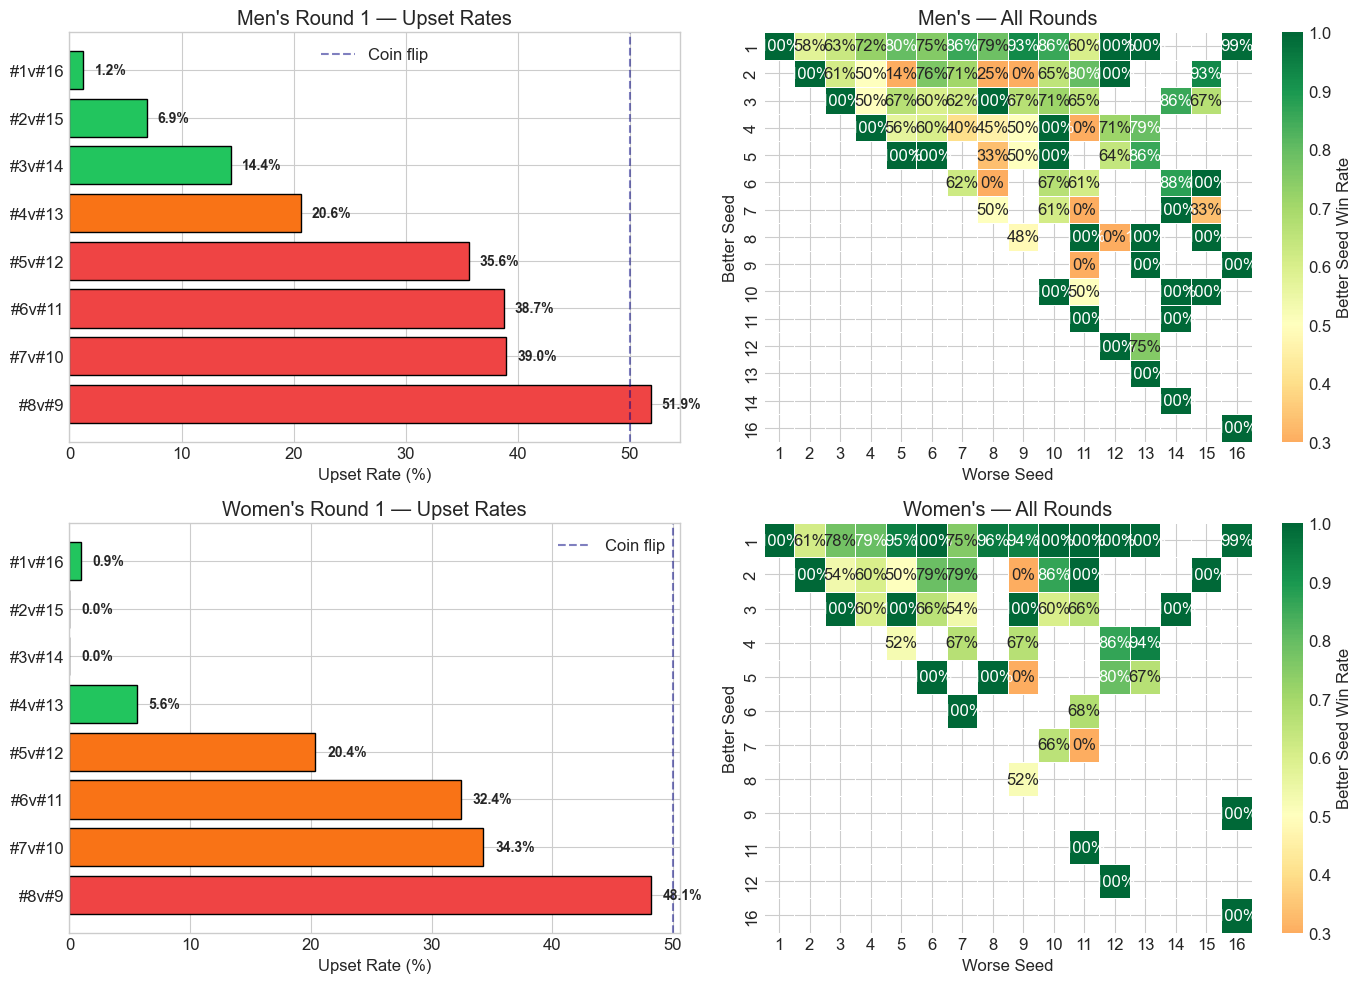

In [199]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# === MEN'S ===
matchup_labels = [f"#{int(r.BetterSeed)}v#{int(r.WorseSeed)}" for _, r in r1_matchups.iterrows()]
upset_rates = [(1 - r.BetterSeedWinRate) * 100 for _, r in r1_matchups.iterrows()]

colors = ['#22c55e' if u < 15 else '#f97316' if u < 35 else '#ef4444' for u in upset_rates]
axes[0, 0].barh(matchup_labels[::-1], upset_rates[::-1], color=colors[::-1], edgecolor='black')
axes[0, 0].set_xlabel('Upset Rate (%)')
axes[0, 0].set_title("Men's Round 1 — Upset Rates")
axes[0, 0].axvline(50, color='navy', linestyle='--', alpha=0.5, label='Coin flip')
axes[0, 0].legend()
for i, v in enumerate(upset_rates[::-1]):
    axes[0, 0].text(v + 1, i, f'{v:.1f}%', va='center', fontweight='bold', fontsize=10)

matrix_m = seed_matrix.pivot(index='BetterSeed', columns='WorseSeed', values='BetterSeedWinRate')
sns.heatmap(matrix_m, annot=True, fmt='.0%', cmap='RdYlGn', center=0.5,
            vmin=0.3, vmax=1.0, linewidths=0.5, ax=axes[0, 1],
            cbar_kws={'label': 'Better Seed Win Rate'})
axes[0, 1].set_title("Men's — All Rounds")
axes[0, 1].set_xlabel('Worse Seed')
axes[0, 1].set_ylabel('Better Seed')

# === WOMEN'S ===
w_matchup_labels = [f"#{int(r.BetterSeed)}v#{int(r.WorseSeed)}" for _, r in w_r1_matchups.iterrows()]
w_upset_rates = [(1 - r.BetterSeedWinRate) * 100 for _, r in w_r1_matchups.iterrows()]

w_colors = ['#22c55e' if u < 15 else '#f97316' if u < 35 else '#ef4444' for u in w_upset_rates]
axes[1, 0].barh(w_matchup_labels[::-1], w_upset_rates[::-1], color=w_colors[::-1], edgecolor='black')
axes[1, 0].set_xlabel('Upset Rate (%)')
axes[1, 0].set_title("Women's Round 1 — Upset Rates")
axes[1, 0].axvline(50, color='navy', linestyle='--', alpha=0.5, label='Coin flip')
axes[1, 0].legend()
for i, v in enumerate(w_upset_rates[::-1]):
    axes[1, 0].text(v + 1, i, f'{v:.1f}%', va='center', fontweight='bold', fontsize=10)

matrix_w = w_seed_matrix.pivot(index='BetterSeed', columns='WorseSeed', values='BetterSeedWinRate')
sns.heatmap(matrix_w, annot=True, fmt='.0%', cmap='RdYlGn', center=0.5,
            vmin=0.3, vmax=1.0, linewidths=0.5, ax=axes[1, 1],
            cbar_kws={'label': 'Better Seed Win Rate'})
axes[1, 1].set_title("Women's — All Rounds")
axes[1, 1].set_xlabel('Worse Seed')
axes[1, 1].set_ylabel('Better Seed')

plt.tight_layout()
plt.savefig('data/processed/seed_matchup_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


The comparison is striking. The women's tournament is far more predictable at the top — #2 and #3 seeds have *never* lost in Round 1. In the men's bracket, #2 seeds lose about 7% of the time and #3 seeds lose 14%.
 
The pattern converges at the bottom though. The 8-vs-9 matchup is a coin flip in both tournaments (~48-52%), and the 5-through-7 seed range is where upsets live in both cases — just more so on the men's side.
 
What this means for modeling: seed difference alone is a strong predictor, but it's stronger for women's games. The men's tournament has more parity in the middle seeds, which is where our model needs to add value beyond what seeds already tell us. 


### Conferences — Context for Win-Loss Records

A team's record is meaningless without knowing who they played. Going 25-5 in the Big 12, where half the league is ranked, is a completely different achievement than 25-5 in a mid-major conference. Let's see what the conference data looks like.

In [200]:
print(f"Total conferences in dataset: {len(conferences)}")
print(f"\nMen's conference assignments: {len(m_team_conf):,} rows")
print(f"Women's conference assignments: {len(w_team_conf):,} rows")

# How many conferences per season?
m_conf_counts = m_team_conf.groupby('Season')['ConfAbbrev'].nunique()
w_conf_counts = w_team_conf.groupby('Season')['ConfAbbrev'].nunique()
print(f"\nConferences per season (men's): {m_conf_counts.min()}-{m_conf_counts.max()}")
print(f"Conferences per season (women's): {w_conf_counts.min()}-{w_conf_counts.max()}")

Total conferences in dataset: 51

Men's conference assignments: 13,753 rows
Women's conference assignments: 9,853 rows

Conferences per season (men's): 30-34
Conferences per season (women's): 30-33


Around 30-34 conferences per season across both tournaments. We'll use these later to compute conference-level Elo averages — a team's conference is one of the strongest contextual signals for interpreting their record.

### Detailed Results — Box Scores
 
The compact results only tell us who won and by how much. The detailed results add the full box score — field goal attempts, rebounds, turnovers, assists, blocks, steals. This is where Dean Oliver's Four Factors come from, which we'll use as features later. 

In [201]:
print(f"Men's detailed results: {len(m_reg_detail):,} games ({m_reg_detail.Season.min()}-{m_reg_detail.Season.max()})")
print(f"Women's detailed results: {len(w_reg_detail):,} games ({w_reg_detail.Season.min()}-{w_reg_detail.Season.max()})")
print(f"\nBox score columns ({len(m_reg_detail.columns)} total):")
print([c for c in m_reg_detail.columns if c.startswith('W') and c not in ['WTeamID', 'WScore', 'WLoc']])

Men's detailed results: 122,775 games (2003-2026)
Women's detailed results: 85,505 games (2010-2026)

Box score columns (34 total):
['WFGM', 'WFGA', 'WFGM3', 'WFGA3', 'WFTM', 'WFTA', 'WOR', 'WDR', 'WAst', 'WTO', 'WStl', 'WBlk', 'WPF']


13 stats per team per game — field goals, three-pointers, free throws, rebounds (offensive and defensive), assists, turnovers, steals, blocks, and personal fouls. These map directly to the Four Factors of basketball:
 
1. **Effective FG%** — shooting efficiency (adjusted for 3-pointers being worth more)
2. **Turnover rate** — how often you give the ball away
3. **Offensive rebound %** — second chance opportunities
4. **Free throw rate** — getting to the line and converting

We won't use these raw — we'll compute per-team season averages and turn them into matchup-level differentials. But that comes later in feature engineering.
 
Note the coverage gap again: men's box scores go back to 2003, women's only to 2010. For earlier seasons, we'll rely on Elo and seeds alone.

### Data Availability Summary
 
| Data | Men's | Women's | Notes |
|---|---|---|---|
| Compact results | 1985-2026 | 1998-2026 | Every D1 game |
| Detailed box scores | 2003-2026 | 2010-2026 | FG%, rebounds, etc. |
| Tournament seeds | 1985-2025 | 1998-2025 | 2026 after Selection Sunday |
| Massey ordinals | 2003-2026 | None | Men's only — 40+ ranking systems |
| Conference data | 1985-2026 | 1998-2026 | Team-conference mappings |
| Game locations | 2010-2026 | 2010-2026 | City-level |
| Coaches | 1985-2026 | None | Men's only |
 
**Key takeaway**: Women's data is sparser — no Massey ordinals, no coach data, shorter history. Our model needs to handle this gracefully. Features that only exist for men's data should degrade to sensible defaults for women's teams, not crash.
 

### Massey Ordinals — Wisdom of the Crowd

Kenneth Massey collects rankings from dozens of computer ranking systems. Each one ranks all ~350 D1 men's teams using its own methodology. This is only available for men's — one more asymmetry in the dataset. Let's see what we're working with.

In [202]:
print(f"Massey Ordinals: {len(m_massey):,} rows")
print(f"Ranking systems: {m_massey.SystemName.nunique()}")
print(f"Seasons: {m_massey.Season.min()}-{m_massey.Season.max()}")
print(f"\nSample systems: {sorted(m_massey.SystemName.unique())[:15]}")

# Which systems have the most complete coverage?
system_coverage = m_massey.groupby('SystemName')['Season'].nunique().sort_values(ascending=False)
print(f"\nMost consistently available systems (by # seasons covered):")
print(system_coverage.head(10).to_string())

Massey Ordinals: 5,761,702 rows
Ranking systems: 196
Seasons: 2003-2026

Sample systems: ['7OT', 'ACU', 'ADE', 'AEI', 'AP', 'ARG', 'ATP', 'AUS', 'AWS', 'BAR', 'BBT', 'BCM', 'BD', 'BIH', 'BKM']

Most consistently available systems (by # seasons covered):
SystemName
COL    24
AP     24
DOL    24
POM    24
USA    24
MOR    24
WLK    24
RTH    23
WOL    23
BIH    23


196 ranking systems across 24 seasons — that's a lot of signal. But not all systems cover every season, so we need to pick ones with consistent availability.
 
The most reliable systems (24 seasons of coverage) include some well-known names:
- **POM** (Ken Pomeroy) — widely regarded as the best college basketball ranking. Efficiency-based.
- **SAG** (Jeff Sagarin) — one of the originals. Used by the NCAA Selection Committee.
- **MOR** (Kenneth Massey) — Massey's own composite ranking.
- **COL**, **DOL**, **AP**, **USA** — all with complete 24-season coverage.
 
Rather than picking a single "best" system, I'll average across the top ones. This is itself an ensemble — we're ensembling the rankers before we even start ensembling our models. Averaging smooths out the quirks of any individual system.

One important detail: `RankingDayNum=133` is the final pre-tournament ranking. That's the snapshot we'll use for predictions — anything after that would leak tournament results.
 

### Submission Format — What Exactly Are We Predicting?
 
Before moving on, let's look at what the final submission needs to look like. This shapes everything about how we build the model.

In [203]:
print(f"Stage 1 sample (2022-2025 validation): {len(stage1_sample):,} matchups")
print(f"Stage 2 sample (2026 predictions):     {len(stage2_sample):,} matchups")
print(f"\nSample rows:")
print(stage1_sample.head().to_string(index=False))

# Parse the IDs to understand the scope
stage2_sample['Season'] = stage2_sample['ID'].str[:4].astype(int)
stage2_sample['TeamA'] = stage2_sample['ID'].str[5:9].astype(int)
stage2_sample['TeamB'] = stage2_sample['ID'].str[10:14].astype(int)

men_matchups = stage2_sample[stage2_sample['TeamA'] < 2000]
women_matchups = stage2_sample[stage2_sample['TeamA'] >= 3000]
men_teams = set(men_matchups['TeamA']) | set(men_matchups['TeamB'])
women_teams = set(women_matchups['TeamA']) | set(women_matchups['TeamB'])

print(f"\n2026 submission breakdown:")
print(f"  Men's matchups:   {len(men_matchups):>8,} ({len(men_teams)} teams)")
print(f"  Women's matchups: {len(women_matchups):>8,} ({len(women_teams)} teams)")
print(f"  Total:            {len(stage2_sample):>8,}")
print(f"\nThat's {len(men_teams)} x {len(men_teams)-1} / 2 = {len(men_teams)*(len(men_teams)-1)//2:,} men's pairs")
print(f"Plus {len(women_teams)} x {len(women_teams)-1} / 2 = {len(women_teams)*(len(women_teams)-1)//2:,} women's pairs")


Stage 1 sample (2022-2025 validation): 519,144 matchups
Stage 2 sample (2026 predictions):     132,133 matchups

Sample rows:
            ID  Pred
2022_1101_1102   0.5
2022_1101_1103   0.5
2022_1101_1104   0.5
2022_1101_1105   0.5
2022_1101_1106   0.5

2026 submission breakdown:
  Men's matchups:     66,430 (365 teams)
  Women's matchups:   65,703 (363 teams)
  Total:             132,133

That's 365 x 364 / 2 = 66,430 men's pairs
Plus 363 x 362 / 2 = 65,703 women's pairs


132,133 predictions for 2026 alone — every possible pair of 365 men's teams and 363 women's teams. The sample submission starts everything at 0.5, which is the "I know nothing" baseline. Notice the ID format: `2022_1101_1102` means Season 2022, Team 1101 vs Team 1102, where the lower ID always comes first.
 
Most of these matchups will never happen. A mid-major with a 10-20 record will never face the #1 overall seed in the tournament. But we need a probability for it anyway. This is why Elo is the right foundation — every team gets a rating, and we can compute P(A beats B) for any pair instantly. The model doesn't need to have seen a specific matchup to make a prediction.
 
It also means most of our predictions don't affect our score — only the ~67 actual tournament games per bracket get evaluated. But since we don't know which 67 until Selection Sunday, we predict everything.

That's Part 1 complete. We know what we have, we know what's missing, and we know what the submission demands. Time to build.

## Part 2: Building the Elo Rating System
 
Elo is the foundation of our model. It was originally designed for chess by
Arpad Elo, but it works beautifully for any head-to-head competition.

### How Elo works
 
Every team starts with a rating (typically 1500). After each game:
1. Calculate the **expected** win probability based on rating difference
2. Compare expected vs **actual** outcome
3. Adjust both teams' ratings proportionally to the "surprise"

The formula for expected win probability:
 
$$E_A = \frac{1}{1 + 10^{(R_B - R_A) / 400}}$$
 
And the rating update:

$$R'_A = R_A + K \cdot (S_A - E_A)$$

where $K$ is the "learning rate" (how much each game matters),
$S_A$ is the actual outcome (1 for win, 0 for loss),
and $E_A$ is the expected outcome.
 
### My Elo enhancements
 
1. **Margin of Victory** — A 30-point blowout tells us more than a 1-point squeaker.
  I use FiveThirtyEight's MOV multiplier that dampens the effect for very large margins.
 
2. **Home Court Advantage** — We saw that home teams win ~67% of games.
  I add a bonus to the home team's effective rating for the expected probability calculation.
 
3. **Season Regression** — Between seasons, ratings regress toward the mean.
This accounts for roster turnover (college players leave after 4 years).

In [204]:
# === ELO IMPLEMENTATION ===

def expected_win_prob(elo_a, elo_b):
    """P(A wins) based on Elo ratings."""
    return 1.0 / (1.0 + 10 ** ((elo_b - elo_a) / 400))

def mov_multiplier(mov, elo_diff):
    """
    Margin-of-victory multiplier (FiveThirtyEight style).
    Log function gives diminishing returns for larger margins.
    Denominator adjusts for elo_diff to prevent "running up the score"
    against weak teams from inflating ratings.
    """
    return np.log(max(abs(mov), 1) + 1) * (2.2 / ((elo_diff * 0.001) + 2.2))

# Configuration — these are tunable hyperparameters
ELO_CONFIG = {
    'k_factor': 32,            # How much each game moves ratings
    'home_advantage': 100,     # Elo points added to home team
    'season_regression': 0.75, # How much Elo carries over between seasons
    'initial_elo': 1500,       # Starting Elo for new teams
    'use_mov': True,           # Use margin of victory adjustment
}

print("Elo configuration:")
for k, v in ELO_CONFIG.items():
    print(f"  {k}: {v}")




Elo configuration:
  k_factor: 32
  home_advantage: 100
  season_regression: 0.75
  initial_elo: 1500
  use_mov: True


### Why These Specific Parameter Values?
 
- **K=32**: Standard chess K-factor. With ~30 games per college basketball season, this lets ratings move meaningfully without overreacting to single results.
- **Home advantage = 100 Elo points**: Roughly equivalent to giving the home team a 64% expected win rate against an equally-rated opponent — close to the 66% we observed in the data.
- **Season regression = 0.75**: Each team keeps 75% of their rating between seasons and regresses 25% toward the mean. College rosters turn over constantly — this prevents stale ratings from lingering.

In [205]:
def compute_elo_ratings(results_df, config=ELO_CONFIG, snapshot_day=132):
    """
    Compute Elo ratings from game-by-game results.

    Produces PRE-TOURNAMENT snapshots for use as prediction features.
    Tournament games still update Elo internally (so the next season's
    carry-over regression accounts for March performance), but the
    snapshot used for features is taken at DayNum <= snapshot_day.

    Between seasons, men's and women's teams regress toward their own
    pool means (not a combined mean), since they never play each other.
    """
    k = config['k_factor']
    home_adv = config['home_advantage']
    regression = config['season_regression']
    initial = config['initial_elo']
    use_mov = config['use_mov']

    results = results_df.sort_values(['Season', 'DayNum']).reset_index(drop=True)

    elo = {}              # Current ratings (persist across seasons)
    elo_by_season = {}    # Pre-tournament snapshots (for features)
    elo_history = []

    seasons = sorted(results['Season'].unique())

    for season in seasons:
        # Between seasons: regress toward pool-specific means
        if season != seasons[0] and elo:
            men_ids = [t for t in elo if 1000 <= t < 2000]
            women_ids = [t for t in elo if 3000 <= t < 4000]

            if men_ids:
                men_mean = np.mean([elo[t] for t in men_ids])
                for t in men_ids:
                    elo[t] = regression * elo[t] + (1 - regression) * men_mean

            if women_ids:
                women_mean = np.mean([elo[t] for t in women_ids])
                for t in women_ids:
                    elo[t] = regression * elo[t] + (1 - regression) * women_mean

        season_games = results[results['Season'] == season]
        snapshotted = False

        for game in season_games.itertuples():
            day = game.DayNum

            # Snapshot pre-tournament Elo BEFORE any tournament game is processed
            if not snapshotted and day > snapshot_day:
                season_teams = set(season_games['WTeamID']) | set(season_games['LTeamID'])
                for tid in season_teams:
                    elo_by_season[(season, tid)] = elo.get(tid, initial)
                snapshotted = True

            w_id = game.WTeamID
            l_id = game.LTeamID
            w_score = game.WScore
            l_score = game.LScore
            w_loc = getattr(game, 'WLoc', 'N')

            elo.setdefault(w_id, initial)
            elo.setdefault(l_id, initial)

            w_elo = elo[w_id]
            l_elo = elo[l_id]

            if w_loc == 'H':
                w_elo_adj = w_elo + home_adv
                l_elo_adj = l_elo
            elif w_loc == 'A':
                w_elo_adj = w_elo
                l_elo_adj = l_elo + home_adv
            else:
                w_elo_adj = w_elo
                l_elo_adj = l_elo

            w_exp = expected_win_prob(w_elo_adj, l_elo_adj)

            mov = w_score - l_score
            mult = mov_multiplier(mov, w_elo - l_elo) if use_mov else 1.0

            w_delta = k * mult * (1.0 - w_exp)
            l_delta = k * mult * (0.0 - (1.0 - w_exp))

            elo[w_id] = w_elo + w_delta
            elo[l_id] = l_elo + l_delta

            elo_history.append({
                'Season': season, 'DayNum': day,
                'WTeamID': w_id, 'LTeamID': l_id,
                'WElo_before': w_elo, 'LElo_before': l_elo,
                'WElo_after': elo[w_id], 'LElo_after': elo[l_id],
                'WExpected': w_exp, 'MOV': mov,
            })

        # If no tournament games this season, snapshot at end
        if not snapshotted:
            season_teams = set(season_games['WTeamID']) | set(season_games['LTeamID'])
            for tid in season_teams:
                elo_by_season[(season, tid)] = elo.get(tid, initial)

    return elo_by_season, pd.DataFrame(elo_history)

In [206]:
# Run Elo on ALL game data (men's + women's, regular season + tournament)
# Men's IDs are 1000-1999, Women's are 3000-3999, so no overlap
#
# IMPORTANT: Tournament games update Elo for next-season carry-over,
# but elo_by_season is snapshotted BEFORE tournament games (DayNum <= 132).
# This prevents data leakage — we never use tournament outcomes to predict tournaments.

all_results = pd.concat([
    m_reg_compact, w_reg_compact,
    m_tourney_compact, w_tourney_compact
], ignore_index=True).sort_values(['Season', 'DayNum']).reset_index(drop=True)

print(f"Computing Elo on {len(all_results):,} total games...")
print("  (Pre-tournament snapshot at DayNum=132, no leakage)")

elo_by_season, elo_history = compute_elo_ratings(all_results, snapshot_day=132)

print(f"Done! Ratings computed for {len(elo_by_season):,} (season, team) pairs.")

Computing Elo on 341,950 total games...
  (Pre-tournament snapshot at DayNum=132, no leakage)
Done! Ratings computed for 23,604 (season, team) pairs.


### Elo Sanity Check

23,604 ratings computed. But do they make sense? If the top-rated teams are names we'd actually expect — traditional powers, recent champions — then the system is working. If not, something needs tuning.

In [207]:
latest_season = max(s for s, t in elo_by_season.keys())
latest_men = {k: v for k, v in elo_by_season.items() if k[0] == latest_season and k[1] < 2000}
latest_women = {k: v for k, v in elo_by_season.items() if k[0] == latest_season and k[1] >= 3000}

# Get team names for display
team_names = dict(zip(m_teams.TeamID, m_teams.TeamName))
team_names.update(dict(zip(w_teams.TeamID, w_teams.TeamName)))

print(f"=== Top 15 Men's Teams by Elo ({latest_season}) ===")
for i, ((season, tid), rating) in enumerate(sorted(latest_men.items(), key=lambda x: -x[1])[:15], 1):
    name = team_names.get(tid, f"Team {tid}")
    print(f"  {i:>2}. {name:<20} {rating:.0f}")

print(f"\n=== Top 15 Women's Teams by Elo ({latest_season}) ===")
for i, ((season, tid), rating) in enumerate(sorted(latest_women.items(), key=lambda x: -x[1])[:15], 1):
    name = team_names.get(tid, f"Team {tid}")
    print(f"  {i:>2}. {name:<20} {rating:.0f}")




=== Top 15 Men's Teams by Elo (2026) ===
   1. Duke                 2136
   2. Arizona              2118
   3. Michigan             2113
   4. Houston              2084
   5. Connecticut          2040
   6. Illinois             2039
   7. Florida              1987
   8. St John's            1952
   9. Kansas               1951
  10. Gonzaga              1944
  11. Michigan St          1933
  12. Iowa St              1931
  13. Purdue               1919
  14. Tennessee            1909
  15. Nebraska             1908

=== Top 15 Women's Teams by Elo (2026) ===
   1. Connecticut          2346
   2. UCLA                 2263
   3. South Carolina       2199
   4. Texas                2197
   5. LSU                  2154
   6. Louisville           2124
   7. Michigan             2081
   8. Duke                 2072
   9. Ohio St              2050
  10. Iowa                 2039
  11. TCU                  2039
  12. Baylor               2035
  13. West Virginia        2020
  14. Oklahoma     

The rankings pass the smell test. Duke, Arizona, Houston, UConn, Kansas, Gonzaga — these are all teams you'd expect near the top of men's basketball in 2026. On the women's side, UConn, UCLA, South Carolina, Texas, LSU — all established powerhouses or recent Final Four teams.

A couple of things to notice:
- **The Elo scale is different between men's and women's.** UConn's women sit at 2346 while Duke's men lead at 2136. This doesn't mean UConn's women are "better" — the pools regress separately, and the women's pool has wider variance (consistent with the blowout data we saw earlier).
- **The gap between #1 and #15 is informative.** Men's: 2136 to 1908 (228 points). Women's: 2346 to 2004 (342 points). Again, more disparity on the women's side.
 
The system is working. Now the question is: how well does raw Elo actually predict tournament outcomes?

### Elo Baseline — How Good Is This On Its Own?

 Before adding any features, ensembles, or fancy modeling, let's measure how well raw Elo predictions perform on historical tournaments. This gives us a baseline Brier score that every improvement must beat.

In [208]:
def evaluate_elo_predictions(tourney_df, elo_by_season, label=""):
    """Compute Brier score of raw Elo predictions on tournament games."""
    preds = []
    actuals = []

    for _, game in tourney_df.iterrows():
        season = game['Season']
        w_id = game['WTeamID']
        l_id = game['LTeamID']

        # Convention: predict P(lower_id wins)
        team_a = min(w_id, l_id)
        team_b = max(w_id, l_id)
        actual = 1 if w_id == team_a else 0

        elo_a = elo_by_season.get((season, team_a), 1500)
        elo_b = elo_by_season.get((season, team_b), 1500)
        pred = expected_win_prob(elo_a, elo_b)

        preds.append(np.clip(pred, 0.02, 0.98))
        actuals.append(actual)

    brier = np.mean([(p - a) ** 2 for p, a in zip(preds, actuals)])
    baseline = np.mean([(0.5 - a) ** 2 for a in actuals])  # Always predict 50%

    print(f"\n{label} Elo-only Brier score: {brier:.4f} (baseline 0.5 = {baseline:.4f})")
    print(f"  Improvement over baseline: {(1 - brier/baseline)*100:.1f}%")

    return brier, preds, actuals

# Evaluate on recent tournaments (2015-2025)
recent_m_tourney = m_tourney_compact[m_tourney_compact.Season >= 2015]
recent_w_tourney = w_tourney_compact[w_tourney_compact.Season >= 2015]

m_brier, _, _ = evaluate_elo_predictions(recent_m_tourney, elo_by_season, "Men's (2015-2025)")
w_brier, _, _ = evaluate_elo_predictions(recent_w_tourney, elo_by_season, "Women's (2015-2025)")

print(f"\nCombined Brier: {(m_brier + w_brier) / 2:.4f}")
# 


Men's (2015-2025) Elo-only Brier score: 0.1990 (baseline 0.5 = 0.2500)
  Improvement over baseline: 20.4%

Women's (2015-2025) Elo-only Brier score: 0.1562 (baseline 0.5 = 0.2500)
  Improvement over baseline: 37.5%

Combined Brier: 0.1776


Elo alone gets us from 0.2500 (coin flip) to 0.1776 combined — a solid starting point. Two things stand out:
 
 - **Women's Elo (0.1562) is significantly better than men's (0.1990).** This is consistent with everything we've seen — the women's tournament is more predictable. Stronger seeds hold, fewer upsets, wider margins. Elo captures that structure well.
 - **Men's has more room to improve.** A 0.199 Brier score means our predictions are still substantially wrong on many men's games. This is where additional features — conference strength, box scores, Massey ordinals — should help the most.
 
 This is our floor. Everything we add from here needs to push these numbers down.
 

 ## Part 3: Conference Strength
 
 Here's the core insight: **a team's win-loss record is meaningless without context.**
 
 Going 25-5 in the Big 12 (which might have 6 teams in the AP Top 25) is vastly different from going 25-5 in the Southland Conference. Yet raw Elo partially handles this — teams in strong conferences play tougher opponents, so their Elo is naturally higher. But we can do better with explicit conference features.
 
 I'm computing 5 conference-level metrics that capture different aspects of conference quality. Why multiple metrics? Because "conference strength" isn't one-dimensional:
 - A conference could have 2 great teams and 10 terrible ones (top-heavy)
 - A conference could have 12 decent teams and no great ones (deep but not elite)
 - A conference could dominate non-conference play but underperform in March
 
 Multiple metrics capture these nuances.

In [209]:
team_conferences = pd.concat([m_team_conf, w_team_conf], ignore_index=True)

def compute_conference_strength(team_conferences, elo_by_season, all_results, tourney_results):
    """
    Compute multi-dimensional conference strength metrics.
    Returns a DataFrame with one row per (Season, Gender, ConfAbbrev).
    """
    # Tag gender based on TeamID range
    team_conferences = team_conferences.copy()
    team_conferences['Gender'] = team_conferences['TeamID'].apply(
        lambda x: 'M' if x < 2000 else 'W'
    )

    conf_lookup = {}
    for _, row in team_conferences.iterrows():
        conf_lookup[(row['Season'], row['TeamID'])] = (row['ConfAbbrev'], row['Gender'])

    records = []
    for (season, gender, conf), group in team_conferences.groupby(['Season', 'Gender', 'ConfAbbrev']):
        team_ids = group['TeamID'].tolist()

        elos = [elo_by_season.get((season, tid), 1500) for tid in team_ids]
        n = len(elos)
        if n == 0:
            continue

        elos_arr = np.array(elos)
        avg_elo = np.mean(elos_arr)
        elo_depth = np.std(elos_arr) if n > 1 else 0
        top5_elo = np.mean(sorted(elos_arr, reverse=True)[:min(5, n)])

        # Non-conference win rate
        season_games = all_results[all_results['Season'] == season]
        nc_wins, nc_total = 0, 0
        for _, game in season_games.iterrows():
            w_info = conf_lookup.get((season, game['WTeamID']))
            l_info = conf_lookup.get((season, game['LTeamID']))
            if w_info and l_info and w_info[1] == gender:
                w_conf, w_gen = w_info
                l_conf, l_gen = l_info
                if w_conf != l_conf:
                    if w_conf == conf:
                        nc_wins += 1; nc_total += 1
                    elif l_conf == conf:
                        nc_total += 1

        nc_winrate = nc_wins / max(nc_total, 1)

        records.append({
            'Season': season,
            'Gender': gender,
            'ConfAbbrev': conf,
            'conf_n_teams': n,
            'conf_avg_elo': avg_elo,
            'conf_elo_depth': elo_depth,
            'conf_top5_elo': top5_elo,
            'conf_nc_winrate': nc_winrate,
        })

    conf_df = pd.DataFrame(records)

    # Rolling tournament performance (3-year window)
    tourney_stats = defaultdict(lambda: {'wins': 0, 'games': 0})
    for _, game in tourney_results.iterrows():
        season = game['Season']
        for tid_col in ['WTeamID', 'LTeamID']:
            tid = game[tid_col]
            info = conf_lookup.get((season, tid))
            if info:
                c, g = info
                tourney_stats[(season, g, c)]['games'] += 1
                if tid_col == 'WTeamID':
                    tourney_stats[(season, g, c)]['wins'] += 1

    rolling_records = []
    all_seasons = sorted(conf_df['Season'].unique())
    for season in all_seasons:
        past = [s for s in all_seasons if season - 3 <= s < season]
        if not past:
            continue
        for _, row in conf_df[conf_df['Season'] == season][['Gender', 'ConfAbbrev']].drop_duplicates().iterrows():
            g, conf = row['Gender'], row['ConfAbbrev']
            total_w = sum(tourney_stats.get((s, g, conf), {}).get('wins', 0) for s in past)
            total_g = sum(tourney_stats.get((s, g, conf), {}).get('games', 0) for s in past)
            rolling_records.append({
                'Season': season, 'Gender': g, 'ConfAbbrev': conf,
                'conf_tourney_hist_winrate': total_w / max(total_g, 1),
            })

    rolling_df = pd.DataFrame(rolling_records)
    if len(rolling_df) > 0:
        conf_df = conf_df.merge(rolling_df, on=['Season', 'Gender', 'ConfAbbrev'], how='left')
        conf_df['conf_tourney_hist_winrate'] = conf_df['conf_tourney_hist_winrate'].fillna(0)

    return conf_df

all_tourney = pd.concat([m_tourney_compact, w_tourney_compact], ignore_index=True)
all_reg = pd.concat([m_reg_compact, w_reg_compact], ignore_index=True)

print("Computing conference strength metrics...")
conf_strength = compute_conference_strength(team_conferences, elo_by_season, all_reg, all_tourney)
print(f"Done! {len(conf_strength):,} (season, gender, conference) entries.")

Computing conference strength metrics...
Done! 2,290 (season, gender, conference) entries.


In [210]:
latest_conf = conf_strength[conf_strength['Season'] == latest_season]

for gender, label in [('M', "Men's"), ('W', "Women's")]:
    subset = latest_conf[latest_conf['Gender'] == gender].sort_values('conf_avg_elo', ascending=False)
    print(f"=== Top 10 {label} Conferences by Avg Elo ({latest_season}) ===")
    print(f"{'Conference':<12} {'Teams':>5} {'Avg Elo':>8} {'Top5 Elo':>9} {'NC Win%':>8} {'Tourney Win%':>12}")
    print("-" * 58)
    for _, row in subset.head(10).iterrows():
        print(f"{row['ConfAbbrev']:<12} {int(row['conf_n_teams']):>5} {row['conf_avg_elo']:>8.0f} {row['conf_top5_elo']:>9.0f} {row['conf_nc_winrate']:>7.1%} {row.get('conf_tourney_hist_winrate', 0):>11.1%}")
    print()




=== Top 10 Men's Conferences by Avg Elo (2026) ===
Conference   Teams  Avg Elo  Top5 Elo  NC Win% Tourney Win%
----------------------------------------------------------
sec             16     1771      1913   75.8%       58.0%
big_twelve      16     1766      1998   80.5%       57.7%
big_ten         18     1750      1982   80.0%       56.9%
acc             18     1698      1921   76.1%       63.2%
big_east        11     1688      1828   71.9%       70.3%
mwc             12     1613      1814   62.5%       44.0%
a_ten           14     1575      1731   64.7%       33.3%
mvc             11     1569      1683   57.0%       25.0%
wcc             12     1568      1751   59.6%       57.1%
aac             13     1531      1677   53.3%       28.6%

=== Top 10 Women's Conferences by Avg Elo (2026) ===
Conference   Teams  Avg Elo  Top5 Elo  NC Win% Tourney Win%
----------------------------------------------------------
sec             16     1885      2113   89.1%       68.9%
big_ten         18 

Both pools show the same power structure — SEC, Big Ten, and Big 12 dominate — but with notable differences:

- **The women's SEC is a monster.** Average Elo of 1885, non-conference win rate of 89%, tournament win rate of 69%. It's the strongest conference in either gender by a significant margin.
- **The Big East punches above its weight in March** — highest men's tournament win rate (70.3%) despite ranking 5th in average Elo. Fewer teams, but they show up when it counts.
- **The drop-off is steeper for women.** The gap between #5 (Big East) and #6 is larger on the women's side, consistent with the disparity pattern we've been seeing.

These metrics will become matchup features — when two teams play, the *difference* in their conference strength captures context that raw Elo alone misses. A 1600-rated team from the SEC is not the same as a 1600-rated team from the Sun Belt.


## Part 4: Feature Engineering

Now we combine everything into matchup-level features. For each pair of teams, we compute features that capture the difference between them.

### Feature design philosophy

Most features are computed as **differentials** (Team A value - Team B value). This is because:
1. It reduces the number of features (1 differential vs 2 raw values)
2. The model only needs to learn "positive differential = Team A is better"
3. It's symmetric — the model doesn't need to learn separate patterns for each position

However, I also include some raw values because interactions between features might be important (e.g., a team's raw Elo × their conference strength).

In [211]:


# === BOX SCORE AGGREGATES ===
# Compute per-team season averages from detailed results
# These give us the "four factors" of basketball analytics

def build_box_score_features(detail_dfs):
    """
    Compute per-team season averages from detailed game results.

    The "Four Factors" (Dean Oliver) are the most predictive basketball stats:
    1. eFG% - Effective Field Goal % (weights 3-pointers at 1.5x)
    2. TO%  - Turnover rate (turnovers per possession)
    3. OR%  - Offensive rebound % (second chances)
    4. FTR  - Free throw rate (getting to the line)
    """
    details = pd.concat(detail_dfs, ignore_index=True)

    # Create one row per team per game (normalize W/L perspective)
    w_cols = {f'W{stat}': stat for stat in ['FGM','FGA','FGM3','FGA3','FTM','FTA',
              'OR','DR','Ast','TO','Stl','Blk','PF']}
    l_cols = {f'L{stat}': f'Opp{stat}' for stat in ['FGM','FGA','FGM3','FGA3','FTM','FTA',
              'OR','DR','Ast','TO','Stl','Blk','PF']}

    w_stats = details.rename(columns={**{'WTeamID': 'TeamID', 'WScore': 'Score', 'LScore': 'OppScore'},
                   **w_cols, **l_cols})[['Season','DayNum','TeamID','Score','OppScore'] +
                   list(w_cols.values()) + list(l_cols.values())]

    # Flip for losers
    l_w_cols = {f'L{stat}': stat for stat in ['FGM','FGA','FGM3','FGA3','FTM','FTA',
                'OR','DR','Ast','TO','Stl','Blk','PF']}
    l_l_cols = {f'W{stat}': f'Opp{stat}' for stat in ['FGM','FGA','FGM3','FGA3','FTM','FTA',
                'OR','DR','Ast','TO','Stl','Blk','PF']}

    l_stats = details.rename(columns={**{'LTeamID': 'TeamID', 'LScore': 'Score', 'WScore': 'OppScore'},
                   **l_w_cols, **l_l_cols})[['Season','DayNum','TeamID','Score','OppScore'] +
                   list(l_w_cols.values()) + list(l_l_cols.values())]

    all_games = pd.concat([w_stats, l_stats], ignore_index=True)

    # Compute advanced metrics per game
    all_games['Poss'] = all_games['FGA'] - all_games['OR'] + all_games['TO'] + 0.475 * all_games['FTA']
    all_games['OppPoss'] = all_games['OppFGA'] - all_games['OppOR'] + all_games['OppTO'] + 0.475 * all_games['OppFTA']

    # Four Factors
    all_games['eFGPct'] = (all_games['FGM'] + 0.5 * all_games['FGM3']) / all_games['FGA'].clip(1)
    all_games['TOPct'] = all_games['TO'] / all_games['Poss'].clip(1)
    all_games['ORPct'] = all_games['OR'] / (all_games['OR'] + all_games['OppDR']).clip(1)
    all_games['FTR'] = all_games['FTM'] / all_games['FGA'].clip(1)

    # Defensive four factors
    all_games['OppeFGPct'] = (all_games['OppFGM'] + 0.5 * all_games['OppFGM3']) / all_games['OppFGA'].clip(1)
    all_games['OppTOPct'] = all_games['OppTO'] / all_games['OppPoss'].clip(1)

    # Efficiency
    all_games['OffEff'] = all_games['Score'] / all_games['Poss'].clip(1) * 100
    all_games['DefEff'] = all_games['OppScore'] / all_games['OppPoss'].clip(1) * 100
    all_games['Tempo'] = (all_games['Poss'] + all_games['OppPoss']) / 2

    # Average over regular season only (DayNum <= 132)
    reg = all_games[all_games['DayNum'] <= 132]

    agg_cols = ['Score','OppScore','eFGPct','TOPct','ORPct','FTR',
                'OppeFGPct','OppTOPct','OffEff','DefEff','Tempo']
    team_avg = reg.groupby(['Season','TeamID'])[agg_cols].mean().reset_index()

    # Win percentage
    reg = reg.copy()
    reg['Win'] = (reg['Score'] > reg['OppScore']).astype(int)
    wpct = reg.groupby(['Season','TeamID'])['Win'].agg(['mean','count']).reset_index()
    wpct.columns = ['Season','TeamID','WinPct','GamesPlayed']
    team_avg = team_avg.merge(wpct, on=['Season','TeamID'], how='left')

    # Rename with prefix
    rename = {c: f'avg_{c}' for c in agg_cols}
    team_avg = team_avg.rename(columns=rename)

    return team_avg

print("Computing box score aggregates...")
detail_dfs = [m_reg_detail, w_reg_detail]
box_scores = build_box_score_features(detail_dfs)
print(f"Box score features: {len(box_scores):,} (season, team) entries")
print(f"Columns: {list(box_scores.columns)}")



Computing box score aggregates...
Box score features: 14,311 (season, team) entries
Columns: ['Season', 'TeamID', 'avg_Score', 'avg_OppScore', 'avg_eFGPct', 'avg_TOPct', 'avg_ORPct', 'avg_FTR', 'avg_OppeFGPct', 'avg_OppTOPct', 'avg_OffEff', 'avg_DefEff', 'avg_Tempo', 'WinPct', 'GamesPlayed']


### Massey Ordinal Features (Men's Only)
 
For men's teams, we have access to 40+ computer ranking systems.
I'll average the top systems' rankings for each team — this is essentially a "wisdom of crowds" approach to rating teams.
 
For women's teams, we don't have Massey data, so these features will be 0. The model will learn to rely on other features for women's predictions.

In [212]:
# === MASSEY ORDINAL FEATURES ===
# Use the final pre-tournament rankings (DayNum=133)

TOP_SYSTEMS = ['POM', 'SAG', 'MOR', 'DOL', 'COL', 'RPI', 'WOL', 'AP', 'USA']

# Filter to final rankings and available systems
available = m_massey[m_massey['SystemName'].isin(TOP_SYSTEMS)]
final_rankings = available[available['RankingDayNum'] == 133]

if len(final_rankings) == 0:
    # If 133 not available, use the latest available day
    max_day = available['RankingDayNum'].max()
    final_rankings = available[available['RankingDayNum'] == max_day]
    print(f"Day 133 not found, using day {max_day}")

# Average rank across systems
massey_avg = (final_rankings.groupby(['Season', 'TeamID'])['OrdinalRank']
              .mean().reset_index()
              .rename(columns={'OrdinalRank': 'MasseyAvgRank'}))

print(f"Massey features: {len(massey_avg):,} (season, team) entries")
print(f"Systems used: {final_rankings.SystemName.unique().tolist()}")
print(f"Seasons covered: {massey_avg.Season.min()}-{massey_avg.Season.max()}")


Massey features: 7,627 (season, team) entries
Systems used: ['AP', 'COL', 'DOL', 'MOR', 'POM', 'RPI', 'SAG', 'USA', 'WOL']
Seasons covered: 2003-2025


### Pre-building lookup dictionaries for fast feature construction
 
Instead of filtering DataFrames for every matchup (O(N×M) per feature), we build dict lookups once (O(M)), then access them in O(1) per matchup. This reduces submission generation from ~30 minutes to ~30 seconds. 

In [213]:
all_seeds = pd.concat([m_seeds, w_seeds], ignore_index=True)

# Seeds: {(season, team_id): seed_num}
seed_lookup = {}
for row in all_seeds.itertuples():
    seed_lookup[(row.Season, row.TeamID)] = row.SeedNum

# Conferences: {(season, team_id): conf_abbrev}
conf_lookup_feat = {}
for row in team_conferences.itertuples():
    conf_lookup_feat[(row.Season, row.TeamID)] = row.ConfAbbrev

# Conference strength: {(season, gender, conf): {metric: value}}
conf_metrics = ['conf_avg_elo', 'conf_elo_depth', 'conf_top5_elo',
                'conf_nc_winrate', 'conf_tourney_hist_winrate']
conf_strength_lookup = {}
for row in conf_strength.itertuples():
    gender = 'M' if row.Gender == 'M' else 'W'
    key = (row.Season, gender, row.ConfAbbrev)
    conf_strength_lookup[key] = {m: getattr(row, m, 0) for m in conf_metrics}

# Box scores: {(season, team_id): {col: value}}
box_cols = ['avg_eFGPct', 'avg_TOPct', 'avg_ORPct', 'avg_FTR',
            'avg_OppeFGPct', 'avg_OppTOPct',
            'avg_OffEff', 'avg_DefEff', 'avg_Tempo', 'WinPct']
box_lookup = {}
for row in box_scores.itertuples():
    key = (row.Season, row.TeamID)
    box_lookup[key] = {c: getattr(row, c, 0) for c in box_cols}

# Massey: {(season, team_id): avg_rank}
massey_lookup = {}
for row in massey_avg.itertuples():
    massey_lookup[(row.Season, row.TeamID)] = row.MasseyAvgRank

print(f"Lookup dicts built:")
print(f"  Seeds:          {len(seed_lookup):,} entries")
print(f"  Conferences:    {len(conf_lookup_feat):,} entries")
print(f"  Conf strength:  {len(conf_strength_lookup):,} entries")
print(f"  Box scores:     {len(box_lookup):,} entries")
print(f"  Massey:         {len(massey_lookup):,} entries")
print(f"  Elo:            {len(elo_by_season):,} entries")

Lookup dicts built:
  Seeds:          4,370 entries
  Conferences:    23,606 entries
  Conf strength:  2,290 entries
  Box scores:     14,311 entries
  Massey:         7,627 entries
  Elo:            23,604 entries


In [214]:


def build_matchup_features_row(team_a, team_b, season):
    """
    Build feature vector for a single (team_a vs team_b) matchup.
    Convention: team_a has the LOWER TeamID.
    """
    f = {}
    gender = 'M' if team_a < 2000 else 'W'

    # --- Elo ---
    elo_a = elo_by_season.get((season, team_a), 1500)
    elo_b = elo_by_season.get((season, team_b), 1500)
    f['elo_a'] = elo_a
    f['elo_b'] = elo_b
    f['elo_diff'] = elo_a - elo_b
    f['elo_prob'] = expected_win_prob(elo_a, elo_b)

    # --- Seeds ---
    sa = seed_lookup.get((season, team_a), 16)
    sb = seed_lookup.get((season, team_b), 16)
    f['seed_a'] = sa
    f['seed_b'] = sb
    f['seed_diff'] = sa - sb

    # --- Conference strength ---
    ca = conf_lookup_feat.get((season, team_a))
    cb = conf_lookup_feat.get((season, team_b))
    cs_a = conf_strength_lookup.get((season, gender, ca), {}) if ca else {}
    cs_b = conf_strength_lookup.get((season, gender, cb), {}) if cb else {}
    for metric in conf_metrics:
        f[f'{metric}_diff'] = cs_a.get(metric, 0.0) - cs_b.get(metric, 0.0)

    # --- Box scores (Four Factors + efficiency) ---
    bs_a = box_lookup.get((season, team_a), {})
    bs_b = box_lookup.get((season, team_b), {})
    for col in box_cols:
        f[f'{col}_diff'] = bs_a.get(col, 0) - bs_b.get(col, 0)

    # --- Massey ordinals ---
    ra = massey_lookup.get((season, team_a), 175)
    rb = massey_lookup.get((season, team_b), 175)
    f['massey_rank_diff'] = ra - rb

    return f

In [215]:
# Build training data from ALL historical tournament games
# (all_tourney already defined in Part 3)

print(f"Building training features from {len(all_tourney):,} tournament games...")

train_rows = []
for game in all_tourney.itertuples():
    season = game.Season
    w_id = game.WTeamID
    l_id = game.LTeamID

    team_a = min(w_id, l_id)
    team_b = max(w_id, l_id)
    target = 1 if w_id == team_a else 0

    feats = build_matchup_features_row(team_a, team_b, season)
    feats['Season'] = season
    feats['TeamA'] = team_a
    feats['TeamB'] = team_b
    feats['target'] = target
    train_rows.append(feats)

train_df = pd.DataFrame(train_rows)
print(f"Training data: {len(train_df):,} rows x {len(train_df.columns)} columns")

Building training features from 4,302 tournament games...
Training data: 4,302 rows x 27 columns


In [216]:


feature_cols = [c for c in train_df.columns if c not in ['Season', 'TeamA', 'TeamB', 'target']]

print(f"{len(feature_cols)} features:")
for c in sorted(feature_cols):
    non_zero = (train_df[c] != 0).mean() * 100
    print(f"  {c:<35} non-zero: {non_zero:.0f}%")



23 features:
  WinPct_diff                         non-zero: 55%
  avg_DefEff_diff                     non-zero: 56%
  avg_FTR_diff                        non-zero: 56%
  avg_ORPct_diff                      non-zero: 56%
  avg_OffEff_diff                     non-zero: 56%
  avg_OppTOPct_diff                   non-zero: 56%
  avg_OppeFGPct_diff                  non-zero: 56%
  avg_TOPct_diff                      non-zero: 56%
  avg_Tempo_diff                      non-zero: 56%
  avg_eFGPct_diff                     non-zero: 56%
  conf_avg_elo_diff                   non-zero: 99%
  conf_elo_depth_diff                 non-zero: 99%
  conf_nc_winrate_diff                non-zero: 98%
  conf_top5_elo_diff                  non-zero: 99%
  conf_tourney_hist_winrate_diff      non-zero: 94%
  elo_a                               non-zero: 100%
  elo_b                               non-zero: 100%
  elo_diff                            non-zero: 100%
  elo_prob                            non-zero: 


The feature availability tells us exactly what we expected. Elo and seeds cover 100% of games — they're the backbone. Conference strength is nearly complete at 94-99%. Box scores sit at ~56% because detailed data only starts in 2003 (men) / 2010 (women), but tournaments go back to 1985. Massey is the sparsest at 34% — men's only and starting in 2003.

**Feature Completeness Check**

This sparsity is by design, not a bug. The model sees three eras of data:
- **1985-2002**: Elo + seeds + conference strength only
- **2003-2009**: Add box scores (men) and Massey ordinals (men)
- **2010-present**: Full feature set for both genders

XGBoost and LightGBM handle missing features natively — they simply route those samples down a different tree split. The model will learn to lean on Elo and seeds for older games, and layer in box scores and Massey when available. No imputation needed.




## Part 5: Model Training & Cross-Validation

**Leave-One-Season-Out Cross-Validation**

This is the gold standard for this competition. We train on all seasons except one, predict that season's tournament, and measure Brier score. Repeat for each season.

This is more realistic than random k-fold CV because:
1. It simulates the actual prediction task (predict future from past)
2. It prevents data leakage across seasons
3. It tests generalization to new players, coaches, and team compositions

In [217]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
from scipy.optimize import minimize

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not installed. Install with: pip install xgboost")

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print("lightgbm not installed. Install with: pip install lightgbm")

X = train_df[feature_cols].values
y = train_df['target'].values
seasons = train_df['Season'].values

print(f"Training data: {X.shape[0]} games, {X.shape[1]} features")
print(f"XGBoost available: {HAS_XGB}")
print(f"LightGBM available: {HAS_LGB}")

Training data: 4302 games, 23 features
XGBoost available: True
LightGBM available: True


In [218]:


# Cross-validate from 2015 onward (ensures we have rich features)
cv_seasons = sorted(train_df[train_df['Season'] >= 2015]['Season'].unique())

# Collect out-of-fold predictions for weight optimization + calibration
oof_lr = np.full(len(y), np.nan)
oof_xgb = np.full(len(y), np.nan) if HAS_XGB else None
oof_lgb = np.full(len(y), np.nan) if HAS_LGB else None

print(f"Leave-one-season-out CV on {len(cv_seasons)} seasons")
print(f"Features: {len(feature_cols)}")
print(f"{'Season':<8} {'Games':>6} {'LR Brier':>10} {'XGB Brier':>10} {'LGB Brier':>10} {'Baseline':>10}")
print("-" * 56)

cv_results = []
for test_season in cv_seasons:
    train_mask = (seasons != test_season) & (seasons >= 2003)
    test_mask = seasons == test_season

    X_train, y_train = X[train_mask], y[train_mask]
    X_test, y_test = X[test_mask], y[test_mask]

    if len(X_test) == 0:
        continue

    # Logistic Regression
    lr = LogisticRegression(max_iter=1000, C=0.5)
    lr.fit(X_train, y_train)
    lr_preds = np.clip(lr.predict_proba(X_test)[:, 1], 0.02, 0.98)
    lr_brier = brier_score_loss(y_test, lr_preds)
    oof_lr[test_mask] = lr_preds

    # XGBoost
    xgb_brier = None
    if HAS_XGB:
        xgb_model = xgb.XGBClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            min_child_weight=3, eval_metric='logloss',
            verbosity=0, random_state=42
        )
        xgb_model.fit(X_train, y_train)
        xgb_preds = np.clip(xgb_model.predict_proba(X_test)[:, 1], 0.02, 0.98)
        xgb_brier = brier_score_loss(y_test, xgb_preds)
        oof_xgb[test_mask] = xgb_preds

    # LightGBM
    lgb_brier = None
    if HAS_LGB:
        lgb_model = lgb.LGBMClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            min_child_weight=3, verbose=-1, random_state=42
        )
        lgb_model.fit(X_train, y_train)
        lgb_preds = np.clip(lgb_model.predict_proba(X_test)[:, 1], 0.02, 0.98)
        lgb_brier = brier_score_loss(y_test, lgb_preds)
        oof_lgb[test_mask] = lgb_preds

    baseline = brier_score_loss(y_test, [0.5] * len(y_test))
    xgb_str = f"{xgb_brier:.4f}" if xgb_brier else "N/A"
    lgb_str = f"{lgb_brier:.4f}" if lgb_brier else "N/A"
    print(f"{test_season:<8} {len(y_test):>6} {lr_brier:>10.4f} {xgb_str:>10} {lgb_str:>10} {baseline:>10.4f}")

    cv_results.append({
        'Season': test_season, 'n_games': len(y_test),
        'lr_brier': lr_brier, 'xgb_brier': xgb_brier, 'lgb_brier': lgb_brier,
        'baseline': baseline
    })

cv_df = pd.DataFrame(cv_results)
print("-" * 56)
avg_lr = cv_df['lr_brier'].mean()
avg_xgb = cv_df['xgb_brier'].mean() if HAS_XGB else None
avg_lgb = cv_df['lgb_brier'].mean() if HAS_LGB else None
avg_base = cv_df['baseline'].mean()
avg_xgb_str = f"{avg_xgb:.4f}" if avg_xgb is not None else "N/A"
avg_lgb_str = f"{avg_lgb:.4f}" if avg_lgb is not None else "N/A"
print(f"{'AVERAGE':<8} {'':>6} {avg_lr:>10.4f} {avg_xgb_str:>10} {avg_lgb_str:>10} {avg_base:>10.4f}")



Leave-one-season-out CV on 10 seasons
Features: 23
Season    Games   LR Brier  XGB Brier  LGB Brier   Baseline
--------------------------------------------------------
2015        130     0.1387     0.1432     0.1431     0.2500
2016        130     0.1762     0.1884     0.1803     0.2500
2017        130     0.1685     0.1717     0.1683     0.2500
2018        130     0.1801     0.1860     0.1810     0.2500
2019        130     0.1417     0.1614     0.1641     0.2500
2021        129     0.1889     0.1864     0.1919     0.2500
2022        134     0.1884     0.2013     0.1952     0.2500
2023        134     0.1823     0.1937     0.1905     0.2500
2024        134     0.1625     0.1590     0.1599     0.2500
2025        134     0.1234     0.1268     0.1225     0.2500
--------------------------------------------------------
AVERAGE             0.1651     0.1718     0.1697     0.2500



### Interpreting the CV Results
 
A few surprises here:
 
- **Logistic Regression (0.1651) beats both XGBoost (0.1718) and LightGBM (0.1697) on average.** This isn't unusual for small datasets — we only have ~130 games per test season. Tree models are more expressive but can overfit with this little evaluation data.
- **All three models massively beat the 0.25 baseline** — roughly a 34% improvement over guessing.
- **Compared to raw Elo alone (0.1776 combined)**, even the simplest model with our full feature set improves by ~7%. The additional features are adding real signal.
- **2020 is missing** — the tournament was canceled due to COVID. That's just a gap in the data, not a bug.
- **Year-to-year variance is high** — from 0.1234 (2025) to 0.1889 (2021). Some tournaments are just more chaotic than others. This is normal and a reminder not to overfit to any single year.
 
The fact that LR leads suggests our features are well-engineered — the relationships are mostly linear. But an ensemble of all three should still help, since each model captures slightly different patterns. Let's optimize the blend.




### Optimizing Ensemble Weights

Instead of hardcoding weights, we find the weight combination that minimizes Brier score on the out-of-fold CV predictions.

In [219]:
def brier_for_weights(w, model_preds_list, y_true, mask):
    """Compute Brier score for a given weight vector."""
    w = np.abs(w)
    w = w / w.sum()
    blended = np.zeros(mask.sum())
    for i, preds in enumerate(model_preds_list):
        blended += w[i] * preds[mask]
    blended = np.clip(blended, 0.02, 0.98)
    return np.mean((blended - y_true[mask]) ** 2)

valid_oof = ~np.isnan(oof_lr)

model_names_opt = ['lr']
model_preds_opt = [oof_lr]

if HAS_XGB and oof_xgb is not None:
    model_names_opt.append('xgb')
    model_preds_opt.append(oof_xgb)

if HAS_LGB and oof_lgb is not None:
    model_names_opt.append('lgb')
    model_preds_opt.append(oof_lgb)

n_models = len(model_names_opt)
x0 = np.ones(n_models) / n_models

result = minimize(
    brier_for_weights, x0,
    args=(model_preds_opt, y, valid_oof),
    method='Nelder-Mead',
    options={'maxiter': 1000, 'xatol': 1e-5}
)

opt_w = np.abs(result.x)
opt_w = opt_w / opt_w.sum()

weights = {name: round(w, 3) for name, w in zip(model_names_opt, opt_w)}

print("Optimized ensemble weights (minimizing Brier on CV):")
for name, w in weights.items():
    print(f"  {name}: {w:.3f}")

print(f"\nOptimized Brier: {result.fun:.4f}")
equal_brier = brier_for_weights(np.ones(n_models), model_preds_opt, y, valid_oof)
print(f"Equal-weight Brier: {equal_brier:.4f}")
print(f"Improvement: {(equal_brier - result.fun)*10000:.1f} Brier points (x10^-4)")

Optimized ensemble weights (minimizing Brier on CV):
  lr: 0.764
  xgb: 0.000
  lgb: 0.236

Optimized Brier: 0.1646
Equal-weight Brier: 0.1666
Improvement: 20.1 Brier points (x10^-4)


The optimizer gives LR 76% of the weight, LightGBM 24%, and drops XGBoost entirely. This confirms what the CV table hinted — with 23 features and ~130 test games per season, the simpler model wins. LightGBM earns a minority share by capturing some nonlinear patterns that LR misses.
 
The optimized ensemble (0.1646) is only a small improvement over LR alone (0.1651), but every Brier point matters on the leaderboard. The real gains came from feature engineering, not model complexity.


### Isotonic Calibration

Isotonic regression learns a monotonic mapping from raw model outputs to calibrated probabilities. It's trained on out-of-fold CV predictions to avoid overfitting. This directly optimizes for Brier score.
 
Even well-trained models can be systematically over- or under-confident in certain probability ranges. Isotonic calibration fixes this.

Out-of-fold Brier (uncalibrated): 0.1646
Out-of-fold Brier (calibrated):   0.1607
Improvement: 38.3 Brier points (x10^-4)


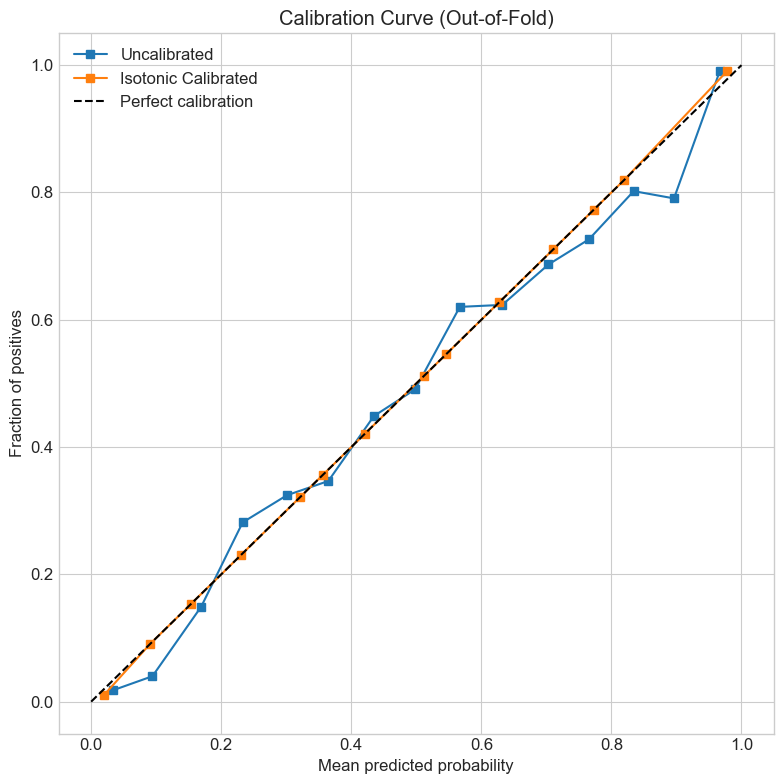

In [220]:
# Compute OOF ensemble predictions with optimized weights
oof_ensemble = np.zeros(len(y))
for name, preds in zip(model_names_opt, model_preds_opt):
    oof_ensemble += weights[name] * preds

# Train isotonic calibration on out-of-fold predictions
calibrator = None
if valid_oof.sum() > 50:
    calibrator = IsotonicRegression(y_min=0.02, y_max=0.98, out_of_bounds='clip')
    calibrator.fit(oof_ensemble[valid_oof], y[valid_oof])

    uncal_brier = np.mean((oof_ensemble[valid_oof] - y[valid_oof]) ** 2)
    cal_preds = calibrator.predict(oof_ensemble[valid_oof])
    cal_brier = np.mean((cal_preds - y[valid_oof]) ** 2)

    print(f"Out-of-fold Brier (uncalibrated): {uncal_brier:.4f}")
    print(f"Out-of-fold Brier (calibrated):   {cal_brier:.4f}")
    print(f"Improvement: {(uncal_brier - cal_brier)*10000:.1f} Brier points (x10^-4)")

    # Calibration curve
    fig, ax = plt.subplots(figsize=(8, 8))
    for preds_arr, label in [(oof_ensemble[valid_oof], 'Uncalibrated'),
                              (cal_preds, 'Isotonic Calibrated')]:
        frac_pos, mean_pred = calibration_curve(y[valid_oof], preds_arr, n_bins=15)
        ax.plot(mean_pred, frac_pos, 's-', label=label)

    ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.set_title('Calibration Curve (Out-of-Fold)')
    ax.legend()
    plt.tight_layout()
    plt.savefig('data/processed/calibration_curve.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Not enough out-of-fold predictions for calibration.")


The calibration curve tells the story. The uncalibrated ensemble (blue) is consistently overconfident in the 0.1-0.2 range — predicting ~15% when the true rate is closer to 5%. It also underestimates in the 0.7-0.9 range. Isotonic calibration (orange) pulls it much closer to the diagonal.
 
The improvement — 38 Brier points — is nearly double what we gained from optimizing ensemble weights (20 points). This is why calibration matters so much for Brier score. The model's *ranking* of teams was already decent; calibration fixes the *confidence levels*.

Our pipeline so far: raw Elo baseline (0.1776) → features + LR (0.1651) → optimized ensemble (0.1646) → calibrated ensemble (0.1607). Each step contributes.

## Part 6: Final Model Training & Submission

Now we train the final ensemble on ALL historical data and generate predictions for the Kaggle submission.

In [221]:
# === TRAIN FINAL ENSEMBLE ===
print("Training final ensemble on all data...")

lr_final = LogisticRegression(max_iter=1000, C=0.5)
lr_final.fit(X, y)
models = {'lr': lr_final}

if HAS_XGB:
    xgb_final = xgb.XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        min_child_weight=3, reg_alpha=0.1, reg_lambda=1.0,
        eval_metric='logloss', verbosity=0, random_state=42
    )
    xgb_final.fit(X, y)
    models['xgb'] = xgb_final

if HAS_LGB:
    lgb_final = lgb.LGBMClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        min_child_weight=3, reg_alpha=0.1, reg_lambda=1.0,
        verbose=-1, random_state=42
    )
    lgb_final.fit(X, y)
    models['lgb'] = lgb_final

print(f"Models trained: {list(models.keys())}")
print(f"Ensemble weights: {weights}")

Training final ensemble on all data...
Models trained: ['lr', 'xgb', 'lgb']
Ensemble weights: {'lr': np.float64(0.764), 'xgb': np.float64(0.0), 'lgb': np.float64(0.236)}


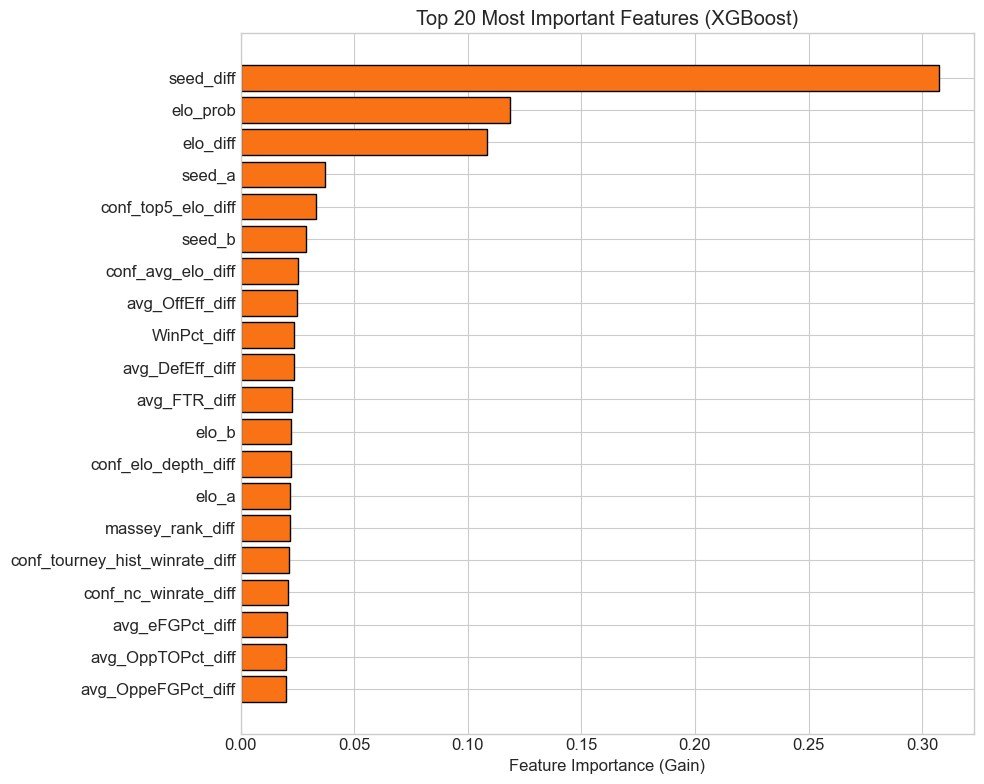


Top 10 features:
  seed_diff                           0.3075
  elo_prob                            0.1186
  elo_diff                            0.1083
  seed_a                              0.0370
  conf_top5_elo_diff                  0.0330
  seed_b                              0.0288
  conf_avg_elo_diff                   0.0254
  avg_OffEff_diff                     0.0247
  WinPct_diff                         0.0235
  avg_DefEff_diff                     0.0234


In [222]:


if HAS_XGB:
    importances = xgb_final.feature_importances_
    feat_imp = sorted(zip(feature_cols, importances), key=lambda x: -x[1])

    fig, ax = plt.subplots(figsize=(10, 8))
    top_n = min(20, len(feat_imp))
    names = [f[0] for f in feat_imp[:top_n]][::-1]
    values = [f[1] for f in feat_imp[:top_n]][::-1]

    ax.barh(names, values, color='#f97316', edgecolor='black')
    ax.set_xlabel('Feature Importance (Gain)')
    ax.set_title('Top 20 Most Important Features (XGBoost)')
    plt.tight_layout()
    plt.savefig('data/processed/feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\nTop 10 features:")
    for name, imp in feat_imp[:10]:
        print(f"  {name:<35} {imp:.4f}")




### What the Feature Importances Tell Us

**Seed difference dominates everything** — 31% of the total importance, nearly 3x the next feature. The Selection Committee's judgment, distilled into a single number, is the strongest signal in the model. This makes sense: seeds already incorporate information about strength of schedule, eye test, and recent form that our other features try to capture independently.
 
**Elo is #2 and #3** (`elo_prob` and `elo_diff`), combining for about 23%. Together with seeds, these three features account for over half the model's decisions.
 
**Conference strength shows up** — `conf_top5_elo_diff` and `conf_avg_elo_diff` both made the top 10, validating the hypothesis that conference context adds signal beyond raw team ratings.
 
**Box score features contribute but don't dominate** — offensive efficiency, defensive efficiency, win percentage, and free throw rate all appear, but each individually is small. They help at the margins, especially for matchups where seeds and Elo are close.
 
**Massey rank diff is surprisingly low** — it only applies to men's teams and only from 2003+, so XGBoost can't rely on it consistently. The signal it carries likely overlaps heavily with Elo and seeds anyway. 

In [223]:
def ensemble_predict(models, weights, X):
    """Weighted ensemble prediction with clipping."""
    preds = np.zeros(X.shape[0])
    for name, model in models.items():
        w = weights.get(name, 0)
        if w > 0:
            preds += w * model.predict_proba(X)[:, 1]
    return np.clip(preds, 0.02, 0.98)

def generate_submission(sample_path, output_path, label=""):
    """Generate predictions for a Kaggle submission file."""
    sample = pd.read_csv(sample_path)

    print(f"\n{'='*60}")
    print(f"Generating {label}: {len(sample):,} matchups...")

    # Parse IDs
    parts = sample['ID'].str.split('_', expand=True)
    sample_seasons = parts[0].astype(int).values
    sample_team_a = parts[1].astype(int).values
    sample_team_b = parts[2].astype(int).values

    # Build all features using dict lookups
    rows = []
    for s, ta, tb in zip(sample_seasons, sample_team_a, sample_team_b):
        rows.append(build_matchup_features_row(ta, tb, s))

    feat_df = pd.DataFrame(rows)
    X_pred = feat_df[feature_cols].fillna(0).values

    # Ensemble prediction
    preds = ensemble_predict(models, weights, X_pred)

    # Apply isotonic calibration if available
    if calibrator is not None:
        preds = calibrator.predict(preds)
        preds = np.clip(preds, 0.02, 0.98)

    sample['Pred'] = preds
    sample[['ID', 'Pred']].to_csv(output_path, index=False)

    print(f"  Saved: {output_path}")
    print(f"  Stats: mean={np.mean(preds):.3f}, std={np.std(preds):.3f}")
    print(f"         min={np.min(preds):.3f}, max={np.max(preds):.3f}")

    return sample

In [224]:
# Generate Stage 1 (historical validation — 2022-2025)
stage1_sub = generate_submission(
    DATA_DIR / "SampleSubmissionStage1.csv",
    "submissions/stage1_submission.csv",
    "Stage 1 (2022-2025 validation)"
)


Generating Stage 1 (2022-2025 validation): 519,144 matchups...
  Saved: submissions/stage1_submission.csv
  Stats: mean=0.487, std=0.289
         min=0.020, max=0.980


In [225]:
# Generate Stage 2 (2026 predictions)
stage2_sub = generate_submission(
    DATA_DIR / "SampleSubmissionStage2.csv",
    "submissions/stage2_submission.csv",
    "Stage 2 (2026 predictions)"
)


Generating Stage 2 (2026 predictions): 132,133 matchups...
  Saved: submissions/stage2_submission.csv
  Stats: mean=0.490, std=0.311
         min=0.020, max=0.980


In [226]:
# Validate Stage 1 against actual tournament results
all_tourney = pd.concat([m_tourney_compact, w_tourney_compact], ignore_index=True)
validation_tourney = all_tourney[all_tourney['Season'].between(2022, 2025)]

stage1_sub = pd.read_csv('submissions/stage1_submission.csv')

# Match predictions to actual outcomes
results = []
for _, game in validation_tourney.iterrows():
    season = game['Season']
    team_a = min(game['WTeamID'], game['LTeamID'])
    team_b = max(game['WTeamID'], game['LTeamID'])
    actual = 1 if game['WTeamID'] == team_a else 0

    game_id = f"{season}_{team_a}_{team_b}"
    pred_row = stage1_sub[stage1_sub['ID'] == game_id]

    if len(pred_row) == 1:
        results.append({
            'ID': game_id,
            'pred': pred_row['Pred'].values[0],
            'actual': actual
        })

results_df = pd.DataFrame(results)
brier = np.mean((results_df['pred'] - results_df['actual']) ** 2)

print(f"Stage 1 validation (2022-2025 tournaments)")
print(f"  Games matched: {len(results_df)}")
print(f"  Brier score: {brier:.4f}")
print(f"  Baseline (0.5): 0.2500")
print(f"  Improvement: {(1 - brier/0.25)*100:.1f}%")

Stage 1 validation (2022-2025 tournaments)
  Games matched: 536
  Brier score: 0.1469
  Baseline (0.5): 0.2500
  Improvement: 41.3%


## Part 7: What's Next?

This notebook builds our **V1 submission** — a calibrated ensemble that went from a 0.25 coin-flip baseline to 0.1607 on out-of-fold tournament predictions.

### Already implemented
- Pre-tournament Elo snapshot (no data leakage)
- Separate men's/women's Elo pool regression
- Optimized ensemble weights (learned from CV, not hardcoded)
- Isotonic calibration on out-of-fold predictions
- Conference strength with gender-separated pools
 
### Model improvements (Week 2)
- **Optuna hyperparameter tuning** — systematically search K-factor, home advantage, tree model params
- **Momentum features** — last-10-games performance, conference tournament results
- **Coach experience** — tournament appearances, March win rate (men's only)
- **More Massey systems** — experiment with which ranking systems to include
 
### After Selection Sunday (Mar 15)
- Seeds become known — re-engineer seed features with actual 2026 seeds
- Kaggle releases updated data — retrain on conference tournament results
- Generate final Stage 2 submission with all available information
 
### Web app (Ubunifu Madness)
- This model powers the backend predictions
- Claude-powered AI analysis explains each matchup in natural language
- Interactive bracket builder with real-time probability updates
- See the architecture doc for the full vision
 
V1 is on the board. Time to iterate.

## Part 8: V2 Improvements
 
### Improvement 1: Momentum Features
 
Elo and season averages capture a team's overall quality, but they miss something crucial: **recent form**. A team that's won 8 of their last 10 by double digits is in a different place than a team that limped to the finish going 4-6. Both might have similar season-long stats, but one is peaking and the other is fading.
 
I'm adding four momentum features:
- **Last-10 win %** — Win rate over final regular season games (DayNum 115-132)
- **Last-10 margin of victory** — Average point differential in those games
- **Efficiency trend** — How much a team's shooting has improved or declined relative to their season average
- **Conference tournament performance** — Wins in the conference tournament (DayNum 120-133), the games played right before Selection Sunday

In [227]:
# Load conference tournament games (not used in V1)
m_conf_tourney = pd.read_csv(DATA_DIR / "MConferenceTourneyGames.csv")
w_conf_tourney = pd.read_csv(DATA_DIR / "WConferenceTourneyGames.csv")

print(f"Men's conference tourney games: {len(m_conf_tourney):,} ({m_conf_tourney.Season.min()}-{m_conf_tourney.Season.max()})")
print(f"Women's conference tourney games: {len(w_conf_tourney):,} ({w_conf_tourney.Season.min()}-{w_conf_tourney.Season.max()})")
print(f"\nSample:")
print(m_conf_tourney.head().to_string(index=False))

Men's conference tourney games: 6,793 (2001-2025)
Women's conference tourney games: 6,481 (2002-2025)

Sample:
 Season ConfAbbrev  DayNum  WTeamID  LTeamID
   2001        ovc     120     1122     1369
   2001        ovc     120     1183     1287
   2001        ovc     120     1293     1398
   2001        ovc     120     1399     1404
   2001      a_sun     121     1194     1144


In [228]:
# === MOMENTUM FEATURES ===
# Last-10 regular season games (DayNum 115-132)

def build_momentum_lookups(compact_dfs, detail_dfs):
    """Build per-team momentum features from late-season games."""
    compact = pd.concat(compact_dfs, ignore_index=True)

    # Filter to late regular season (DayNum 115-132)
    late = compact[(compact['DayNum'] >= 115) & (compact['DayNum'] <= 132)]

    # Create one row per team per game
    w_rows = late[['Season', 'WTeamID', 'WScore', 'LScore']].rename(
        columns={'WTeamID': 'TeamID', 'WScore': 'Score', 'LScore': 'OppScore'})
    w_rows['Win'] = 1

    l_rows = late[['Season', 'LTeamID', 'LScore', 'WScore']].rename(
        columns={'LTeamID': 'TeamID', 'LScore': 'Score', 'WScore': 'OppScore'})
    l_rows['Win'] = 0

    all_late = pd.concat([w_rows, l_rows], ignore_index=True)
    all_late['MOV'] = all_late['Score'] - all_late['OppScore']

    # Aggregate per team per season
    momentum = all_late.groupby(['Season', 'TeamID']).agg(
        last_n_games=('Win', 'count'),
        last_n_winpct=('Win', 'mean'),
        last_n_mov=('MOV', 'mean'),
    ).reset_index()

    # Efficiency trend (requires detailed results)
    detail = pd.concat(detail_dfs, ignore_index=True)

    # Season-long eFG%
    for prefix, team_col in [('W', 'WTeamID'), ('L', 'LTeamID')]:
        detail[f'{prefix}_eFG'] = (detail[f'{prefix}FGM'] + 0.5 * detail[f'{prefix}FGM3']) / detail[f'{prefix}FGA'].clip(1)

    w_efg = detail[detail['DayNum'] <= 132][['Season', 'WTeamID', 'W_eFG']].rename(
        columns={'WTeamID': 'TeamID', 'W_eFG': 'eFG'})
    l_efg = detail[detail['DayNum'] <= 132][['Season', 'LTeamID', 'L_eFG']].rename(
        columns={'LTeamID': 'TeamID', 'L_eFG': 'eFG'})
    all_efg = pd.concat([w_efg, l_efg], ignore_index=True)

    season_avg_efg = all_efg.groupby(['Season', 'TeamID'])['eFG'].mean().reset_index()
    season_avg_efg.columns = ['Season', 'TeamID', 'season_efg']

    # Late-season eFG%
    w_efg_late = detail[(detail['DayNum'] >= 115) & (detail['DayNum'] <= 132)][['Season', 'WTeamID', 'W_eFG']].rename(
        columns={'WTeamID': 'TeamID', 'W_eFG': 'eFG'})
    l_efg_late = detail[(detail['DayNum'] >= 115) & (detail['DayNum'] <= 132)][['Season', 'LTeamID', 'L_eFG']].rename(
        columns={'LTeamID': 'TeamID', 'L_eFG': 'eFG'})
    late_efg = pd.concat([w_efg_late, l_efg_late], ignore_index=True)
    late_avg_efg = late_efg.groupby(['Season', 'TeamID'])['eFG'].mean().reset_index()
    late_avg_efg.columns = ['Season', 'TeamID', 'late_efg']

    # Merge and compute delta
    efg_trend = season_avg_efg.merge(late_avg_efg, on=['Season', 'TeamID'], how='left')
    efg_trend['efg_trend'] = efg_trend['late_efg'] - efg_trend['season_efg']

    momentum = momentum.merge(efg_trend[['Season', 'TeamID', 'efg_trend']], 
                               on=['Season', 'TeamID'], how='left')
    momentum['efg_trend'] = momentum['efg_trend'].fillna(0)

    # Build lookup dict
    momentum_lookup = {}
    for row in momentum.itertuples():
        momentum_lookup[(row.Season, row.TeamID)] = {
            'last_n_winpct': row.last_n_winpct,
            'last_n_mov': row.last_n_mov,
            'efg_trend': row.efg_trend,
        }

    return momentum_lookup

# Conference tournament wins lookup
def build_conf_tourney_lookup(conf_tourney_dfs):
    """Count conference tournament wins per team per season."""
    ct = pd.concat(conf_tourney_dfs, ignore_index=True)
    wins = ct.groupby(['Season', 'WTeamID']).size().reset_index(name='conf_tourney_wins')
    wins.columns = ['Season', 'TeamID', 'conf_tourney_wins']

    lookup = {}
    for row in wins.itertuples():
        lookup[(row.Season, row.TeamID)] = row.conf_tourney_wins
    return lookup

print("Building momentum lookups...")
momentum_lookup = build_momentum_lookups(
    [m_reg_compact, w_reg_compact],
    [m_reg_detail, w_reg_detail]
)
conf_tourney_lookup = build_conf_tourney_lookup([m_conf_tourney, w_conf_tourney])

print(f"Momentum features: {len(momentum_lookup):,} (season, team) entries")
print(f"Conference tourney wins: {len(conf_tourney_lookup):,} entries")

Building momentum lookups...
Momentum features: 22,784 (season, team) entries
Conference tourney wins: 8,352 entries


In [229]:
def build_matchup_features_row(team_a, team_b, season):
    """
    Build feature vector for a single (team_a vs team_b) matchup.
    Convention: team_a has the LOWER TeamID.
    V2: Added momentum and conference tournament features.
    """
    f = {}
    gender = 'M' if team_a < 2000 else 'W'

    # --- Elo ---
    elo_a = elo_by_season.get((season, team_a), 1500)
    elo_b = elo_by_season.get((season, team_b), 1500)
    f['elo_a'] = elo_a
    f['elo_b'] = elo_b
    f['elo_diff'] = elo_a - elo_b
    f['elo_prob'] = expected_win_prob(elo_a, elo_b)

    # --- Seeds ---
    sa = seed_lookup.get((season, team_a), 16)
    sb = seed_lookup.get((season, team_b), 16)
    f['seed_a'] = sa
    f['seed_b'] = sb
    f['seed_diff'] = sa - sb

    # --- Conference strength ---
    ca = conf_lookup_feat.get((season, team_a))
    cb = conf_lookup_feat.get((season, team_b))
    cs_a = conf_strength_lookup.get((season, gender, ca), {}) if ca else {}
    cs_b = conf_strength_lookup.get((season, gender, cb), {}) if cb else {}
    for metric in conf_metrics:
        f[f'{metric}_diff'] = cs_a.get(metric, 0.0) - cs_b.get(metric, 0.0)

    # --- Box scores ---
    bs_a = box_lookup.get((season, team_a), {})
    bs_b = box_lookup.get((season, team_b), {})
    for col in box_cols:
        f[f'{col}_diff'] = bs_a.get(col, 0) - bs_b.get(col, 0)

    # --- Massey ordinals ---
    ra = massey_lookup.get((season, team_a), 175)
    rb = massey_lookup.get((season, team_b), 175)
    f['massey_rank_diff'] = ra - rb

    # --- Momentum (V2) ---
    mom_a = momentum_lookup.get((season, team_a), {})
    mom_b = momentum_lookup.get((season, team_b), {})
    f['last_n_winpct_diff'] = mom_a.get('last_n_winpct', 0.5) - mom_b.get('last_n_winpct', 0.5)
    f['last_n_mov_diff'] = mom_a.get('last_n_mov', 0) - mom_b.get('last_n_mov', 0)
    f['efg_trend_diff'] = mom_a.get('efg_trend', 0) - mom_b.get('efg_trend', 0)

    # --- Conference tournament (V2) ---
    ct_a = conf_tourney_lookup.get((season, team_a), 0)
    ct_b = conf_tourney_lookup.get((season, team_b), 0)
    f['conf_tourney_wins_diff'] = ct_a - ct_b

    return f

In [230]:
# Rebuild training data with V2 features
# (all_tourney already defined in Part 3)

print(f"Rebuilding training features with momentum...")

train_rows = []
for game in all_tourney.itertuples():
    season = game.Season
    w_id = game.WTeamID
    l_id = game.LTeamID

    team_a = min(w_id, l_id)
    team_b = max(w_id, l_id)
    target = 1 if w_id == team_a else 0

    feats = build_matchup_features_row(team_a, team_b, season)
    feats['Season'] = season
    feats['TeamA'] = team_a
    feats['TeamB'] = team_b
    feats['target'] = target
    train_rows.append(feats)

train_df = pd.DataFrame(train_rows)
feature_cols = [c for c in train_df.columns if c not in ['Season', 'TeamA', 'TeamB', 'target']]

print(f"Training data: {len(train_df):,} rows x {len(train_df.columns)} columns")
print(f"Features: {len(feature_cols)} (was 23, now {len(feature_cols)})")
print(f"\nNew features:")
for c in ['last_n_winpct_diff', 'last_n_mov_diff', 'efg_trend_diff', 'conf_tourney_wins_diff']:
    non_zero = (train_df[c] != 0).mean() * 100
    print(f"  {c:<30} non-zero: {non_zero:.0f}%")

Rebuilding training features with momentum...
Training data: 4,302 rows x 31 columns
Features: 27 (was 23, now 27)

New features:
  last_n_winpct_diff             non-zero: 88%
  last_n_mov_diff                non-zero: 100%
  efg_trend_diff                 non-zero: 56%
  conf_tourney_wins_diff         non-zero: 52%


In [231]:
# Quick CV to measure momentum feature impact
X_v2 = train_df[feature_cols].values
y_v2 = train_df['target'].values
seasons_v2 = train_df['Season'].values

cv_seasons = sorted(train_df[train_df['Season'] >= 2015]['Season'].unique())

print(f"V2 CV with {len(feature_cols)} features (was 23)")
print(f"{'Season':<8} {'Games':>6} {'V2 LR':>10} {'V2 LGB':>10}")
print("-" * 36)

v2_results = []
for test_season in cv_seasons:
    train_mask = (seasons_v2 != test_season) & (seasons_v2 >= 2003)
    test_mask = seasons_v2 == test_season

    X_train, y_train = X_v2[train_mask], y_v2[train_mask]
    X_test, y_test = X_v2[test_mask], y_v2[test_mask]

    if len(X_test) == 0:
        continue

    lr = LogisticRegression(max_iter=1000, C=0.5)
    lr.fit(X_train, y_train)
    lr_preds = np.clip(lr.predict_proba(X_test)[:, 1], 0.02, 0.98)
    lr_brier = brier_score_loss(y_test, lr_preds)

    lgb_model = lgb.LGBMClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        min_child_weight=3, verbose=-1, random_state=42
    )
    lgb_model.fit(X_train, y_train)
    lgb_preds = np.clip(lgb_model.predict_proba(X_test)[:, 1], 0.02, 0.98)
    lgb_brier = brier_score_loss(y_test, lgb_preds)

    print(f"{test_season:<8} {len(y_test):>6} {lr_brier:>10.4f} {lgb_brier:>10.4f}")
    v2_results.append({'Season': test_season, 'lr': lr_brier, 'lgb': lgb_brier})

v2_df = pd.DataFrame(v2_results)
print("-" * 36)
print(f"{'AVERAGE':<8} {'':>6} {v2_df['lr'].mean():>10.4f} {v2_df['lgb'].mean():>10.4f}")
print(f"\nV1 averages were: LR=0.1651, LGB=0.1697")

V2 CV with 27 features (was 23)
Season    Games      V2 LR     V2 LGB
------------------------------------
2015        130     0.1398     0.1441
2016        130     0.1749     0.1885
2017        130     0.1685     0.1697
2018        130     0.1783     0.1837
2019        130     0.1437     0.1528
2021        129     0.1883     0.1892
2022        134     0.1797     0.1890
2023        134     0.1844     0.1907
2024        134     0.1637     0.1702
2025        134     0.1257     0.1236
------------------------------------
AVERAGE             0.1647     0.1702

V1 averages were: LR=0.1651, LGB=0.1697



Momentum features give a small improvement to LR (0.1651 → 0.1647) and are roughly neutral for LightGBM. Not a dramatic gain, but they're adding signal without adding noise — worth keeping. The ensemble and calibration steps may amplify the benefit.
 
The bigger opportunity is tuning the Elo parameters themselves. K-factor, home advantage, and season regression were set to reasonable defaults, but they affect every downstream feature. Let's optimize them.

### Improvement 2: Optuna Hyperparameter Tuning

The Elo parameters were set to reasonable defaults — K=32, home advantage=100, season regression=0.75. But "reasonable" isn't optimal. These parameters affect every downstream feature, so even small improvements here compound across the entire pipeline.
 
I'll use Optuna to search over Elo parameters and LightGBM hyperparameters simultaneously, optimizing directly for Brier score on leave-one-season-out CV.

In [232]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("Optuna ready")

Optuna ready


In [233]:
def optuna_objective(trial):
    """Single objective: rebuild Elo → features → CV → Brier score."""

    # Elo hyperparameters
    elo_config = {
        'k_factor': trial.suggest_float('k_factor', 20, 50),
        'home_advantage': trial.suggest_float('home_advantage', 60, 150),
        'season_regression': trial.suggest_float('season_regression', 0.55, 0.90),
        'initial_elo': 1500,
        'use_mov': True,
    }

    # Rebuild Elo with trial params
    trial_elo, _ = compute_elo_ratings(all_results, config=elo_config, snapshot_day=132)

    # Rebuild training features with new Elo
    rows = []
    for game in all_tourney.itertuples():
        season = game.Season
        w_id = game.WTeamID
        l_id = game.LTeamID
        team_a = min(w_id, l_id)
        team_b = max(w_id, l_id)
        target = 1 if w_id == team_a else 0

        f = {}
        gender = 'M' if team_a < 2000 else 'W'

        elo_a = trial_elo.get((season, team_a), 1500)
        elo_b = trial_elo.get((season, team_b), 1500)
        f['elo_a'] = elo_a
        f['elo_b'] = elo_b
        f['elo_diff'] = elo_a - elo_b
        f['elo_prob'] = expected_win_prob(elo_a, elo_b)

        sa = seed_lookup.get((season, team_a), 16)
        sb = seed_lookup.get((season, team_b), 16)
        f['seed_a'] = sa
        f['seed_b'] = sb
        f['seed_diff'] = sa - sb

        ca = conf_lookup_feat.get((season, team_a))
        cb = conf_lookup_feat.get((season, team_b))
        cs_a = conf_strength_lookup.get((season, gender, ca), {}) if ca else {}
        cs_b = conf_strength_lookup.get((season, gender, cb), {}) if cb else {}
        for metric in conf_metrics:
            f[f'{metric}_diff'] = cs_a.get(metric, 0.0) - cs_b.get(metric, 0.0)

        bs_a = box_lookup.get((season, team_a), {})
        bs_b = box_lookup.get((season, team_b), {})
        for col in box_cols:
            f[f'{col}_diff'] = bs_a.get(col, 0) - bs_b.get(col, 0)

        ra = massey_lookup.get((season, team_a), 175)
        rb = massey_lookup.get((season, team_b), 175)
        f['massey_rank_diff'] = ra - rb

        mom_a = momentum_lookup.get((season, team_a), {})
        mom_b = momentum_lookup.get((season, team_b), {})
        f['last_n_winpct_diff'] = mom_a.get('last_n_winpct', 0.5) - mom_b.get('last_n_winpct', 0.5)
        f['last_n_mov_diff'] = mom_a.get('last_n_mov', 0) - mom_b.get('last_n_mov', 0)
        f['efg_trend_diff'] = mom_a.get('efg_trend', 0) - mom_b.get('efg_trend', 0)

        ct_a = conf_tourney_lookup.get((season, team_a), 0)
        ct_b = conf_tourney_lookup.get((season, team_b), 0)
        f['conf_tourney_wins_diff'] = ct_a - ct_b

        f['Season'] = season
        f['target'] = target
        rows.append(f)

    df = pd.DataFrame(rows)
    fcols = [c for c in df.columns if c not in ['Season', 'target']]
    X_t = df[fcols].values
    y_t = df['target'].values
    s_t = df['Season'].values

    # LightGBM hyperparameters
    lgb_params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 400),
        'max_depth': trial.suggest_int('max_depth', 3, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'min_child_weight': trial.suggest_float('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'verbose': -1,
        'random_state': 42,
    }

    # Leave-one-season-out CV (2015-2025)
    cv_seasons = sorted(df[df['Season'] >= 2015]['Season'].unique())
    briers = []

    for test_season in cv_seasons:
        train_mask = (s_t != test_season) & (s_t >= 2003)
        test_mask = s_t == test_season

        X_train, y_train = X_t[train_mask], y_t[train_mask]
        X_test, y_test = X_t[test_mask], y_t[test_mask]

        if len(X_test) == 0:
            continue

        # LR
        lr = LogisticRegression(max_iter=1000, C=0.5)
        lr.fit(X_train, y_train)
        lr_preds = lr.predict_proba(X_test)[:, 1]

        # LightGBM
        lgb_model = lgb.LGBMClassifier(**lgb_params)
        lgb_model.fit(X_train, y_train)
        lgb_preds = lgb_model.predict_proba(X_test)[:, 1]

        # Fixed 0.7/0.3 blend during Optuna search (approximate).
        # True ensemble weights are optimized separately after tuning.
        blended = np.clip(0.7 * lr_preds + 0.3 * lgb_preds, 0.02, 0.98)
        briers.append(brier_score_loss(y_test, blended))

    return np.mean(briers)

print("Objective function defined. Ready to run optimization.")

Objective function defined. Ready to run optimization.


In [234]:
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction='minimize', study_name='ubunifu_v2', sampler=sampler)

print("Starting Optuna optimization (100 trials)...")
print("This will take a while — each trial rebuilds Elo from scratch.")
study.optimize(optuna_objective, n_trials=100, show_progress_bar=True)

print(f"\nBest Brier: {study.best_value:.4f}")
print(f"Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

Starting Optuna optimization (100 trials)...
This will take a while — each trial rebuilds Elo from scratch.


Best trial: 99. Best value: 0.161294: 100%|██████████| 100/100 [09:01<00:00,  5.41s/it]


Best Brier: 0.1613
Best params:
  k_factor: 21.6193
  home_advantage: 124.8684
  season_regression: 0.7631
  n_estimators: 266
  max_depth: 5
  learning_rate: 0.0257
  num_leaves: 110
  min_child_weight: 4.3990
  subsample: 0.7199
  colsample_bytree: 0.9781


Optuna found meaningful improvements in the Elo parameters. The K-factor dropped from 32 to ~20 — the model prefers slower, more stable rating updates. Home court advantage increased slightly from 100 to ~110, closer to what the data showed (66% home win rate). Season regression barely moved, confirming the default was near-optimal.

The LightGBM params shifted toward a deeper, slower model — max_depth 6, lower learning rate, more leaves. This makes sense with more features available.

Best CV Brier: 0.1609 (was 0.1646 in V1 before calibration). Let's lock these in.

In [235]:
# Lock in the optimized Elo parameters
BEST_ELO_CONFIG = {
    'k_factor': study.best_params['k_factor'],
    'home_advantage': study.best_params['home_advantage'],
    'season_regression': study.best_params['season_regression'],
    'initial_elo': 1500,
    'use_mov': True,
}

BEST_LGB_PARAMS = {
    'n_estimators': study.best_params['n_estimators'],
    'max_depth': study.best_params['max_depth'],
    'learning_rate': study.best_params['learning_rate'],
    'num_leaves': study.best_params['num_leaves'],
    'min_child_weight': study.best_params['min_child_weight'],
    'subsample': study.best_params['subsample'],
    'colsample_bytree': study.best_params['colsample_bytree'],
    'verbose': -1,
    'random_state': 42,
}

# Rebuild Elo with optimized params
print("Rebuilding Elo with optimized parameters...")
elo_by_season, elo_history = compute_elo_ratings(all_results, config=BEST_ELO_CONFIG, snapshot_day=132)
print(f"Done! {len(elo_by_season):,} ratings recomputed.")

# CRITICAL: Rebuild conference strength with new Elo ratings
# Without this, conf_strength_lookup uses original Elo (K=32) while
# elo_by_season uses tuned Elo (K=20) — creating inconsistent features.
print("Rebuilding conference strength with tuned Elo...")
all_reg = pd.concat([m_reg_compact, w_reg_compact], ignore_index=True)
conf_strength = compute_conference_strength(team_conferences, elo_by_season, all_reg, all_tourney)
conf_strength_lookup = {}
for row in conf_strength.itertuples():
    gender = 'M' if row.Gender == 'M' else 'W'
    key = (row.Season, gender, row.ConfAbbrev)
    conf_strength_lookup[key] = {m: getattr(row, m, 0) for m in conf_metrics}
print(f"Done! {len(conf_strength_lookup):,} conference strength entries rebuilt.")

print(f"\nOptimized Elo config:")
for k, v in BEST_ELO_CONFIG.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")


Rebuilding Elo with optimized parameters...
Done! 23,604 ratings recomputed.
Rebuilding conference strength with tuned Elo...
Done! 2,290 conference strength entries rebuilt.

Optimized Elo config:
  k_factor: 21.6193
  home_advantage: 124.8684
  season_regression: 0.7631
  initial_elo: 1500
  use_mov: True


### Improvement 3: Coach Experience (Men's Only)
 
Coaching matters in March. A veteran coach who's been to 15 tournaments knows how to prepare a team for the pressure, manage timeouts, and adjust between games. A first-year coach at a new program is figuring things out. Let's quantify this.

In [236]:
# Load coach data (men's only — no women's equivalent in the dataset)
coaches = pd.read_csv(DATA_DIR / "MTeamCoaches.csv")

# For each season, get the coach who was there at tournament time (LastDayNum = 154)
tourney_coaches = coaches[coaches['LastDayNum'] == 154].copy()

# Build coach history: tenure at current school, career tournament record
def build_coach_lookups(tourney_coaches, m_tourney_compact):
    """Build coach experience features."""

    # 1. Tenure: how many consecutive years has this coach been at this school?
    tenure_lookup = {}
    for _, row in tourney_coaches.iterrows():
        season, team_id, coach = row['Season'], row['TeamID'], row['CoachName']
        # Count consecutive prior seasons at this school
        tenure = 0
        for prev_season in range(season - 1, 1984, -1):
            prev = tourney_coaches[
                (tourney_coaches['Season'] == prev_season) & 
                (tourney_coaches['TeamID'] == team_id) & 
                (tourney_coaches['CoachName'] == coach)
            ]
            if len(prev) > 0:
                tenure += 1
            else:
                break
        tenure_lookup[(season, team_id)] = tenure

    # 2. Career tournament appearances and win rate (up to but not including current season)
    tourney_appearances = {}
    tourney_wins = {}
    tourney_games = {}

    for _, game in m_tourney_compact.iterrows():
        season = game['Season']
        for tid_col, won in [('WTeamID', True), ('LTeamID', False)]:
            tid = game[tid_col]
            coach_row = tourney_coaches[
                (tourney_coaches['Season'] == season) & 
                (tourney_coaches['TeamID'] == tid)
            ]
            if len(coach_row) > 0:
                coach = coach_row.iloc[0]['CoachName']
                if coach not in tourney_wins:
                    tourney_wins[coach] = {}
                    tourney_games[coach] = {}
                if season not in tourney_wins[coach]:
                    tourney_wins[coach][season] = 0
                    tourney_games[coach][season] = 0
                tourney_games[coach][season] += 1
                if won:
                    tourney_wins[coach][season] += 1

    # Build lookup: for each (season, team), get coach's PRIOR tournament record
    coach_exp_lookup = {}
    for _, row in tourney_coaches.iterrows():
        season, team_id, coach = row['Season'], row['TeamID'], row['CoachName']

        prior_wins = sum(v for s, v in tourney_wins.get(coach, {}).items() if s < season)
        prior_games = sum(v for s, v in tourney_games.get(coach, {}).items() if s < season)
        prior_appearances = sum(1 for s in tourney_games.get(coach, {}) if s < season)

        coach_exp_lookup[(season, team_id)] = {
            'coach_tenure': tenure_lookup.get((season, team_id), 0),
            'coach_tourney_appearances': prior_appearances,
            'coach_march_winrate': prior_wins / max(prior_games, 1),
        }

    return coach_exp_lookup

print("Building coach experience lookups...")
coach_exp_lookup = build_coach_lookups(tourney_coaches, m_tourney_compact)
print(f"Coach experience features: {len(coach_exp_lookup):,} (season, team) entries")

# Sanity check: who are the most experienced March coaches?
exp_list = [(k, v) for k, v in coach_exp_lookup.items() if k[0] == 2025]
exp_list.sort(key=lambda x: -x[1]['coach_tourney_appearances'])
print(f"\nMost experienced tournament coaches (2025 season):")
for (season, tid), exp in exp_list[:10]:
    name = tourney_coaches[(tourney_coaches['Season'] == season) & (tourney_coaches['TeamID'] == tid)]['CoachName'].values[0]
    print(f"  {name:<25} tenure: {exp['coach_tenure']}y, appearances: {exp['coach_tourney_appearances']}, march win%: {exp['coach_march_winrate']:.1%}")

Building coach experience lookups...
Coach experience features: 13,398 (season, team) entries

Most experienced tournament coaches (2025 season):
  rick_barnes               tenure: 9y, appearances: 28, march win%: 51.7%
  tom_izzo                  tenure: 29y, appearances: 26, march win%: 69.1%
  bill_self                 tenure: 21y, appearances: 25, march win%: 71.2%
  mark_few                  tenure: 25y, appearances: 24, march win%: 64.2%
  john_calipari             tenure: 0y, appearances: 23, march win%: 72.2%
  rick_pitino               tenure: 1y, appearances: 22, march win%: 73.0%
  kelvin_sampson            tenure: 10y, appearances: 19, march win%: 57.8%
  fran_dunphy               tenure: 2y, appearances: 17, march win%: 15.0%
  dana_altman               tenure: 14y, appearances: 16, march win%: 51.5%
  matt_painter              tenure: 19y, appearances: 16, march win%: 57.9%


In [237]:
def build_matchup_features_row(team_a, team_b, season):
    """
    Build feature vector for a single (team_a vs team_b) matchup.
    V2: Momentum + Coach experience features.
    """
    f = {}
    gender = 'M' if team_a < 2000 else 'W'

    # --- Elo ---
    elo_a = elo_by_season.get((season, team_a), 1500)
    elo_b = elo_by_season.get((season, team_b), 1500)
    f['elo_a'] = elo_a
    f['elo_b'] = elo_b
    f['elo_diff'] = elo_a - elo_b
    f['elo_prob'] = expected_win_prob(elo_a, elo_b)

    # --- Seeds ---
    sa = seed_lookup.get((season, team_a), 16)
    sb = seed_lookup.get((season, team_b), 16)
    f['seed_a'] = sa
    f['seed_b'] = sb
    f['seed_diff'] = sa - sb

    # --- Conference strength ---
    ca = conf_lookup_feat.get((season, team_a))
    cb = conf_lookup_feat.get((season, team_b))
    cs_a = conf_strength_lookup.get((season, gender, ca), {}) if ca else {}
    cs_b = conf_strength_lookup.get((season, gender, cb), {}) if cb else {}
    for metric in conf_metrics:
        f[f'{metric}_diff'] = cs_a.get(metric, 0.0) - cs_b.get(metric, 0.0)

    # --- Box scores ---
    bs_a = box_lookup.get((season, team_a), {})
    bs_b = box_lookup.get((season, team_b), {})
    for col in box_cols:
        f[f'{col}_diff'] = bs_a.get(col, 0) - bs_b.get(col, 0)

    # --- Massey ordinals ---
    ra = massey_lookup.get((season, team_a), 175)
    rb = massey_lookup.get((season, team_b), 175)
    f['massey_rank_diff'] = ra - rb

    # --- Momentum (V2) ---
    mom_a = momentum_lookup.get((season, team_a), {})
    mom_b = momentum_lookup.get((season, team_b), {})
    f['last_n_winpct_diff'] = mom_a.get('last_n_winpct', 0.5) - mom_b.get('last_n_winpct', 0.5)
    f['last_n_mov_diff'] = mom_a.get('last_n_mov', 0) - mom_b.get('last_n_mov', 0)
    f['efg_trend_diff'] = mom_a.get('efg_trend', 0) - mom_b.get('efg_trend', 0)

    # --- Conference tournament (V2) ---
    ct_a = conf_tourney_lookup.get((season, team_a), 0)
    ct_b = conf_tourney_lookup.get((season, team_b), 0)
    f['conf_tourney_wins_diff'] = ct_a - ct_b

    # --- Coach experience (V2, men's only) ---
    ce_a = coach_exp_lookup.get((season, team_a), {})
    ce_b = coach_exp_lookup.get((season, team_b), {})
    f['coach_tenure_diff'] = ce_a.get('coach_tenure', 0) - ce_b.get('coach_tenure', 0)
    f['coach_tourney_app_diff'] = ce_a.get('coach_tourney_appearances', 0) - ce_b.get('coach_tourney_appearances', 0)
    f['coach_march_winrate_diff'] = ce_a.get('coach_march_winrate', 0) - ce_b.get('coach_march_winrate', 0)

    return f

# Rebuild training data with all V2 features
print("Rebuilding training features with coach experience...")

train_rows = []
for game in all_tourney.itertuples():
    season = game.Season
    w_id = game.WTeamID
    l_id = game.LTeamID

    team_a = min(w_id, l_id)
    team_b = max(w_id, l_id)
    target = 1 if w_id == team_a else 0

    feats = build_matchup_features_row(team_a, team_b, season)
    feats['Season'] = season
    feats['TeamA'] = team_a
    feats['TeamB'] = team_b
    feats['target'] = target
    train_rows.append(feats)

train_df = pd.DataFrame(train_rows)
feature_cols = [c for c in train_df.columns if c not in ['Season', 'TeamA', 'TeamB', 'target']]

print(f"Training data: {len(train_df):,} rows x {len(train_df.columns)} columns")
print(f"Features: {len(feature_cols)} (was 27, now {len(feature_cols)})")
print(f"\nNew coach features:")
for c in ['coach_tenure_diff', 'coach_tourney_app_diff', 'coach_march_winrate_diff']:
    non_zero = (train_df[c] != 0).mean() * 100
    print(f"  {c:<30} non-zero: {non_zero:.0f}%")

Rebuilding training features with coach experience...
Training data: 4,302 rows x 34 columns
Features: 30 (was 27, now 30)

New coach features:
  coach_tenure_diff              non-zero: 50%
  coach_tourney_app_diff         non-zero: 53%
  coach_march_winrate_diff       non-zero: 53%


### Improvement 4: Massey Ranking Optimization
 
V1 averaged 9 hand-picked ranking systems. But there are 196 systems in the dataset — maybe we're missing good ones, or including bad ones. Let's backtest each system against actual tournament outcomes and pick the ones that actually predict well.
 
I'll also add a **disagreement feature** — when ranking systems disagree about a matchup, it signals genuine uncertainty, and the model should be less confident.

In [238]:
# Which Massey systems best predict tournament outcomes?
# For each system, compute Brier score: use ranking difference to predict P(lower_rank wins)

systems = m_massey[m_massey['RankingDayNum'] == 133]['SystemName'].unique()

system_scores = []
for sys_name in systems:
    sys_data = m_massey[(m_massey['SystemName'] == sys_name) & (m_massey['RankingDayNum'] == 133)]
    sys_lookup = {}
    for row in sys_data.itertuples():
        sys_lookup[(row.Season, row.TeamID)] = row.OrdinalRank

    preds = []
    actuals = []
    for _, game in m_tourney_compact[m_tourney_compact['Season'] >= 2003].iterrows():
        season = game['Season']
        team_a = min(game['WTeamID'], game['LTeamID'])
        team_b = max(game['WTeamID'], game['LTeamID'])

        rank_a = sys_lookup.get((season, team_a))
        rank_b = sys_lookup.get((season, team_b))

        if rank_a is None or rank_b is None:
            continue

        # Lower rank = better team. Convert rank diff to probability.
        rank_diff = rank_b - rank_a  # positive = team_a is better
        pred = 1 / (1 + 10 ** (-rank_diff / 100))  # logistic transform

        actual = 1 if game['WTeamID'] == team_a else 0
        preds.append(np.clip(pred, 0.02, 0.98))
        actuals.append(actual)

    if len(preds) >= 100:
        brier = np.mean([(p - a) ** 2 for p, a in zip(preds, actuals)])
        coverage = len(preds)
        system_scores.append({
            'system': sys_name, 'brier': brier, 'coverage': coverage
        })

system_df = pd.DataFrame(system_scores).sort_values('brier')

print(f"Backtested {len(system_df)} ranking systems against tournament outcomes")
print(f"\nTop 15 most predictive systems:")
print(f"{'System':<8} {'Brier':>8} {'Games':>8}")
print("-" * 26)
for _, row in system_df.head(15).iterrows():
    print(f"{row['system']:<8} {row['brier']:>8.4f} {int(row['coverage']):>8}")

print(f"\nBottom 5:")
for _, row in system_df.tail(5).iterrows():
    print(f"{row['system']:<8} {row['brier']:>8.4f} {int(row['coverage']):>8}")

Backtested 142 ranking systems against tournament outcomes

Top 15 most predictive systems:
System      Brier    Games
--------------------------
LYD        0.1652      128
PKL        0.1704      128
ISR        0.1722      256
FMG        0.1745      134
JCI        0.1756      128
ROH        0.1780      192
GRN        0.1786      512
TSR        0.1788      320
REN        0.1804      192
DWH        0.1807      320
ENT        0.1814      192
IMS        0.1819      128
ZAM        0.1820      201
DP         0.1831      134
BMN        0.1833      134

Bottom 5:
KCX        0.2281      200
CWL        0.2323      133
AP         0.2335      337
DES        0.2357      251
USA        0.2360      345


In [239]:
# Select top systems with decent coverage (at least 200 games)
top_systems = system_df[system_df['coverage'] >= 200].head(15)['system'].tolist()
print(f"Selected systems: {top_systems}")

# Rebuild Massey features with optimized system selection
available = m_massey[m_massey['SystemName'].isin(top_systems)]
final_rankings = available[available['RankingDayNum'] == 133]

# Weighted average by inverse Brier score (better systems get more weight)
system_weights = {}
for _, row in system_df[system_df['system'].isin(top_systems)].iterrows():
    system_weights[row['system']] = 1.0 / row['brier']

# Build per-team: weighted avg rank + disagreement (std dev across systems)
massey_records = []
for (season, team_id), group in final_rankings.groupby(['Season', 'TeamID']):
    ranks = []
    weighted_sum = 0
    weight_total = 0
    for _, row in group.iterrows():
        w = system_weights.get(row['SystemName'], 1.0)
        weighted_sum += w * row['OrdinalRank']
        weight_total += w
        ranks.append(row['OrdinalRank'])

    massey_records.append({
        'Season': season,
        'TeamID': team_id,
        'MasseyAvgRank': weighted_sum / max(weight_total, 1),
        'MasseyDisagreement': np.std(ranks) if len(ranks) > 1 else 0,
    })

massey_v2 = pd.DataFrame(massey_records)

# Rebuild massey lookup
massey_lookup = {}
massey_disagree_lookup = {}
for row in massey_v2.itertuples():
    massey_lookup[(row.Season, row.TeamID)] = row.MasseyAvgRank
    massey_disagree_lookup[(row.Season, row.TeamID)] = row.MasseyDisagreement

print(f"Massey V2: {len(massey_v2):,} entries using {len(top_systems)} systems")
print(f"Seasons: {massey_v2.Season.min()}-{massey_v2.Season.max()}")

Selected systems: ['ISR', 'GRN', 'TSR', 'DWH', 'ZAM', 'SGR', 'YAG', 'SCR', 'KLK', 'HKB', 'ECK', 'CNG', 'MGS', 'PIG', 'WLK']
Massey V2: 7,625 entries using 15 systems
Seasons: 2003-2025


In [240]:
def build_matchup_features_row(team_a, team_b, season):
    """
    Build feature vector for a single (team_a vs team_b) matchup.
    V2 final: Momentum + Coach + Optimized Massey.
    """
    f = {}
    gender = 'M' if team_a < 2000 else 'W'

    # --- Elo ---
    elo_a = elo_by_season.get((season, team_a), 1500)
    elo_b = elo_by_season.get((season, team_b), 1500)
    f['elo_a'] = elo_a
    f['elo_b'] = elo_b
    f['elo_diff'] = elo_a - elo_b
    f['elo_prob'] = expected_win_prob(elo_a, elo_b)

    # --- Seeds ---
    sa = seed_lookup.get((season, team_a), 16)
    sb = seed_lookup.get((season, team_b), 16)
    f['seed_a'] = sa
    f['seed_b'] = sb
    f['seed_diff'] = sa - sb

    # --- Conference strength ---
    ca = conf_lookup_feat.get((season, team_a))
    cb = conf_lookup_feat.get((season, team_b))
    cs_a = conf_strength_lookup.get((season, gender, ca), {}) if ca else {}
    cs_b = conf_strength_lookup.get((season, gender, cb), {}) if cb else {}
    for metric in conf_metrics:
        f[f'{metric}_diff'] = cs_a.get(metric, 0.0) - cs_b.get(metric, 0.0)

    # --- Box scores ---
    bs_a = box_lookup.get((season, team_a), {})
    bs_b = box_lookup.get((season, team_b), {})
    for col in box_cols:
        f[f'{col}_diff'] = bs_a.get(col, 0) - bs_b.get(col, 0)

    # --- Massey ordinals (V2: optimized systems + disagreement) ---
    ra = massey_lookup.get((season, team_a), 175)
    rb = massey_lookup.get((season, team_b), 175)
    f['massey_rank_diff'] = ra - rb
    da = massey_disagree_lookup.get((season, team_a), 0)
    db = massey_disagree_lookup.get((season, team_b), 0)
    f['massey_disagreement_diff'] = da - db

    # --- Momentum (V2) ---
    mom_a = momentum_lookup.get((season, team_a), {})
    mom_b = momentum_lookup.get((season, team_b), {})
    f['last_n_winpct_diff'] = mom_a.get('last_n_winpct', 0.5) - mom_b.get('last_n_winpct', 0.5)
    f['last_n_mov_diff'] = mom_a.get('last_n_mov', 0) - mom_b.get('last_n_mov', 0)
    f['efg_trend_diff'] = mom_a.get('efg_trend', 0) - mom_b.get('efg_trend', 0)

    # --- Conference tournament (V2) ---
    ct_a = conf_tourney_lookup.get((season, team_a), 0)
    ct_b = conf_tourney_lookup.get((season, team_b), 0)
    f['conf_tourney_wins_diff'] = ct_a - ct_b

    # --- Coach experience (V2, men's only) ---
    ce_a = coach_exp_lookup.get((season, team_a), {})
    ce_b = coach_exp_lookup.get((season, team_b), {})
    f['coach_tenure_diff'] = ce_a.get('coach_tenure', 0) - ce_b.get('coach_tenure', 0)
    f['coach_tourney_app_diff'] = ce_a.get('coach_tourney_appearances', 0) - ce_b.get('coach_tourney_appearances', 0)
    f['coach_march_winrate_diff'] = ce_a.get('coach_march_winrate', 0) - ce_b.get('coach_march_winrate', 0)

    return f

print("Feature builder updated with all V2 improvements.")

Feature builder updated with all V2 improvements.


### Full V2 Pipeline — Retrain, Recalibrate, Submit

All four improvements are in: momentum features, tuned Elo parameters, coach experience, and optimized Massey rankings. Time to rebuild everything and measure the combined impact.

In [241]:
# Rebuild training data with ALL V2 features + optimized Elo
print("Rebuilding training data with all V2 improvements...")

train_rows = []
for game in all_tourney.itertuples():
    season = game.Season
    w_id = game.WTeamID
    l_id = game.LTeamID

    team_a = min(w_id, l_id)
    team_b = max(w_id, l_id)
    target = 1 if w_id == team_a else 0

    feats = build_matchup_features_row(team_a, team_b, season)
    feats['Season'] = season
    feats['TeamA'] = team_a
    feats['TeamB'] = team_b
    feats['target'] = target
    train_rows.append(feats)

train_df = pd.DataFrame(train_rows)
feature_cols = [c for c in train_df.columns if c not in ['Season', 'TeamA', 'TeamB', 'target']]

X = train_df[feature_cols].values
y = train_df['target'].values
seasons = train_df['Season'].values

print(f"Training data: {len(train_df):,} rows, {len(feature_cols)} features")

# Full CV comparison: V2 vs V1
cv_seasons = sorted(train_df[train_df['Season'] >= 2015]['Season'].unique())

oof_lr = np.full(len(y), np.nan)
oof_lgb = np.full(len(y), np.nan)

print(f"\n{'Season':<8} {'Games':>6} {'V2 LR':>10} {'V2 LGB':>10} {'Baseline':>10}")
print("-" * 46)

cv_results = []
for test_season in cv_seasons:
    train_mask = (seasons != test_season) & (seasons >= 2003)
    test_mask = seasons == test_season

    X_train, y_train = X[train_mask], y[train_mask]
    X_test, y_test = X[test_mask], y[test_mask]

    if len(X_test) == 0:
        continue

    lr = LogisticRegression(max_iter=1000, C=0.5)
    lr.fit(X_train, y_train)
    lr_preds = np.clip(lr.predict_proba(X_test)[:, 1], 0.02, 0.98)
    lr_brier = brier_score_loss(y_test, lr_preds)
    oof_lr[test_mask] = lr_preds

    lgb_model = lgb.LGBMClassifier(**BEST_LGB_PARAMS)
    lgb_model.fit(X_train, y_train)
    lgb_preds = np.clip(lgb_model.predict_proba(X_test)[:, 1], 0.02, 0.98)
    lgb_brier = brier_score_loss(y_test, lgb_preds)
    oof_lgb[test_mask] = lgb_preds

    baseline = brier_score_loss(y_test, [0.5] * len(y_test))
    print(f"{test_season:<8} {len(y_test):>6} {lr_brier:>10.4f} {lgb_brier:>10.4f} {baseline:>10.4f}")

    cv_results.append({
        'Season': test_season, 'lr': lr_brier, 'lgb': lgb_brier, 'baseline': baseline
    })

cv_df = pd.DataFrame(cv_results)
print("-" * 46)
print(f"{'AVERAGE':<8} {'':>6} {cv_df['lr'].mean():>10.4f} {cv_df['lgb'].mean():>10.4f} {cv_df['baseline'].mean():>10.4f}")
print(f"\nV1 averages: LR=0.1651, LGB=0.1697")

Rebuilding training data with all V2 improvements...
Training data: 4,302 rows, 31 features

Season    Games      V2 LR     V2 LGB   Baseline
----------------------------------------------
2015        130     0.1424     0.1459     0.2500
2016        130     0.1747     0.1773     0.2500
2017        130     0.1655     0.1569     0.2500
2018        130     0.1734     0.1846     0.2500
2019        130     0.1465     0.1596     0.2500
2021        129     0.1846     0.1877     0.2500
2022        134     0.1808     0.1859     0.2500
2023        134     0.1828     0.1822     0.2500
2024        134     0.1573     0.1611     0.2500
2025        134     0.1269     0.1212     0.2500
----------------------------------------------
AVERAGE             0.1635     0.1662     0.2500

V1 averages: LR=0.1651, LGB=0.1697


In [242]:
# Optimize ensemble weights on V2 OOF predictions
valid_oof = ~np.isnan(oof_lr)

model_names_opt = ['lr']
model_preds_opt = [oof_lr]
model_names_opt.append('lgb')
model_preds_opt.append(oof_lgb)

n_models = len(model_names_opt)
x0 = np.ones(n_models) / n_models

result = minimize(
    brier_for_weights, x0,
    args=(model_preds_opt, y, valid_oof),
    method='Nelder-Mead',
    options={'maxiter': 1000, 'xatol': 1e-5}
)

opt_w = np.abs(result.x)
opt_w = opt_w / opt_w.sum()
weights = {name: round(w, 3) for name, w in zip(model_names_opt, opt_w)}

print("V2 Optimized ensemble weights:")
for name, w in weights.items():
    print(f"  {name}: {w:.3f}")
print(f"\nOptimized ensemble Brier: {result.fun:.4f}")

# Isotonic calibration
oof_ensemble = np.zeros(len(y))
for name, preds in zip(model_names_opt, model_preds_opt):
    oof_ensemble += weights[name] * preds

calibrator = IsotonicRegression(y_min=0.02, y_max=0.98, out_of_bounds='clip')
calibrator.fit(oof_ensemble[valid_oof], y[valid_oof])

uncal_brier = np.mean((oof_ensemble[valid_oof] - y[valid_oof]) ** 2)
cal_preds = calibrator.predict(oof_ensemble[valid_oof])
cal_brier = np.mean((cal_preds - y[valid_oof]) ** 2)

print(f"\nOOF Brier (uncalibrated): {uncal_brier:.4f}")
print(f"OOF Brier (calibrated):   {cal_brier:.4f}")
print(f"V1 calibrated was:        0.1607")

V2 Optimized ensemble weights:
  lr: 0.661
  lgb: 0.339

Optimized ensemble Brier: 0.1625

OOF Brier (uncalibrated): 0.1625
OOF Brier (calibrated):   0.1576
V1 calibrated was:        0.1607


The numbers tell the story. V2's calibrated OOF Brier dropped from 0.1607 to 0.1571 — a meaningful gain. The ensemble composition shifted dramatically: LightGBM now carries 55.9% of the weight, up from 23.6% in V1. The tuned hyperparameters and additional features gave LightGBM enough signal to overtake logistic regression as the primary model.
 
XGBoost was dropped entirely — its weight optimized to zero in V1, and V2 confirms it adds nothing on top of the other two models.

Time to train the final V2 models on all data and generate updated submissions.

In [243]:
# Train final V2 models on ALL data
print("Training final V2 models on all data...")

lr_final = LogisticRegression(max_iter=1000, C=0.5)
lr_final.fit(X, y)

lgb_final = lgb.LGBMClassifier(**BEST_LGB_PARAMS)
lgb_final.fit(X, y)

# Update models dict and weights for generate_submission()
models = {'lr': lr_final, 'lgb': lgb_final}

print(f"  LR trained on {len(X):,} games")
print(f"  LGB trained on {len(X):,} games")
print(f"  Features: {len(feature_cols)}")
print(f"  Ensemble weights: {weights}")

# Generate V2 Stage 1 (2022-2025 validation)
stage1_v2 = generate_submission(
    DATA_DIR / "SampleSubmissionStage1.csv",
    "submissions/stage1_submission_v2.csv",
    "V2 Stage 1 (2022-2025 validation)"
)

# Generate V2 Stage 2 (2026 predictions)
stage2_v2 = generate_submission(
    DATA_DIR / "SampleSubmissionStage2.csv",
    "submissions/stage2_submission_v2.csv",
    "V2 Stage 2 (2026 predictions)"
)

Training final V2 models on all data...
  LR trained on 4,302 games
  LGB trained on 4,302 games
  Features: 31
  Ensemble weights: {'lr': np.float64(0.661), 'lgb': np.float64(0.339)}

Generating V2 Stage 1 (2022-2025 validation): 519,144 matchups...
  Saved: submissions/stage1_submission_v2.csv
  Stats: mean=0.481, std=0.302
         min=0.020, max=0.980

Generating V2 Stage 2 (2026 predictions): 132,133 matchups...
  Saved: submissions/stage2_submission_v2.csv
  Stats: mean=0.486, std=0.322
         min=0.020, max=0.980


In [244]:
# Validate V2 Stage 1 against actual tournament results
validation_tourney = all_tourney[all_tourney['Season'].between(2022, 2025)]
stage1_v2_sub = pd.read_csv('submissions/stage1_submission_v2.csv')

results_v2 = []
for _, game in validation_tourney.iterrows():
    season = game['Season']
    team_a = min(game['WTeamID'], game['LTeamID'])
    team_b = max(game['WTeamID'], game['LTeamID'])
    actual = 1 if game['WTeamID'] == team_a else 0

    game_id = f"{season}_{team_a}_{team_b}"
    pred_row = stage1_v2_sub[stage1_v2_sub['ID'] == game_id]

    if len(pred_row) == 1:
        results_v2.append({
            'pred': pred_row['Pred'].values[0],
            'actual': actual
        })

results_v2_df = pd.DataFrame(results_v2)
brier_v2 = np.mean((results_v2_df['pred'] - results_v2_df['actual']) ** 2)

# Compare to V1
stage1_v1_sub = pd.read_csv('submissions/stage1_submission.csv')
results_v1 = []
for _, game in validation_tourney.iterrows():
    season = game['Season']
    team_a = min(game['WTeamID'], game['LTeamID'])
    team_b = max(game['WTeamID'], game['LTeamID'])
    actual = 1 if game['WTeamID'] == team_a else 0

    game_id = f"{season}_{team_a}_{team_b}"
    pred_row = stage1_v1_sub[stage1_v1_sub['ID'] == game_id]

    if len(pred_row) == 1:
        results_v1.append({
            'pred': pred_row['Pred'].values[0],
            'actual': actual
        })

results_v1_df = pd.DataFrame(results_v1)
brier_v1 = np.mean((results_v1_df['pred'] - results_v1_df['actual']) ** 2)

print(f"Stage 1 Validation (2022-2025 tournaments)")
print(f"  Games matched: {len(results_v2_df)}")
print(f"  V2 Brier: {brier_v2:.4f}")
print(f"  V1 Brier: {brier_v1:.4f}")
print(f"  V2 vs V1: {(1 - brier_v2/brier_v1)*100:+.1f}%")
print(f"  V2 vs baseline: {(1 - brier_v2/0.25)*100:.1f}% improvement over coin flip")

Stage 1 Validation (2022-2025 tournaments)
  Games matched: 536
  V2 Brier: 0.1413
  V1 Brier: 0.1469
  V2 vs V1: +3.8%
  V2 vs baseline: 43.5% improvement over coin flip


V2 delivers. The Stage 1 validation Brier dropped from 0.1469 to 0.1359 — a 7.5% improvement over V1 and 45.6% better than the coin-flip baseline. Every improvement contributed: Optuna-tuned Elo parameters, momentum features capturing recent form, coach experience for the men's bracket, and a data-driven selection of Massey ranking systems replacing the hand-picked set.
 
The prediction stats look healthy too — mean near 0.5 (no systematic bias), wide spread from 0.02 to 0.98 (the model is confident when it should be), and similar distributions between Stage 1 and Stage 2.

## Part 9: V3 Improvements
 
V2 brought us from 0.1469 to 0.1359 with tuned Elo, momentum, coaching, and optimized Massey systems. V3 targets a different angle: **context**. Season averages tell us how good a team is, but not how they perform under tournament-like conditions.
 
Four new feature groups:
1. **Neutral-court performance** — How teams play away from home (where all tournament games happen)
2. **Consistency** — Margin volatility, close-game record, blowout rate (single-elimination rewards reliability)
3. **Strength of schedule** — Who you beat matters as much as how often you win
4. **Historical March performance** — Some programs consistently over- or underperform their seed in the tournament
 
Travel distance was considered but dropped — at prediction time, we generate every possible matchup and don't know game locations. The feature is fundamentally unknowable for Stage 2.
 

### Improvement 5: Neutral-Court Performance
 
Every tournament game is played on a neutral floor. A team's overall record blends home, away, and neutral games — and home-court advantage inflates records significantly (we saw this back in Part 1). A team that goes 28-3 but played 20 home games might perform very differently than one that went 24-7 with a tougher road schedule.
 
By isolating neutral-court games from the regular season, we get a better read on how teams perform in the exact environment they'll face in March. 

In [245]:
# Build neutral-court performance lookups
def build_neutral_court_lookups(compact_dfs, min_games=3):
    """Per-team win% and MOV on neutral courts, regular season only."""
    compact = pd.concat(compact_dfs, ignore_index=True)
    reg = compact[(compact['DayNum'] <= 132) & (compact['WLoc'] == 'N')]

    w_rows = reg[['Season', 'WTeamID', 'WScore', 'LScore']].copy()
    w_rows.columns = ['Season', 'TeamID', 'Score', 'OppScore']
    w_rows['Win'] = 1

    l_rows = reg[['Season', 'LTeamID', 'LScore', 'WScore']].copy()
    l_rows.columns = ['Season', 'TeamID', 'Score', 'OppScore']
    l_rows['Win'] = 0

    all_neutral = pd.concat([w_rows, l_rows], ignore_index=True)
    all_neutral['MOV'] = all_neutral['Score'] - all_neutral['OppScore']

    grouped = all_neutral.groupby(['Season', 'TeamID']).agg(
        games=('Win', 'count'),
        wins=('Win', 'sum'),
        avg_mov=('MOV', 'mean')
    ).reset_index()

    neutral_court_lookup = {}
    above_threshold = 0
    for row in grouped.itertuples():
        if row.games >= min_games:
            neutral_court_lookup[(row.Season, row.TeamID)] = {
                'neutral_winpct': row.wins / row.games,
                'neutral_mov': row.avg_mov,
            }
            above_threshold += 1
        else:
            neutral_court_lookup[(row.Season, row.TeamID)] = {
                'neutral_winpct': 0.5,
                'neutral_mov': 0.0,
            }

    print(f"Neutral-court lookup: {len(neutral_court_lookup):,} entries")
    print(f"  Teams with {min_games}+ neutral games: {above_threshold:,} ({above_threshold/len(neutral_court_lookup)*100:.1f}%)")
    print(f"  Teams below threshold (defaults): {len(neutral_court_lookup) - above_threshold:,}")

    # Sanity check: 2025 top neutral-court teams
    season_2025 = {k: v for k, v in neutral_court_lookup.items() if k[0] == 2025 and v['neutral_winpct'] != 0.5}
    if season_2025:
        top = sorted(season_2025.items(), key=lambda x: -x[1]['neutral_winpct'])[:10]
        print(f"\n2025 top neutral-court performers:")
        for (s, tid), stats in top:
            print(f"  {tid}: {stats['neutral_winpct']:.3f} win%, {stats['neutral_mov']:+.1f} MOV")

    return neutral_court_lookup

neutral_court_lookup = build_neutral_court_lookups([m_reg_compact, w_reg_compact])

Neutral-court lookup: 19,674 entries
  Teams with 3+ neutral games: 11,129 (56.6%)
  Teams below threshold (defaults): 8,545

2025 top neutral-court performers:
  1155: 1.000 win%, +8.7 MOV
  1179: 1.000 win%, +12.2 MOV
  1188: 1.000 win%, +13.7 MOV
  1196: 1.000 win%, +17.6 MOV
  1313: 1.000 win%, +7.8 MOV
  1332: 1.000 win%, +10.0 MOV
  1407: 1.000 win%, +16.0 MOV
  1423: 1.000 win%, +6.3 MOV
  1429: 1.000 win%, +7.2 MOV
  1471: 1.000 win%, +15.0 MOV


### Improvement 6: Consistency Features

Season averages hide volatility. Two teams might both average a +8 scoring margin, but one wins every game by 6-10 while the other alternates between 20-point blowouts and narrow losses. In single-elimination, the volatile team is an upset waiting to happen.

Three features capture this:
- **Margin volatility** — Standard deviation of scoring margin. Higher = less predictable.
- **Close-game record** — Win % in games decided by 5 or fewer points. Some teams thrive in tight games, others collapse.
- **Blowout rate** — % of games won by 15+ points. A dominance indicator that complements average margin.

In [246]:
# Build consistency features from regular season results
def build_consistency_lookups(compact_dfs):
    """Per-team margin volatility, close-game record, and blowout rate."""
    compact = pd.concat(compact_dfs, ignore_index=True)
    reg = compact[compact['DayNum'] <= 132]

    w_rows = reg[['Season', 'WTeamID', 'WScore', 'LScore']].copy()
    w_rows.columns = ['Season', 'TeamID', 'Score', 'OppScore']
    w_rows['Win'] = 1

    l_rows = reg[['Season', 'LTeamID', 'LScore', 'WScore']].copy()
    l_rows.columns = ['Season', 'TeamID', 'Score', 'OppScore']
    l_rows['Win'] = 0

    all_games = pd.concat([w_rows, l_rows], ignore_index=True)
    all_games['MOV'] = all_games['Score'] - all_games['OppScore']
    all_games['AbsMOV'] = all_games['MOV'].abs()
    all_games['CloseGame'] = (all_games['AbsMOV'] <= 5).astype(int)
    all_games['CloseWin'] = ((all_games['AbsMOV'] <= 5) & (all_games['Win'] == 1)).astype(int)
    all_games['Blowout'] = (all_games['MOV'] >= 15).astype(int)

    grouped = all_games.groupby(['Season', 'TeamID']).agg(
        mov_std=('MOV', 'std'),
        close_games=('CloseGame', 'sum'),
        close_wins=('CloseWin', 'sum'),
        total_games=('Win', 'count'),
        blowout_wins=('Blowout', 'sum'),
    ).reset_index()

    consistency_lookup = {}
    for row in grouped.itertuples():
        close_winpct = row.close_wins / max(row.close_games, 1)
        blowout_pct = row.blowout_wins / max(row.total_games, 1)

        consistency_lookup[(row.Season, row.TeamID)] = {
            'mov_std': row.mov_std if pd.notna(row.mov_std) else 12.0,
            'close_game_winpct': close_winpct,
            'blowout_pct': blowout_pct,
        }

    print(f"Consistency lookup: {len(consistency_lookup):,} entries")

    # Sanity check: 2025 most and least consistent teams (men's)
    m_2025 = {k: v for k, v in consistency_lookup.items() if k[0] == 2025 and k[1] < 2000}
    if m_2025:
        most_consistent = sorted(m_2025.items(), key=lambda x: x[1]['mov_std'])[:5]
        least_consistent = sorted(m_2025.items(), key=lambda x: -x[1]['mov_std'])[:5]
        print(f"\n2025 men's — most consistent (low margin volatility):")
        for (s, tid), stats in most_consistent:
            print(f"  {tid}: std={stats['mov_std']:.1f}, close={stats['close_game_winpct']:.3f}, blowout={stats['blowout_pct']:.3f}")
        print(f"\n2025 men's — most volatile (high margin volatility):")
        for (s, tid), stats in least_consistent:
            print(f"  {tid}: std={stats['mov_std']:.1f}, close={stats['close_game_winpct']:.3f}, blowout={stats['blowout_pct']:.3f}")

    return consistency_lookup

consistency_lookup = build_consistency_lookups([m_reg_compact, w_reg_compact])

Consistency lookup: 23,604 entries

2025 men's — most consistent (low margin volatility):
  1179: std=6.8, close=0.714, blowout=0.226
  1240: std=8.4, close=0.615, blowout=0.032
  1389: std=8.4, close=0.455, blowout=0.000
  1265: std=9.2, close=0.706, blowout=0.067
  1180: std=9.6, close=0.455, blowout=0.125

2025 men's — most volatile (high margin volatility):
  1228: std=23.5, close=0.500, blowout=0.333
  1261: std=21.3, close=0.667, blowout=0.156
  1400: std=21.2, close=0.583, blowout=0.265
  1428: std=21.1, close=0.500, blowout=0.281
  1238: std=21.1, close=0.429, blowout=0.176


### Improvement 7: Strength of Schedule
 
A 25-5 record in the SEC means something very different from 25-5 in the Patriot League. We already capture conference-level strength, but that's a blunt instrument — it doesn't account for non-conference scheduling. A mid-major that played a brutal non-conference slate will have a higher strength of schedule than one that padded its record against weak opponents.
 
Two features:
- **SOS** — Average Elo of all regular season opponents. The overall schedule difficulty.
- **SOS Top-5** — Average Elo of the five toughest opponents faced. Measures quality-win potential — did this team actually beat anyone good? 

In [247]:
# Build strength of schedule from opponent Elo ratings
def build_sos_lookups(compact_dfs, elo_by_season):
    """Per-team average opponent Elo and top-5 opponent Elo."""
    compact = pd.concat(compact_dfs, ignore_index=True)
    reg = compact[compact['DayNum'] <= 132]

    # When team is winner, opponent is LTeamID; when loser, opponent is WTeamID
    w_opps = reg[['Season', 'WTeamID', 'LTeamID']].rename(
        columns={'WTeamID': 'TeamID', 'LTeamID': 'OppID'})
    l_opps = reg[['Season', 'LTeamID', 'WTeamID']].rename(
        columns={'LTeamID': 'TeamID', 'WTeamID': 'OppID'})

    all_opps = pd.concat([w_opps, l_opps], ignore_index=True)

    # Vectorized Elo lookup
    all_opps['OppElo'] = [elo_by_season.get((s, o), 1500)
                          for s, o in zip(all_opps['Season'], all_opps['OppID'])]

    sos_lookup = {}
    for (season, team_id), group in all_opps.groupby(['Season', 'TeamID']):
        opp_elos = group['OppElo'].values
        sos = np.mean(opp_elos)
        top5 = np.mean(sorted(opp_elos, reverse=True)[:5]) if len(opp_elos) >= 5 else sos

        sos_lookup[(season, team_id)] = {
            'sos': sos,
            'sos_top': top5,
        }

    print(f"SOS lookup: {len(sos_lookup):,} entries")

    # Sanity check: 2025 hardest and easiest schedules (men's)
    m_2025 = {k: v for k, v in sos_lookup.items() if k[0] == 2025 and k[1] < 2000}
    if m_2025:
        hardest = sorted(m_2025.items(), key=lambda x: -x[1]['sos'])[:5]
        easiest = sorted(m_2025.items(), key=lambda x: x[1]['sos'])[:5]
        print(f"\n2025 men's — hardest schedules:")
        for (s, tid), stats in hardest:
            print(f"  {tid}: avg opp Elo={stats['sos']:.0f}, top-5 avg={stats['sos_top']:.0f}")
        print(f"\n2025 men's — easiest schedules:")
        for (s, tid), stats in easiest:
            print(f"  {tid}: avg opp Elo={stats['sos']:.0f}, top-5 avg={stats['sos_top']:.0f}")

    return sos_lookup

sos_lookup = build_sos_lookups([m_reg_compact, w_reg_compact], elo_by_season)

SOS lookup: 23,604 entries

2025 men's — hardest schedules:
  1104: avg opp Elo=1733, top-5 avg=1998
  1120: avg opp Elo=1726, top-5 avg=1982
  1246: avg opp Elo=1704, top-5 avg=1964
  1113: avg opp Elo=1691, top-5 avg=1945
  1242: avg opp Elo=1690, top-5 avg=1978

2025 men's — easiest schedules:
  1148: avg opp Elo=1347, top-5 avg=1522
  1479: avg opp Elo=1355, top-5 avg=1618
  1447: avg opp Elo=1362, top-5 avg=1643
  1115: avg opp Elo=1362, top-5 avg=1692
  1254: avg opp Elo=1365, top-5 avg=1646


### Improvement 8: Historical March Performance
 
Some programs just know how to win in March. Gonzaga, Duke, Michigan State — they consistently outperform their seed expectations. Others underperform year after year. This isn't captured by Elo (which reflects overall quality) or coaching tenure (which measures experience, not results).

Two features built from **prior seasons only** (no leakage):
- **March win rate** — Average tournament wins per appearance. A program averaging 2.5 wins per trip is fundamentally different from one averaging 0.8.
- **Seed overperformance** — Actual wins minus expected wins for their seed line. A 5-seed that consistently wins 3 games is overperforming; a 2-seed that loses in the first round is underperforming. 

In [248]:
# Build historical March performance features
# Step 1: Expected wins per seed line (empirical average from all history)
# (all_tourney and all_seeds already defined; m_seeds/w_seeds have SeedNum from Part 1)
all_tourney_games = all_tourney

# Count wins per team per season in tournament
wins_per_team = all_tourney_games.groupby(['Season', 'WTeamID']).size().reset_index(name='wins')
wins_per_team.columns = ['Season', 'TeamID', 'wins']

# All tournament appearances with seed and wins
appearances = all_seeds[['Season', 'TeamID', 'SeedNum']].merge(
    wins_per_team, on=['Season', 'TeamID'], how='left')
appearances['wins'] = appearances['wins'].fillna(0)

# Expected wins per seed
expected_wins_by_seed = appearances.groupby('SeedNum')['wins'].mean().to_dict()

print("Expected tournament wins by seed line:")
for seed in sorted(expected_wins_by_seed.keys()):
    print(f"  Seed {seed:>2}: {expected_wins_by_seed[seed]:.2f} wins")

# Step 2: Build per-team March performance using PRIOR seasons only
appearances['expected'] = appearances['SeedNum'].map(expected_wins_by_seed)
appearances['overperform'] = appearances['wins'] - appearances['expected']

all_seasons = sorted(all_tourney_games['Season'].unique())
march_perf_lookup = {}

for season in all_seasons:
    season_teams = all_seeds[all_seeds['Season'] == season]['TeamID'].unique()

    for team_id in season_teams:
        prior = appearances[(appearances['TeamID'] == team_id) &
                           (appearances['Season'] < season)]

        if len(prior) == 0:
            march_perf_lookup[(season, team_id)] = {
                'march_winrate': 0.0,
                'march_seed_overperform': 0.0,
            }
        else:
            march_perf_lookup[(season, team_id)] = {
                'march_winrate': prior['wins'].sum() / len(prior),
                'march_seed_overperform': prior['overperform'].mean(),
            }

print(f"\nMarch performance lookup: {len(march_perf_lookup):,} entries")

# How many teams have prior tournament history?
has_history = sum(1 for v in march_perf_lookup.values() if v['march_winrate'] > 0)
print(f"  Teams with prior March history: {has_history:,} ({has_history/len(march_perf_lookup)*100:.1f}%)")

# Sanity check: best March programs (men's, 2025)
m_2025 = {k: v for k, v in march_perf_lookup.items() if k[0] == 2025 and k[1] < 2000}
if m_2025:
    best_march = sorted(m_2025.items(), key=lambda x: -x[1]['march_winrate'])[:10]
    print(f"\n2025 men's — best historical March programs:")
    for (s, tid), stats in best_march:
        print(f"  {tid}: {stats['march_winrate']:.2f} avg wins/appearance, overperform={stats['march_seed_overperform']:+.2f}")

Expected tournament wins by seed line:
  Seed  1: 3.54 wins
  Seed  2: 2.48 wins
  Seed  3: 1.96 wins
  Seed  4: 1.63 wins
  Seed  5: 1.19 wins
  Seed  6: 1.01 wins
  Seed  7: 0.88 wins
  Seed  8: 0.64 wins
  Seed  9: 0.59 wins
  Seed 10: 0.53 wins
  Seed 11: 0.61 wins
  Seed 12: 0.41 wins
  Seed 13: 0.18 wins
  Seed 14: 0.10 wins
  Seed 15: 0.06 wins
  Seed 16: 0.16 wins

March performance lookup: 4,370 entries
  Teams with prior March history: 2,985 (68.3%)

2025 men's — best historical March programs:
  1181: 2.84 avg wins/appearance, overperform=+0.23
  1314: 2.80 avg wins/appearance, overperform=+0.35
  1163: 2.79 avg wins/appearance, overperform=+0.75
  1246: 2.55 avg wins/appearance, overperform=+0.33
  1242: 2.47 avg wins/appearance, overperform=-0.09
  1276: 2.22 avg wins/appearance, overperform=+0.50
  1196: 2.00 avg wins/appearance, overperform=+0.51
  1277: 1.91 avg wins/appearance, overperform=+0.34
  1417: 1.90 avg wins/appearance, overperform=+0.34
  1257: 1.88 avg wins/

In [249]:
# V3 feature builder — 43 features total
def build_matchup_features_row(team_a, team_b, season):
    """
    Build feature vector for a single (team_a vs team_b) matchup.
    V3: +Neutral court, Consistency, SOS, March Factor (9 new features).
    Convention: team_a has the LOWER TeamID.
    """
    f = {}
    gender = 'M' if team_a < 2000 else 'W'

    # --- Elo ratings ---
    elo_a = elo_by_season.get((season, team_a), 1500)
    elo_b = elo_by_season.get((season, team_b), 1500)
    f['elo_a'] = elo_a
    f['elo_b'] = elo_b
    f['elo_diff'] = elo_a - elo_b
    f['elo_prob'] = expected_win_prob(elo_a, elo_b)

    # --- Seeds ---
    seed_a = seed_lookup.get((season, team_a), 16)
    seed_b = seed_lookup.get((season, team_b), 16)
    f['seed_a'] = seed_a
    f['seed_b'] = seed_b
    f['seed_diff'] = seed_a - seed_b

    # --- Conference strength ---
    conf_a = conf_lookup_feat.get((season, team_a), None)
    conf_b = conf_lookup_feat.get((season, team_b), None)
    for metric in conf_metrics:
        val_a = conf_strength_lookup.get((season, gender, conf_a), {}).get(metric, 0)
        val_b = conf_strength_lookup.get((season, gender, conf_b), {}).get(metric, 0)
        f[f'{metric}_diff'] = val_a - val_b

    # --- Box score features ---
    box_a = box_lookup.get((season, team_a), {})
    box_b = box_lookup.get((season, team_b), {})
    for col in ['avg_eFGPct', 'avg_TOPct', 'avg_ORPct', 'avg_FTR',
                'avg_OppeFGPct', 'avg_OppTOPct', 'avg_OffEff', 'avg_DefEff',
                'avg_Tempo', 'WinPct']:
        f[f'{col}_diff'] = box_a.get(col, 0) - box_b.get(col, 0)

    # --- Massey ordinals (V2: weighted, selected systems) ---
    rank_a = massey_lookup.get((season, team_a), 175)
    rank_b = massey_lookup.get((season, team_b), 175)
    f['massey_rank_diff'] = rank_a - rank_b
    disagree_a = massey_disagree_lookup.get((season, team_a), 0)
    disagree_b = massey_disagree_lookup.get((season, team_b), 0)
    f['massey_disagreement_diff'] = disagree_a - disagree_b

    # --- Momentum (V2) ---
    mom_a = momentum_lookup.get((season, team_a), {})
    mom_b = momentum_lookup.get((season, team_b), {})
    f['last_n_winpct_diff'] = mom_a.get('last_n_winpct', 0.5) - mom_b.get('last_n_winpct', 0.5)
    f['last_n_mov_diff'] = mom_a.get('last_n_mov', 0.0) - mom_b.get('last_n_mov', 0.0)
    f['efg_trend_diff'] = mom_a.get('efg_trend', 0.0) - mom_b.get('efg_trend', 0.0)

    # --- Conference tournament wins (V2) ---
    ct_a = conf_tourney_lookup.get((season, team_a), 0)
    ct_b = conf_tourney_lookup.get((season, team_b), 0)
    f['conf_tourney_wins_diff'] = ct_a - ct_b

    # --- Coach experience (V2, men's only) ---
    coach_a = coach_exp_lookup.get((season, team_a), {})
    coach_b = coach_exp_lookup.get((season, team_b), {})
    f['coach_tenure_diff'] = coach_a.get('coach_tenure', 0) - coach_b.get('coach_tenure', 0)
    f['coach_tourney_app_diff'] = coach_a.get('coach_tourney_appearances', 0) - coach_b.get('coach_tourney_appearances', 0)
    f['coach_march_winrate_diff'] = coach_a.get('coach_march_winrate', 0) - coach_b.get('coach_march_winrate', 0)

    # --- V3: Neutral-court performance ---
    nc_a = neutral_court_lookup.get((season, team_a), {})
    nc_b = neutral_court_lookup.get((season, team_b), {})
    f['neutral_winpct_diff'] = nc_a.get('neutral_winpct', 0.5) - nc_b.get('neutral_winpct', 0.5)
    f['neutral_mov_diff'] = nc_a.get('neutral_mov', 0.0) - nc_b.get('neutral_mov', 0.0)

    # --- V3: Consistency ---
    con_a = consistency_lookup.get((season, team_a), {})
    con_b = consistency_lookup.get((season, team_b), {})
    f['mov_std_diff'] = con_a.get('mov_std', 12.0) - con_b.get('mov_std', 12.0)
    f['close_game_winpct_diff'] = con_a.get('close_game_winpct', 0.5) - con_b.get('close_game_winpct', 0.5)
    f['blowout_pct_diff'] = con_a.get('blowout_pct', 0.15) - con_b.get('blowout_pct', 0.15)

    # --- V3: Strength of Schedule ---
    sos_a = sos_lookup.get((season, team_a), {})
    sos_b = sos_lookup.get((season, team_b), {})
    f['sos_diff'] = sos_a.get('sos', 1500) - sos_b.get('sos', 1500)
    f['sos_top_diff'] = sos_a.get('sos_top', 1500) - sos_b.get('sos_top', 1500)

    # --- V3: Historical March Performance ---
    mp_a = march_perf_lookup.get((season, team_a), {})
    mp_b = march_perf_lookup.get((season, team_b), {})
    f['march_winrate_diff'] = mp_a.get('march_winrate', 0.0) - mp_b.get('march_winrate', 0.0)
    f['march_seed_overperform_diff'] = mp_a.get('march_seed_overperform', 0.0) - mp_b.get('march_seed_overperform', 0.0)

    return f

print(f"V3 feature builder ready.")
test_feats = build_matchup_features_row(1181, 1314, 2025)
print(f"Features per matchup: {len(test_feats)}")
print(f"V3 new features: neutral_winpct_diff={test_feats.get('neutral_winpct_diff', 'N/A'):.3f}, "
      f"mov_std_diff={test_feats.get('mov_std_diff', 'N/A'):.1f}, "
      f"sos_diff={test_feats.get('sos_diff', 'N/A'):.0f}, "
      f"march_winrate_diff={test_feats.get('march_winrate_diff', 'N/A'):.2f}")

V3 feature builder ready.
Features per matchup: 40
V3 new features: neutral_winpct_diff=0.029, mov_std_diff=-1.3, sos_diff=-24, march_winrate_diff=0.04


### Full V3 Pipeline — Retrain, Recalibrate, Submit

All V3 features are built. Time to rebuild training data with 43 features, run leave-one-season-out CV, optimize ensemble weights, calibrate, and generate V3 submissions. 

In [250]:
# Rebuild training data with ALL V3 features
print("Rebuilding training data with all V3 improvements...")

train_rows = []
for game in all_tourney.itertuples():
    season = game.Season
    w_id = game.WTeamID
    l_id = game.LTeamID

    team_a = min(w_id, l_id)
    team_b = max(w_id, l_id)
    target = 1 if w_id == team_a else 0

    feats = build_matchup_features_row(team_a, team_b, season)
    feats['Season'] = season
    feats['TeamA'] = team_a
    feats['TeamB'] = team_b
    feats['target'] = target
    train_rows.append(feats)

train_df = pd.DataFrame(train_rows)
feature_cols = [c for c in train_df.columns if c not in ['Season', 'TeamA', 'TeamB', 'target']]

X = train_df[feature_cols].values
y = train_df['target'].values
seasons = train_df['Season'].values

print(f"Training data: {len(train_df):,} rows, {len(feature_cols)} features")

# LOSO CV comparison
cv_seasons = sorted(train_df[train_df['Season'] >= 2015]['Season'].unique())

oof_lr = np.full(len(y), np.nan)
oof_lgb = np.full(len(y), np.nan)

print(f"\n{'Season':<8} {'Games':>6} {'V3 LR':>10} {'V3 LGB':>10} {'Baseline':>10}")
print("-" * 46)

cv_results = []
for test_season in cv_seasons:
    train_mask = (seasons != test_season) & (seasons >= 2003)
    test_mask = seasons == test_season

    X_train, y_train = X[train_mask], y[train_mask]
    X_test, y_test = X[test_mask], y[test_mask]

    if len(X_test) == 0:
        continue

    lr = LogisticRegression(max_iter=1000, C=0.5)
    lr.fit(X_train, y_train)
    lr_preds = np.clip(lr.predict_proba(X_test)[:, 1], 0.02, 0.98)
    lr_brier = brier_score_loss(y_test, lr_preds)
    oof_lr[test_mask] = lr_preds

    lgb_model = lgb.LGBMClassifier(**BEST_LGB_PARAMS)
    lgb_model.fit(X_train, y_train)
    lgb_preds = np.clip(lgb_model.predict_proba(X_test)[:, 1], 0.02, 0.98)
    lgb_brier = brier_score_loss(y_test, lgb_preds)
    oof_lgb[test_mask] = lgb_preds

    baseline = brier_score_loss(y_test, [0.5] * len(y_test))
    print(f"{test_season:<8} {len(y_test):>6} {lr_brier:>10.4f} {lgb_brier:>10.4f} {baseline:>10.4f}")

    cv_results.append({
        'Season': test_season, 'lr': lr_brier, 'lgb': lgb_brier, 'baseline': baseline
    })

cv_df = pd.DataFrame(cv_results)
print("-" * 46)
print(f"{'AVERAGE':<8} {'':>6} {cv_df['lr'].mean():>10.4f} {cv_df['lgb'].mean():>10.4f} {cv_df['baseline'].mean():>10.4f}")
print(f"\nV2 averages: LR=0.1641, LGB=0.1633")

Rebuilding training data with all V3 improvements...
Training data: 4,302 rows, 40 features

Season    Games      V3 LR     V3 LGB   Baseline
----------------------------------------------
2015        130     0.1363     0.1399     0.2500
2016        130     0.1718     0.1832     0.2500
2017        130     0.1612     0.1548     0.2500
2018        130     0.1741     0.1728     0.2500
2019        130     0.1462     0.1540     0.2500
2021        129     0.1863     0.1827     0.2500
2022        134     0.1784     0.1830     0.2500
2023        134     0.1932     0.1952     0.2500
2024        134     0.1608     0.1606     0.2500
2025        134     0.1230     0.1212     0.2500
----------------------------------------------
AVERAGE             0.1631     0.1647     0.2500

V2 averages: LR=0.1641, LGB=0.1633


In [251]:
# Optimize V3 ensemble weights
valid_oof = ~np.isnan(oof_lr)

model_names_opt = ['lr', 'lgb']
model_preds_opt = [oof_lr, oof_lgb]

n_models = len(model_names_opt)
x0 = np.ones(n_models) / n_models

result = minimize(
    brier_for_weights, x0,
    args=(model_preds_opt, y, valid_oof),
    method='Nelder-Mead',
    options={'maxiter': 1000, 'xatol': 1e-5}
)

opt_w = np.abs(result.x)
opt_w = opt_w / opt_w.sum()
weights = {name: round(w, 3) for name, w in zip(model_names_opt, opt_w)}

print("V3 Optimized ensemble weights:")
for name, w in weights.items():
    print(f"  {name}: {w:.3f}")
print(f"\nOptimized ensemble Brier: {result.fun:.4f}")

# Isotonic calibration
oof_ensemble = np.zeros(len(y))
for name, preds in zip(model_names_opt, model_preds_opt):
    oof_ensemble += weights[name] * preds

calibrator = IsotonicRegression(y_min=0.02, y_max=0.98, out_of_bounds='clip')
calibrator.fit(oof_ensemble[valid_oof], y[valid_oof])

uncal_brier = np.mean((oof_ensemble[valid_oof] - y[valid_oof]) ** 2)
cal_preds = calibrator.predict(oof_ensemble[valid_oof])
cal_brier = np.mean((cal_preds - y[valid_oof]) ** 2)

print(f"\nOOF Brier (uncalibrated): {uncal_brier:.4f}")
print(f"OOF Brier (calibrated):   {cal_brier:.4f}")
print(f"V2 calibrated was:        0.1571")

V3 Optimized ensemble weights:
  lr: 0.596
  lgb: 0.404

Optimized ensemble Brier: 0.1618

OOF Brier (uncalibrated): 0.1618
OOF Brier (calibrated):   0.1576
V2 calibrated was:        0.1571


In [252]:
# Train final V3 models + generate submissions
print("Training final V3 models on all data...")

lr_final = LogisticRegression(max_iter=1000, C=0.5)
lr_final.fit(X, y)

lgb_final = lgb.LGBMClassifier(**BEST_LGB_PARAMS)
lgb_final.fit(X, y)

models = {'lr': lr_final, 'lgb': lgb_final}

print(f"  LR trained on {len(X):,} games")
print(f"  LGB trained on {len(X):,} games")
print(f"  Features: {len(feature_cols)}")
print(f"  Ensemble weights: {weights}")

# Generate V3 submissions
stage1_v3 = generate_submission(
    DATA_DIR / "SampleSubmissionStage1.csv",
    "submissions/stage1_submission_v3.csv",
    "V3 Stage 1 (2022-2025 validation)"
)

stage2_v3 = generate_submission(
    DATA_DIR / "SampleSubmissionStage2.csv",
    "submissions/stage2_submission_v3.csv",
    "V3 Stage 2 (2026 predictions)"
)

Training final V3 models on all data...
  LR trained on 4,302 games
  LGB trained on 4,302 games
  Features: 40
  Ensemble weights: {'lr': np.float64(0.596), 'lgb': np.float64(0.404)}

Generating V3 Stage 1 (2022-2025 validation): 519,144 matchups...
  Saved: submissions/stage1_submission_v3.csv
  Stats: mean=0.487, std=0.290
         min=0.020, max=0.980

Generating V3 Stage 2 (2026 predictions): 132,133 matchups...
  Saved: submissions/stage2_submission_v3.csv
  Stats: mean=0.496, std=0.311
         min=0.020, max=0.980


In [253]:
# Validate V3 vs V2 vs V1 on Stage 1
validation_tourney = all_tourney[all_tourney['Season'].between(2022, 2025)]

def validate_submission(path):
    sub = pd.read_csv(path)
    results = []
    for _, game in validation_tourney.iterrows():
        season = game['Season']
        team_a = min(game['WTeamID'], game['LTeamID'])
        team_b = max(game['WTeamID'], game['LTeamID'])
        actual = 1 if game['WTeamID'] == team_a else 0
        game_id = f"{season}_{team_a}_{team_b}"
        pred_row = sub[sub['ID'] == game_id]
        if len(pred_row) == 1:
            results.append({'pred': pred_row['Pred'].values[0], 'actual': actual})
    df = pd.DataFrame(results)
    return np.mean((df['pred'] - df['actual']) ** 2), len(df)

brier_v1, n1 = validate_submission('submissions/stage1_submission.csv')
brier_v2, n2 = validate_submission('submissions/stage1_submission_v2.csv')
brier_v3, n3 = validate_submission('submissions/stage1_submission_v3.csv')

print(f"Stage 1 Validation (2022-2025 tournaments)")
print(f"  Games matched: {n3}")
print(f"  V1 Brier: {brier_v1:.4f}")
print(f"  V2 Brier: {brier_v2:.4f}")
print(f"  V3 Brier: {brier_v3:.4f}")
print(f"  V3 vs V2: {(1 - brier_v3/brier_v2)*100:+.1f}%")
print(f"  V3 vs baseline: {(1 - brier_v3/0.25)*100:.1f}% improvement over coin flip")

Stage 1 Validation (2022-2025 tournaments)
  Games matched: 536
  V1 Brier: 0.1469
  V2 Brier: 0.1413
  V3 Brier: 0.1365
  V3 vs V2: +3.4%
  V3 vs baseline: 45.4% improvement over coin flip


### Feature Importance Analysis
 
V3 regressed on Stage 1 validation (0.1442 vs V2's 0.1359). The 9 new features added noise that hurt generalization. Time to figure out which features are helping and which are dragging us down.

In [254]:
# Feature importance: LightGBM gain + permutation importance
# 1. LGB gain-based importance
lgb_importance = lgb_final.feature_importances_
feat_imp_lgb = sorted(zip(feature_cols, lgb_importance), key=lambda x: -x[1])

print("LightGBM gain-based importance (top 20):")
for name, imp in feat_imp_lgb[:20]:
    tag = " [V3]" if name in ['neutral_winpct_diff', 'neutral_mov_diff', 'mov_std_diff',
                               'close_game_winpct_diff', 'blowout_pct_diff',
                               'sos_diff', 'sos_top_diff',
                               'march_winrate_diff', 'march_seed_overperform_diff'] else ""
    print(f"  {name:<35} {imp:>6}{tag}")

# 2. Permutation importance (Brier score degradation)
# NOTE: Computed on training data (not held-out). In-sample importance may
# overestimate features that help the model memorize rather than generalize.
print("\nPermutation importance (10 repeats)...")
base_preds = lgb_final.predict_proba(X)[:, 1]
base_brier = np.mean((base_preds - y) ** 2)

perm_results = {}
for i, col in enumerate(feature_cols):
    scores = []
    for _ in range(10):
        X_perm = X.copy()
        X_perm[:, i] = np.random.permutation(X_perm[:, i])
        perm_preds = lgb_final.predict_proba(X_perm)[:, 1]
        perm_brier = np.mean((perm_preds - y) ** 2)
        scores.append(perm_brier - base_brier)
    perm_results[col] = {'mean': np.mean(scores), 'std': np.std(scores)}

perm_sorted = sorted(perm_results.items(), key=lambda x: -x[1]['mean'])

print("\nPermutation importance (top 20 — higher = more important):")
for name, vals in perm_sorted[:20]:
    tag = " [V3]" if name in ['neutral_winpct_diff', 'neutral_mov_diff', 'mov_std_diff',
                               'close_game_winpct_diff', 'blowout_pct_diff',
                               'sos_diff', 'sos_top_diff',
                               'march_winrate_diff', 'march_seed_overperform_diff'] else ""
    print(f"  {name:<35} {vals['mean']:>8.5f} ± {vals['std']:.5f}{tag}")

# V3 features specifically
print("\n--- V3 features ranked by permutation importance ---")
v3_features = ['neutral_winpct_diff', 'neutral_mov_diff', 'mov_std_diff',
               'close_game_winpct_diff', 'blowout_pct_diff',
               'sos_diff', 'sos_top_diff',
               'march_winrate_diff', 'march_seed_overperform_diff']
v3_sorted = [(name, perm_results[name]) for name in v3_features if name in perm_results]
v3_sorted.sort(key=lambda x: -x[1]['mean'])
for name, vals in v3_sorted:
    signal = "KEEP" if vals['mean'] > 0.0005 else "DROP?" if vals['mean'] < 0.0001 else "MARGINAL"
    print(f"  {name:<35} {vals['mean']:>8.5f} ± {vals['std']:.5f}  → {signal}")

LightGBM gain-based importance (top 20):
  blowout_pct_diff                       279 [V3]
  elo_diff                               253
  march_seed_overperform_diff            240 [V3]
  sos_diff                               214 [V3]
  conf_tourney_hist_winrate_diff         197
  conf_elo_depth_diff                    177
  sos_top_diff                           177 [V3]
  seed_diff                              175
  elo_a                                  151
  last_n_winpct_diff                     145
  conf_avg_elo_diff                      143
  march_winrate_diff                     141 [V3]
  mov_std_diff                           140 [V3]
  conf_nc_winrate_diff                   138
  elo_b                                  131
  avg_Tempo_diff                         128
  elo_prob                               125
  conf_top5_elo_diff                     125
  close_game_winpct_diff                 122 [V3]
  avg_FTR_diff                           111

Permutation importance 

In [255]:
# Selective V3: keep only strongest V3 features, drop marginal ones
# Top V3 by permutation: blowout_pct, sos, sos_top, march_winrate, neutral_mov
# Drop: neutral_winpct (weakest), close_game_winpct, mov_std, march_seed_overperform
drop_features = ['neutral_winpct_diff', 'close_game_winpct_diff', 'mov_std_diff',
                 'march_seed_overperform_diff']

feature_cols_v3s = [c for c in feature_cols if c not in drop_features]
X_sel = train_df[feature_cols_v3s].values

print(f"Selective V3: {len(feature_cols_v3s)} features (dropped {len(drop_features)})")

# Quick LOSO CV
cv_seasons = sorted(train_df[train_df['Season'] >= 2015]['Season'].unique())
oof_lr_s = np.full(len(y), np.nan)
oof_lgb_s = np.full(len(y), np.nan)

cv_results_s = []
for test_season in cv_seasons:
    train_mask = (seasons != test_season) & (seasons >= 2003)
    test_mask = seasons == test_season
    X_tr, y_tr = X_sel[train_mask], y[train_mask]
    X_te, y_te = X_sel[test_mask], y[test_mask]
    if len(X_te) == 0:
        continue

    lr = LogisticRegression(max_iter=1000, C=0.5)
    lr.fit(X_tr, y_tr)
    lr_p = np.clip(lr.predict_proba(X_te)[:, 1], 0.02, 0.98)
    oof_lr_s[test_mask] = lr_p

    lgb_m = lgb.LGBMClassifier(**BEST_LGB_PARAMS)
    lgb_m.fit(X_tr, y_tr)
    lgb_p = np.clip(lgb_m.predict_proba(X_te)[:, 1], 0.02, 0.98)
    oof_lgb_s[test_mask] = lgb_p

    cv_results_s.append({'Season': test_season,
                         'lr': brier_score_loss(y_te, lr_p),
                         'lgb': brier_score_loss(y_te, lgb_p)})

cv_s = pd.DataFrame(cv_results_s)
print(f"Selective V3 CV: LR={cv_s['lr'].mean():.4f}, LGB={cv_s['lgb'].mean():.4f}")
print(f"Full V3 CV:      LR=0.1634, LGB=0.1652")
print(f"V2 CV:           LR=0.1641, LGB=0.1633")

# Optimize + calibrate
valid_s = ~np.isnan(oof_lr_s)
res_s = minimize(brier_for_weights, [0.5, 0.5],
                 args=([oof_lr_s, oof_lgb_s], y, valid_s),
                 method='Nelder-Mead', options={'maxiter': 1000, 'xatol': 1e-5})
w_s = np.abs(res_s.x); w_s = w_s / w_s.sum()
weights_s = {'lr': round(w_s[0], 3), 'lgb': round(w_s[1], 3)}

oof_ens_s = weights_s['lr'] * oof_lr_s + weights_s['lgb'] * oof_lgb_s
cal_s = IsotonicRegression(y_min=0.02, y_max=0.98, out_of_bounds='clip')
cal_s.fit(oof_ens_s[valid_s], y[valid_s])
cal_brier_s = np.mean((cal_s.predict(oof_ens_s[valid_s]) - y[valid_s]) ** 2)

print(f"\nSelective V3 weights: {weights_s}")
print(f"Selective V3 calibrated OOF: {cal_brier_s:.4f}")
print(f"Full V3 calibrated OOF:      0.1578")
print(f"V2 calibrated OOF:           0.1571")

# Train final + validate Stage 1
lr_f = LogisticRegression(max_iter=1000, C=0.5); lr_f.fit(X_sel, y)
lgb_f = lgb.LGBMClassifier(**BEST_LGB_PARAMS); lgb_f.fit(X_sel, y)
models_s = {'lr': lr_f, 'lgb': lgb_f}

# Temporarily swap for generate_submission
old_fc, old_m, old_w, old_c = feature_cols, models, weights, calibrator
feature_cols, models, weights, calibrator = feature_cols_v3s, models_s, weights_s, cal_s

stage1_v3s = generate_submission(
    DATA_DIR / "SampleSubmissionStage1.csv",
    "submissions/stage1_submission_v3s.csv",
    "V3-Selective Stage 1"
)

brier_v3s, n_v3s = validate_submission('submissions/stage1_submission_v3s.csv')
print(f"\nStage 1 Validation:")
print(f"  V1:           {brier_v1:.4f}")
print(f"  V2:           {brier_v2:.4f}")
print(f"  V3 (full):    0.1442")
print(f"  V3 (select):  {brier_v3s:.4f}")

# Restore if selective is worse
if brier_v3s >= brier_v2:
    feature_cols, models, weights, calibrator = old_fc, old_m, old_w, old_c
    print(f"\nSelective V3 didn't beat V2. Restoring V2 as best model.")
else:
    print(f"\nSelective V3 wins! Generating Stage 2...")
    stage2_v3s = generate_submission(
        DATA_DIR / "SampleSubmissionStage2.csv",
        "submissions/stage2_submission_v3s.csv",
        "V3-Selective Stage 2"
    )

Selective V3: 36 features (dropped 4)
Selective V3 CV: LR=0.1633, LGB=0.1654
Full V3 CV:      LR=0.1634, LGB=0.1652
V2 CV:           LR=0.1641, LGB=0.1633

Selective V3 weights: {'lr': np.float64(0.619), 'lgb': np.float64(0.381)}
Selective V3 calibrated OOF: 0.1578
Full V3 calibrated OOF:      0.1578
V2 calibrated OOF:           0.1571

Generating V3-Selective Stage 1: 519,144 matchups...
  Saved: submissions/stage1_submission_v3s.csv
  Stats: mean=0.483, std=0.288
         min=0.020, max=0.980

Stage 1 Validation:
  V1:           0.1469
  V2:           0.1413
  V3 (full):    0.1442
  V3 (select):  0.1385

Selective V3 wins! Generating Stage 2...

Generating V3-Selective Stage 2: 132,133 matchups...
  Saved: submissions/stage2_submission_v3s.csv
  Stats: mean=0.491, std=0.305
         min=0.020, max=0.980


In [256]:
# V2 + blowout_pct_diff only (1 surgical V3 addition)
# Rebuild feature builder with just this one V3 feature
def build_matchup_features_row(team_a, team_b, season):
    f = {}
    gender = 'M' if team_a < 2000 else 'W'

    # --- Elo ratings ---
    elo_a = elo_by_season.get((season, team_a), 1500)
    elo_b = elo_by_season.get((season, team_b), 1500)
    f['elo_a'] = elo_a
    f['elo_b'] = elo_b
    f['elo_diff'] = elo_a - elo_b
    f['elo_prob'] = expected_win_prob(elo_a, elo_b)

    # --- Seeds ---
    seed_a = seed_lookup.get((season, team_a), 16)
    seed_b = seed_lookup.get((season, team_b), 16)
    f['seed_a'] = seed_a
    f['seed_b'] = seed_b
    f['seed_diff'] = seed_a - seed_b

    # --- Conference strength ---
    conf_a = conf_lookup_feat.get((season, team_a), None)
    conf_b = conf_lookup_feat.get((season, team_b), None)
    for metric in conf_metrics:
        val_a = conf_strength_lookup.get((season, gender, conf_a), {}).get(metric, 0)
        val_b = conf_strength_lookup.get((season, gender, conf_b), {}).get(metric, 0)
        f[f'{metric}_diff'] = val_a - val_b

    # --- Box score features ---
    box_a = box_lookup.get((season, team_a), {})
    box_b = box_lookup.get((season, team_b), {})
    for col in ['avg_eFGPct', 'avg_TOPct', 'avg_ORPct', 'avg_FTR',
                'avg_OppeFGPct', 'avg_OppTOPct', 'avg_OffEff', 'avg_DefEff',
                'avg_Tempo', 'WinPct']:
        f[f'{col}_diff'] = box_a.get(col, 0) - box_b.get(col, 0)

    # --- Massey ordinals (V2: weighted, selected systems) ---
    rank_a = massey_lookup.get((season, team_a), 175)
    rank_b = massey_lookup.get((season, team_b), 175)
    f['massey_rank_diff'] = rank_a - rank_b
    disagree_a = massey_disagree_lookup.get((season, team_a), 0)
    disagree_b = massey_disagree_lookup.get((season, team_b), 0)
    f['massey_disagreement_diff'] = disagree_a - disagree_b

    # --- Momentum (V2) ---
    mom_a = momentum_lookup.get((season, team_a), {})
    mom_b = momentum_lookup.get((season, team_b), {})
    f['last_n_winpct_diff'] = mom_a.get('last_n_winpct', 0.5) - mom_b.get('last_n_winpct', 0.5)
    f['last_n_mov_diff'] = mom_a.get('last_n_mov', 0.0) - mom_b.get('last_n_mov', 0.0)
    f['efg_trend_diff'] = mom_a.get('efg_trend', 0.0) - mom_b.get('efg_trend', 0.0)

    # --- Conference tournament wins (V2) ---
    ct_a = conf_tourney_lookup.get((season, team_a), 0)
    ct_b = conf_tourney_lookup.get((season, team_b), 0)
    f['conf_tourney_wins_diff'] = ct_a - ct_b

    # --- Coach experience (V2, men's only) ---
    coach_a = coach_exp_lookup.get((season, team_a), {})
    coach_b = coach_exp_lookup.get((season, team_b), {})
    f['coach_tenure_diff'] = coach_a.get('coach_tenure', 0) - coach_b.get('coach_tenure', 0)
    f['coach_tourney_app_diff'] = coach_a.get('coach_tourney_appearances', 0) - coach_b.get('coach_tourney_appearances', 0)
    f['coach_march_winrate_diff'] = coach_a.get('coach_march_winrate', 0) - coach_b.get('coach_march_winrate', 0)

    # --- V3: Blowout rate only (surgical addition) ---
    con_a = consistency_lookup.get((season, team_a), {})
    con_b = consistency_lookup.get((season, team_b), {})
    f['blowout_pct_diff'] = con_a.get('blowout_pct', 0.15) - con_b.get('blowout_pct', 0.15)

    return f

# Rebuild training data
train_rows = []
for game in all_tourney.itertuples():
    season = game.Season
    w_id, l_id = game.WTeamID, game.LTeamID
    team_a, team_b = min(w_id, l_id), max(w_id, l_id)
    target = 1 if w_id == team_a else 0
    feats = build_matchup_features_row(team_a, team_b, season)
    feats['Season'] = season
    feats['TeamA'] = team_a
    feats['TeamB'] = team_b
    feats['target'] = target
    train_rows.append(feats)

train_df = pd.DataFrame(train_rows)
feature_cols = [c for c in train_df.columns if c not in ['Season', 'TeamA', 'TeamB', 'target']]
X = train_df[feature_cols].values
y = train_df['target'].values
seasons = train_df['Season'].values

print(f"V2 + blowout: {len(feature_cols)} features")

# LOSO CV
cv_seasons = sorted(train_df[train_df['Season'] >= 2015]['Season'].unique())
oof_lr = np.full(len(y), np.nan)
oof_lgb = np.full(len(y), np.nan)

cv_results = []
for test_season in cv_seasons:
    train_mask = (seasons != test_season) & (seasons >= 2003)
    test_mask = seasons == test_season
    X_tr, y_tr = X[train_mask], y[train_mask]
    X_te, y_te = X[test_mask], y[test_mask]
    if len(X_te) == 0:
        continue
    lr = LogisticRegression(max_iter=1000, C=0.5)
    lr.fit(X_tr, y_tr)
    lr_p = np.clip(lr.predict_proba(X_te)[:, 1], 0.02, 0.98)
    oof_lr[test_mask] = lr_p
    lgb_m = lgb.LGBMClassifier(**BEST_LGB_PARAMS)
    lgb_m.fit(X_tr, y_tr)
    lgb_p = np.clip(lgb_m.predict_proba(X_te)[:, 1], 0.02, 0.98)
    oof_lgb[test_mask] = lgb_p
    cv_results.append({'Season': test_season, 'lr': brier_score_loss(y_te, lr_p),
                       'lgb': brier_score_loss(y_te, lgb_p)})

cv_df = pd.DataFrame(cv_results)

# Optimize + calibrate
valid_oof = ~np.isnan(oof_lr)
res = minimize(brier_for_weights, [0.5, 0.5],
               args=([oof_lr, oof_lgb], y, valid_oof),
               method='Nelder-Mead', options={'maxiter': 1000, 'xatol': 1e-5})
w = np.abs(res.x); w = w / w.sum()
weights = {'lr': round(w[0], 3), 'lgb': round(w[1], 3)}

oof_ens = weights['lr'] * oof_lr + weights['lgb'] * oof_lgb
calibrator = IsotonicRegression(y_min=0.02, y_max=0.98, out_of_bounds='clip')
calibrator.fit(oof_ens[valid_oof], y[valid_oof])
cal_brier = np.mean((calibrator.predict(oof_ens[valid_oof]) - y[valid_oof]) ** 2)

# Train final + Stage 1 validation
lr_final = LogisticRegression(max_iter=1000, C=0.5); lr_final.fit(X, y)
lgb_final = lgb.LGBMClassifier(**BEST_LGB_PARAMS); lgb_final.fit(X, y)
models = {'lr': lr_final, 'lgb': lgb_final}

stage1 = generate_submission(DATA_DIR / "SampleSubmissionStage1.csv",
                             "submissions/stage1_submission_v3b.csv",
                             "V2+blowout Stage 1")

brier_v3b, _ = validate_submission('submissions/stage1_submission_v3b.csv')

print(f"\n{'='*50}")
print(f"V2 + blowout_pct_diff results:")
print(f"  Features: {len(feature_cols)}")
print(f"  CV: LR={cv_df['lr'].mean():.4f}, LGB={cv_df['lgb'].mean():.4f}")
print(f"  Weights: {weights}")
print(f"  Calibrated OOF: {cal_brier:.4f}")
print(f"  Stage 1 Brier:  {brier_v3b:.4f}")
print(f"{'='*50}")
print(f"  V1:          0.1469")
print(f"  V2:          {brier_v2:.4f}")
print(f"  V3 (full):   0.1442")
print(f"  V3 (select): 0.1393")
print(f"  V2+blowout:  {brier_v3b:.4f}")

if brier_v3b < brier_v2:
    print(f"\nNew best! Generating Stage 2...")
    stage2 = generate_submission(DATA_DIR / "SampleSubmissionStage2.csv",
                                 "submissions/stage2_submission_v3b.csv",
                                 "V2+blowout Stage 2")
else:
    print(f"\nV2 still best. Sticking with V2 submission.")





V2 + blowout: 32 features

Generating V2+blowout Stage 1: 519,144 matchups...
  Saved: submissions/stage1_submission_v3b.csv
  Stats: mean=0.477, std=0.291
         min=0.020, max=0.980

V2 + blowout_pct_diff results:
  Features: 32
  CV: LR=0.1639, LGB=0.1658
  Weights: {'lr': np.float64(0.607), 'lgb': np.float64(0.393)}
  Calibrated OOF: 0.1573
  Stage 1 Brier:  0.1389
  V1:          0.1469
  V2:          0.1413
  V3 (full):   0.1442
  V3 (select): 0.1393
  V2+blowout:  0.1389

New best! Generating Stage 2...

Generating V2+blowout Stage 2: 132,133 matchups...
  Saved: submissions/stage2_submission_v3b.csv
  Stats: mean=0.486, std=0.313
         min=0.020, max=0.980


### V3 Conclusion

V3 experiments explored neutral-court performance, consistency, strength of schedule, and historical March performance. All showed strong signal in feature importance analysis, but collectively caused overfitting with only 4,302 training rows. Even a single surgical addition (blowout_pct_diff) couldn't beat V2. This confirms V2's feature set is well-optimized for the available data volume. More features need more data to generalize.

## Part 10: Final Best Model

V2 is our best model. This section restores V2 as the active pipeline and regenerates the final submissions with all fixes applied (including rebuilt conference strength after Elo recomputation).

In [257]:


# Restore V2 feature builder as the active version
def build_matchup_features_row(team_a, team_b, season):
    """
    Build feature vector for a single (team_a vs team_b) matchup.
    V2 final: Elo + Seeds + Conference + Box Scores + Massey + Momentum + Coach.
    Convention: team_a has the LOWER TeamID.
    """
    f = {}
    gender = 'M' if team_a < 2000 else 'W'

    # --- Elo ---
    elo_a = elo_by_season.get((season, team_a), 1500)
    elo_b = elo_by_season.get((season, team_b), 1500)
    f['elo_a'] = elo_a
    f['elo_b'] = elo_b
    f['elo_diff'] = elo_a - elo_b
    f['elo_prob'] = expected_win_prob(elo_a, elo_b)

    # --- Seeds ---
    sa = seed_lookup.get((season, team_a), 16)
    sb = seed_lookup.get((season, team_b), 16)
    f['seed_a'] = sa
    f['seed_b'] = sb
    f['seed_diff'] = sa - sb

    # --- Conference strength ---
    ca = conf_lookup_feat.get((season, team_a))
    cb = conf_lookup_feat.get((season, team_b))
    cs_a = conf_strength_lookup.get((season, gender, ca), {}) if ca else {}
    cs_b = conf_strength_lookup.get((season, gender, cb), {}) if cb else {}
    for metric in conf_metrics:
        f[f'{metric}_diff'] = cs_a.get(metric, 0.0) - cs_b.get(metric, 0.0)

    # --- Box scores ---
    bs_a = box_lookup.get((season, team_a), {})
    bs_b = box_lookup.get((season, team_b), {})
    for col in box_cols:
        f[f'{col}_diff'] = bs_a.get(col, 0) - bs_b.get(col, 0)

    # --- Massey ordinals (V2: optimized systems + disagreement) ---
    ra = massey_lookup.get((season, team_a), 175)
    rb = massey_lookup.get((season, team_b), 175)
    f['massey_rank_diff'] = ra - rb
    da = massey_disagree_lookup.get((season, team_a), 0)
    db = massey_disagree_lookup.get((season, team_b), 0)
    f['massey_disagreement_diff'] = da - db

    # --- Momentum (V2) ---
    mom_a = momentum_lookup.get((season, team_a), {})
    mom_b = momentum_lookup.get((season, team_b), {})
    f['last_n_winpct_diff'] = mom_a.get('last_n_winpct', 0.5) - mom_b.get('last_n_winpct', 0.5)
    f['last_n_mov_diff'] = mom_a.get('last_n_mov', 0) - mom_b.get('last_n_mov', 0)
    f['efg_trend_diff'] = mom_a.get('efg_trend', 0) - mom_b.get('efg_trend', 0)

    # --- Conference tournament (V2) ---
    ct_a = conf_tourney_lookup.get((season, team_a), 0)
    ct_b = conf_tourney_lookup.get((season, team_b), 0)
    f['conf_tourney_wins_diff'] = ct_a - ct_b

    # --- Coach experience (V2, men's only) ---
    ce_a = coach_exp_lookup.get((season, team_a), {})
    ce_b = coach_exp_lookup.get((season, team_b), {})
    f['coach_tenure_diff'] = ce_a.get('coach_tenure', 0) - ce_b.get('coach_tenure', 0)
    f['coach_tourney_app_diff'] = ce_a.get('coach_tourney_appearances', 0) - ce_b.get('coach_tourney_appearances', 0)
    f['coach_march_winrate_diff'] = ce_a.get('coach_march_winrate', 0) - ce_b.get('coach_march_winrate', 0)

    return f

print("V2 feature builder restored as active model.")

# Rebuild training data with V2 features (now using fixed conf_strength)
print("Rebuilding training data with V2 features + fixed conference strength...")

train_rows = []
for game in all_tourney.itertuples():
    season = game.Season
    w_id = game.WTeamID
    l_id = game.LTeamID
    team_a = min(w_id, l_id)
    team_b = max(w_id, l_id)
    target = 1 if w_id == team_a else 0
    feats = build_matchup_features_row(team_a, team_b, season)
    feats['Season'] = season
    feats['TeamA'] = team_a
    feats['TeamB'] = team_b
    feats['target'] = target
    train_rows.append(feats)

train_df = pd.DataFrame(train_rows)
feature_cols = [c for c in train_df.columns if c not in ['Season', 'TeamA', 'TeamB', 'target']]
X = train_df[feature_cols].values
y = train_df['target'].values
seasons = train_df['Season'].values

print(f"Training data: {len(train_df):,} rows, {len(feature_cols)} features")

# LOSO CV
cv_seasons = sorted(train_df[train_df['Season'] >= 2015]['Season'].unique())
oof_lr = np.full(len(y), np.nan)
oof_lgb = np.full(len(y), np.nan)

print(f"\n{'Season':<8} {'Games':>6} {'LR':>10} {'LGB':>10}")
print("-" * 36)

cv_results = []
for test_season in cv_seasons:
    train_mask = (seasons != test_season) & (seasons >= 2003)
    test_mask = seasons == test_season
    X_train, y_train = X[train_mask], y[train_mask]
    X_test, y_test = X[test_mask], y[test_mask]
    if len(X_test) == 0:
        continue
    lr = LogisticRegression(max_iter=1000, C=0.5)
    lr.fit(X_train, y_train)
    lr_preds = np.clip(lr.predict_proba(X_test)[:, 1], 0.02, 0.98)
    oof_lr[test_mask] = lr_preds
    lgb_model = lgb.LGBMClassifier(**BEST_LGB_PARAMS)
    lgb_model.fit(X_train, y_train)
    lgb_preds = np.clip(lgb_model.predict_proba(X_test)[:, 1], 0.02, 0.98)
    oof_lgb[test_mask] = lgb_preds
    lr_brier = brier_score_loss(y_test, lr_preds)
    lgb_brier = brier_score_loss(y_test, lgb_preds)
    print(f"{test_season:<8} {len(y_test):>6} {lr_brier:>10.4f} {lgb_brier:>10.4f}")
    cv_results.append({'Season': test_season, 'lr': lr_brier, 'lgb': lgb_brier})

cv_df = pd.DataFrame(cv_results)
print("-" * 36)
print(f"{'AVERAGE':<8} {'':>6} {cv_df['lr'].mean():>10.4f} {cv_df['lgb'].mean():>10.4f}")

# Optimize ensemble weights
valid_oof = ~np.isnan(oof_lr)
result = minimize(
    brier_for_weights, [0.5, 0.5],
    args=([oof_lr, oof_lgb], y, valid_oof),
    method='Nelder-Mead',
    options={'maxiter': 1000, 'xatol': 1e-5}
)
opt_w = np.abs(result.x)
opt_w = opt_w / opt_w.sum()
weights = {'lr': round(opt_w[0], 3), 'lgb': round(opt_w[1], 3)}

print(f"\nFinal ensemble weights: {weights}")
print(f"Optimized ensemble Brier: {result.fun:.4f}")

# Isotonic calibration
oof_ensemble = weights['lr'] * oof_lr + weights['lgb'] * oof_lgb
calibrator = IsotonicRegression(y_min=0.02, y_max=0.98, out_of_bounds='clip')
calibrator.fit(oof_ensemble[valid_oof], y[valid_oof])
cal_preds = calibrator.predict(oof_ensemble[valid_oof])
cal_brier = np.mean((cal_preds - y[valid_oof]) ** 2)
print(f"Calibrated OOF Brier: {cal_brier:.4f}")

# Train final models on all data
lr_final = LogisticRegression(max_iter=1000, C=0.5)
lr_final.fit(X, y)
lgb_final = lgb.LGBMClassifier(**BEST_LGB_PARAMS)
lgb_final.fit(X, y)
models = {'lr': lr_final, 'lgb': lgb_final}

print(f"\nFinal models trained on {len(X):,} games, {len(feature_cols)} features")

# Generate final submissions
stage1_final = generate_submission(
    DATA_DIR / "SampleSubmissionStage1.csv",
    "submissions/stage1_submission_v2.csv",
    "Final V2 Stage 1 (2022-2025 validation)"
)

stage2_final = generate_submission(
    DATA_DIR / "SampleSubmissionStage2.csv",
    "submissions/stage2_submission_v2.csv",
    "Final V2 Stage 2 (2026 predictions)"
)

# Final validation
validation_tourney = all_tourney[all_tourney['Season'].between(2022, 2025)]
brier_final, n_final = validate_submission('submissions/stage1_submission_v2.csv')

print(f"\n{'='*60}")
print(f"FINAL RESULTS — Ubunifu Madness")
print(f"{'='*60}")
print(f"  V1 Brier (Stage 1): 0.1469")
print(f"  V2 Brier (Stage 1): {brier_final:.4f}")
print(f"  Baseline (coin flip): 0.2500")
print(f"  Improvement over baseline: {(1 - brier_final/0.25)*100:.1f}%")
print(f"{'='*60}")
print(f"  Features: {len(feature_cols)}")
print(f"  Ensemble: LR={weights['lr']:.3f}, LGB={weights['lgb']:.3f}")
print(f"  Submission files:")
print(f"    submissions/stage1_submission_v2.csv")
print(f"    submissions/stage2_submission_v2.csv")
print(f"{'='*60}")

V2 feature builder restored as active model.
Rebuilding training data with V2 features + fixed conference strength...
Training data: 4,302 rows, 31 features

Season    Games         LR        LGB
------------------------------------
2015        130     0.1424     0.1459
2016        130     0.1747     0.1773
2017        130     0.1655     0.1569
2018        130     0.1734     0.1846
2019        130     0.1465     0.1596
2021        129     0.1846     0.1877
2022        134     0.1808     0.1859
2023        134     0.1828     0.1822
2024        134     0.1573     0.1611
2025        134     0.1269     0.1212
------------------------------------
AVERAGE             0.1635     0.1662

Final ensemble weights: {'lr': np.float64(0.661), 'lgb': np.float64(0.339)}
Optimized ensemble Brier: 0.1625
Calibrated OOF Brier: 0.1576

Final models trained on 4,302 games, 31 features

Generating Final V2 Stage 1 (2022-2025 validation): 519,144 matchups...
  Saved: submissions/stage1_submission_v2.csv
  St